# Calculate params for transitions specific to cluster

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap  

In [2]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Clustering using  UMAP fitted on partial data of FN

In [ ]:
# fit UMAP to partial fn data
df_fn_comm_par= reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn')
df_fn_comm_full=reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')
umap_model = umap.UMAP(n_neighbors=5,n_components=2,random_state=42)
# removing NaN if any 
df_fn_comm_par.dropna(inplace=True)

# comment out after finalised
df_combined= pd.concat([df_fn_comm_full,df_fn_comm_par],axis = 0)

_reducer = umap_model.fit(df_fn_comm_par.values)

# transforming using reducer
embedding_full = _reducer.transform(df_fn_comm_full.values)
embedding_part = _reducer.transform(df_fn_comm_par.values)
whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)
    
# finding reference centroids
kmeans_ref=KMeans(n_clusters=5, random_state=42).fit(whole_embedding)
ref_labels = kmeans_ref.labels_
ref_centroids = kmeans_ref.cluster_centers_


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Store whole embedding data and full embedding data in results so as to use in figure  

In [ ]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

In [13]:
we_labels=assign_clusters(whole_embedding, ref_centroids)

In [14]:
fig_4a_data={'we':whole_embedding,'fe':embedding_full,'lbl':we_labels}
reader.data_dump_pkl('results/figures/fig4a_data.pkl',fig_4a_data)

Use main network reducer to transform every network

In [ ]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

# to store all networks UMAP transformed embeddings
embeddings=[]

# to store full embeddings
full_embeddings = []

# to store partial embeddings
part_embeddings = []

for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    
    em_full = _reducer.transform(df_full.values)
    em_part = _reducer.transform(df_part.values)
    em_whole = np.concatenate((em_full,em_part),axis=0)

    full_embeddings.append(em_full)
    part_embeddings.append(em_part)
    embeddings.append(em_whole)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

Instead of refitting Kmeans, clustering with nearest centroid so that cluster labels remains consistent throughout

In [ ]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

In [6]:

# list of labels for each network embedding
network_labels = [assign_clusters(embed, ref_centroids) for embed in embeddings]

Define a consistent colormap for 5 clusters

In [7]:
colors = {0: "red", 1: "green", 2: "blue",3:"orange",4:"cyan"}

Plot clusterisation of all networks  
- Use this figure in supplementary for fig4a

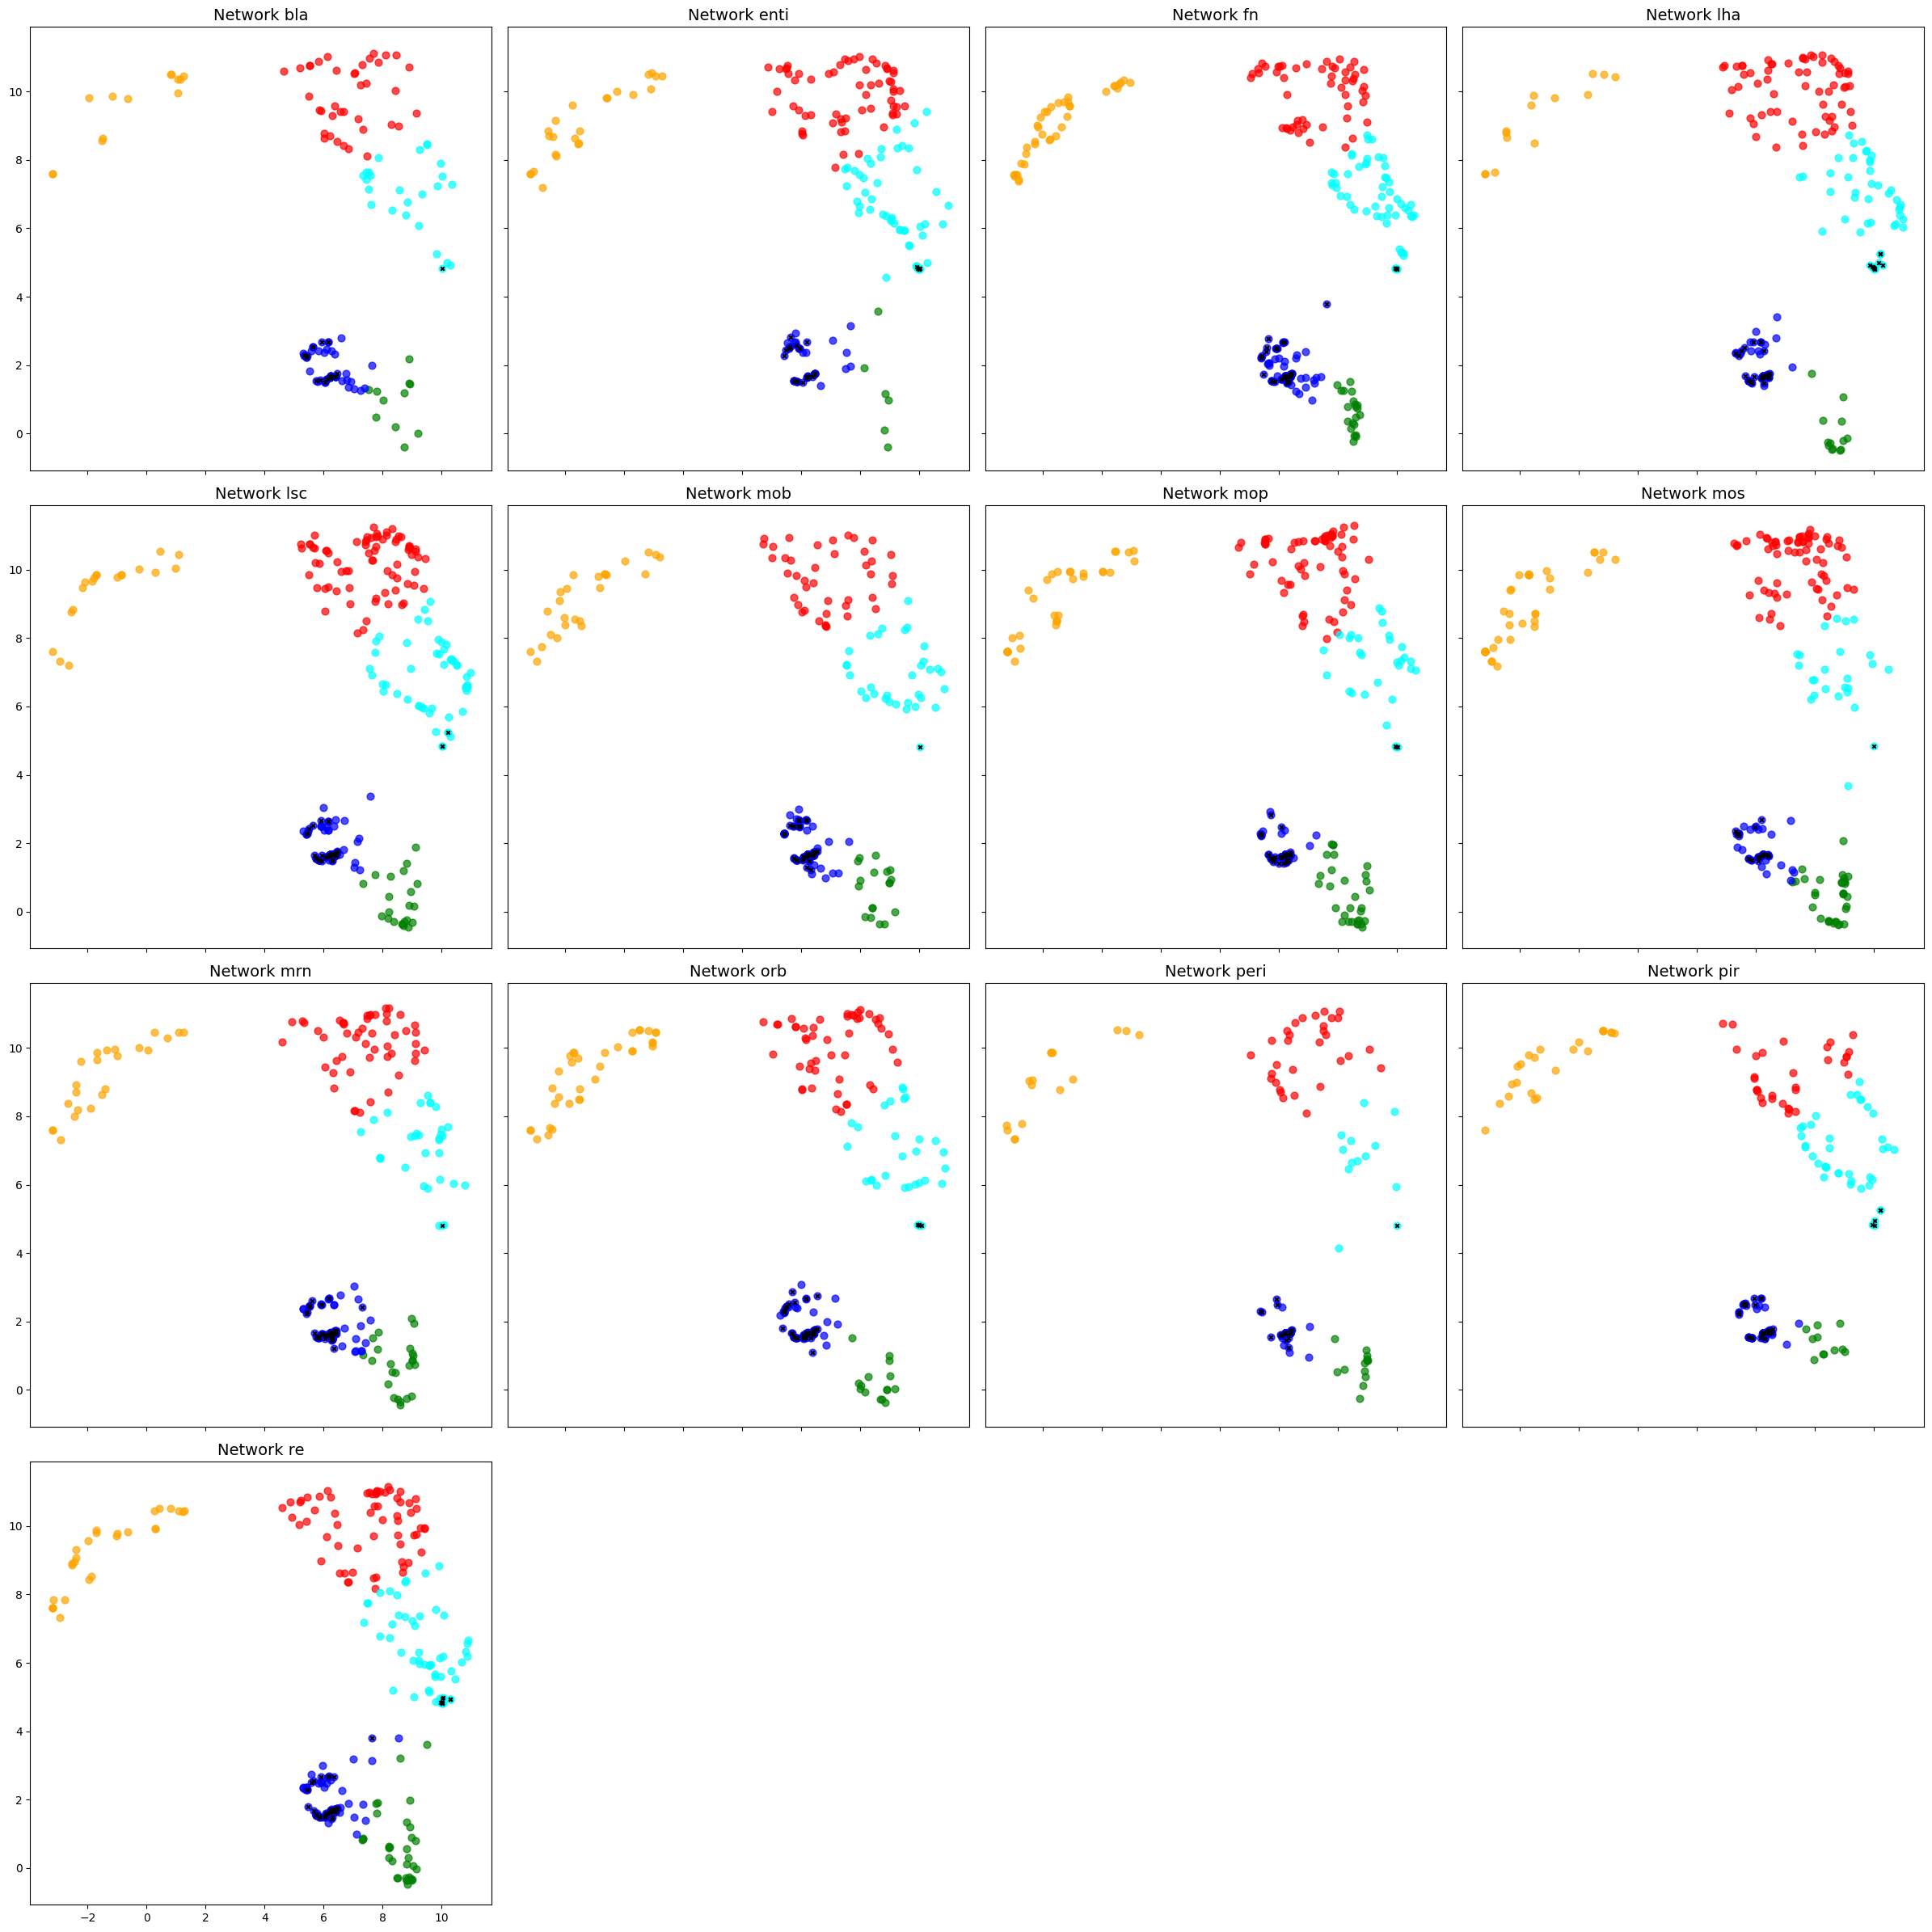

In [ ]:
n_networks = len(embeddings)
n_cols = 4  # number of plots per row
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows), sharex=True, sharey=True)

axes = axes.flatten()

for i, (embed, labels, ax, f_embed) in enumerate(zip(embeddings, network_labels, axes, full_embeddings)):
    for cluster_id in np.unique(labels):
        cluster_points = embed[labels == cluster_id]
        ax.scatter(cluster_points[:,0], cluster_points[:,1],
                   c=colors[cluster_id], s=40, alpha=0.7)
        
        
    # ax.scatter(ref_centroids[:,0], ref_centroids[:,1],
    #            c="gray", marker="X", s=300)
    
    # plot full embedding to see where it lies
    ax.scatter(f_embed[:,0],f_embed[:,1], s=10, c='k',marker='x')

    network_name = Path(file_full[i]).stem.rsplit("_", 1)[-1]
    ax.set_title(f"Network {network_name}", fontsize=14)

# Hide unused axes if networks < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# plt.suptitle("UMAP Embeddings with Consistent KMeans Clusters", fontsize=5)
plt.tight_layout()
# plt.savefig('../../data/results/fig_5_clusters.pdf',format='pdf')


Find the ratio of points in a specific cluster to all the points in the partial network

In [ ]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_cluster_count_ratio(df_par,network):

    # removing NaN if any 
    df_par.dropna(inplace=True)

    embedding_part = _reducer.transform(df_par.values)
    part_network_labels = assign_clusters(embedding_part,ref_centroids)
    # print(len(part_network_labels))

    # Assigning cluster labels to data points

    df_embed = pd.DataFrame(embedding_part)

    df_embed['cluster'] = part_network_labels

    df_count = df_embed.groupby('cluster').count()
    cluster_count = df_count[0]
    # print(cluster_count)
    total_count = df_count.sum()[0]
    # print(total_count)
    ratio=cluster_count/total_count
    ratio=ratio.to_frame()
    ratio.columns=[network]
    return ratio


In [ ]:
df_cluster_count = pd.DataFrame()
for f_part in file_part:
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    # print(f_part)
    data_part = compute_cluster_count_ratio(df_part,f_part.split('_')[-1])
    df_cluster_count=pd.concat([df_cluster_count,data_part],axis=1)
df_cluster_count

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.355140,0.410596,0.284946,0.450000,0.401070,0.310606,0.390244,0.370968,0.344595,0.360294,0.397436,0.290909,0.315
1,0.102804,0.039735,0.112903,0.092857,0.117647,0.136364,0.182927,0.177419,0.162162,0.110294,0.166667,0.100000,0.165
2,0.196262,0.086093,0.129032,0.085714,0.122995,0.121212,0.054878,0.086022,0.128378,0.080882,0.076923,0.072727,0.140
3,0.121495,0.158940,0.204301,0.100000,0.101604,0.189394,0.207317,0.236559,0.155405,0.250000,0.205128,0.218182,0.135
4,0.224299,0.304636,0.268817,0.271429,0.256684,0.242424,0.164634,0.129032,0.209459,0.198529,0.153846,0.318182,0.245


Save above dataframe for data of fig4B plot  
- results/figures/fig4b_data.pkl

In [ ]:
# df_cluster_count.to_pickle('../../data/results/figures/fig4b_data.pkl',compression='bz2')

Text(0, 0.5, 'ratio')

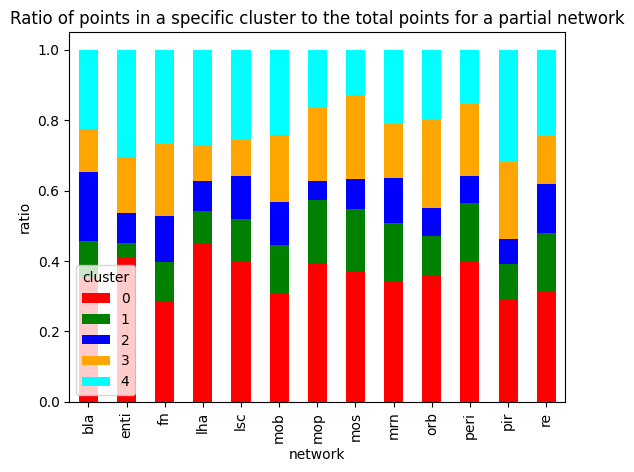

In [11]:

df_cluster_count.T.plot(kind='bar',color=colors, stacked=True)
plt.title('Ratio of points in a specific cluster to the total points for a partial network')
plt.xlabel('network')
plt.ylabel('ratio')

Find ratio of full to partial in a given cluster for a specific network

In [ ]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_full_part_ratio(df_full,df_par,network):
    expected_clusters=[0,1,2,3,4]
    df_par.dropna(inplace=True)
    df_combined = pd.concat([df_full,df_par],axis=0)

    embedding_full=_reducer.transform(df_full.values)
    embedding_part = _reducer.transform(df_par.values)

    whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)

    # assign cluster labels
    whole_cluster_labels = assign_clusters(whole_embedding,ref_centroids)

    df_embed = pd.DataFrame(whole_embedding)
    df_embed['cluster']=whole_cluster_labels

    df_full_cluster = df_embed.iloc[0:df_full.shape[0]]
    df_full_cluster_count = df_full_cluster.groupby('cluster').count()
    fc_count = df_full_cluster_count[0].to_frame()
    fc_count=fc_count.reindex(expected_clusters,fill_value=0)
    # print(fc_count)


    df_part_cluster = df_embed.iloc[df_full.shape[0]:]
    df_part_cluster_count = df_part_cluster.groupby('cluster').count()
    fp_count = df_part_cluster_count[0].to_frame()
    fp_count=fp_count.reindex(expected_clusters,fill_value=0)
    # print(fp_count)

    ratio = (fc_count/fp_count) # ratio of full to partial
    ratio_full_tot =fc_count/(fc_count+fp_count) # ratio of full to total
    ratio.columns=[network]
    ratio_full_tot.columns=[network]
    # return ratio
    return {'ratio':ratio,'r_f_t':ratio_full_tot}
# ratio.columns=[network]



In [ ]:
df_parfull_ratio = pd.DataFrame()
# dataframe for full to total ratio
df_fulltot_ratio=pd.DataFrame()
for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    # df_part.dropna(inplace=True)
    # print(f_part)
    data = compute_full_part_ratio(df_full,df_part,f_part.split('_')[-1])
    data_part=data['ratio']
    df_parfull_ratio=pd.concat([df_parfull_ratio,data_part],axis=1)

    data_full=data['r_f_t']
    df_fulltot_ratio=pd.concat([df_fulltot_ratio,data_full],axis=1)
df_parfull_ratio

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.380952,3.923077,4.041667,3.666667,4.086957,5.81250,7.666667,2.562500,4.105263,8.090909,7.666667,7.750000,2.964286
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.041667,0.130435,0.120000,0.289474,0.062500,0.03125,0.111111,0.041667,0.032258,0.185185,0.083333,0.142857,0.183673


plot full to partial ratio

Text(0, 0.5, 'ratio')

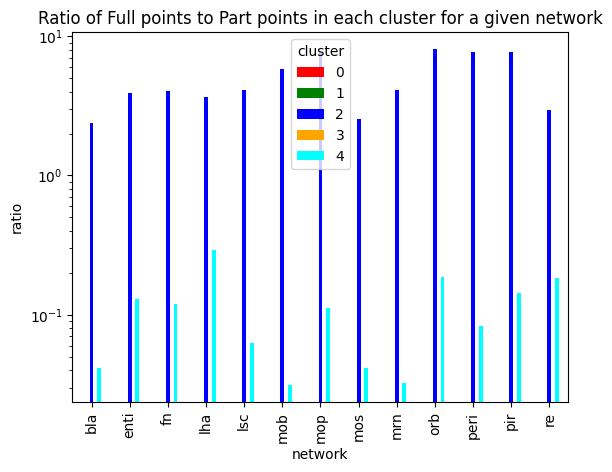

In [26]:

df_parfull_ratio.T.plot(kind='bar',color=colors,logy=True)
plt.title('Ratio of Full points to Part points in each cluster for a given network')
plt.xlabel('network')
plt.ylabel('ratio')

plot full to total ratio

In [32]:
df_fulltot_ratio['fn'].T

cluster
0    0.000000
1    0.000000
2    0.801653
3    0.000000
4    0.107143
Name: fn, dtype: float64

Text(0, 0.5, 'ratio')

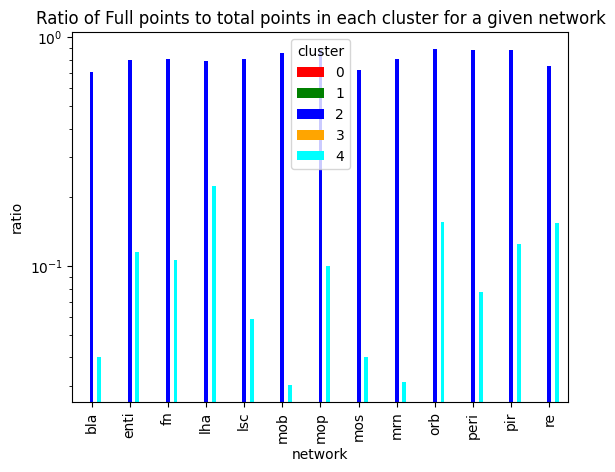

In [27]:
df_fulltot_ratio.T.plot(kind='bar',color=colors,logy=True)
plt.title('Ratio of Full points to total points in each cluster for a given network')
plt.xlabel('network')
plt.ylabel('ratio')

Save full to total

In [29]:
df_fulltot_ratio

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,0.704225,0.796875,0.801653,0.785714,0.803419,0.853211,0.884615,0.719298,0.804124,0.89000,0.884615,0.885714,0.747748
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,0.040000,0.115385,0.107143,0.224490,0.058824,0.030303,0.100000,0.040000,0.031250,0.15625,0.076923,0.125000,0.155172


In [28]:
df_fulltot_ratio.to_pickle('../../data/results/figures/fig5a_data.pkl',compression='bz2')

Find cluster community wise mean

In [ ]:

def compute_cluster_comm_partcptn(df_f,df_p,n):
    df_p.dropna(inplace=True)
    df_combined = pd.concat([df_f,df_p],axis=0)
    # print(df_f.shape)
    # print(df_p.shape)
    # print(df_combined.shape)

    df_combined['cluster']=network_labels[n]
    # print(df_combined.shape)

    # removing df_full rows from combined
    df_work=df_combined.iloc[df_f.shape[0]:,:]
    # print(df_work.shape)
    # df_work.head()

    # take average clusterwise for each column

    communities = list(df_work.columns[:-1])
    # print(communities)
    cluster_data = pd.DataFrame()
    for comm in communities:
        # print(comm)
        df_cluster = df_work.groupby('cluster')[comm].mean()
        cluster_data=pd.concat([cluster_data,df_cluster],axis=1)

    # Plot bar chart using cluster data
    # take avg of each cluster excluding hind
    # print(cluster_data)
    avg_0 = cluster_data.loc[0][:-1].mean()
    avg_1 = cluster_data.loc[1][:-1].mean()
    avg_2 = cluster_data.loc[2][:-1].mean()

    # comment when using 3 clusters only
    avg_3 = cluster_data.loc[3][:-1].mean()
    avg_4 = cluster_data.loc[4][:-1].mean()

    # Normalizing each cluster 
    c_0 = cluster_data.loc[0]/avg_0
    c_1 = cluster_data.loc[1]/avg_1
    c_2 = cluster_data.loc[2]/avg_2

    # comment when using 3 clusters
    c_3 = cluster_data.loc[3]/avg_3
    c_4 = cluster_data.loc[4]/avg_4

    # print(cluster_data.head(3))
    # Updating cluster data to plot
    cluster_data.loc[0]=c_0
    cluster_data.loc[1]=c_1
    cluster_data.loc[2]=c_2

    # comment when using 3 clusters
    cluster_data.loc[3]=c_3
    cluster_data.loc[4]=c_4
    
    # cluster_data.head(3)
    cluster_plot = cluster_data.copy()

    # cluster_plot.head()
    # print(cluster_plot)
    return cluster_plot
    



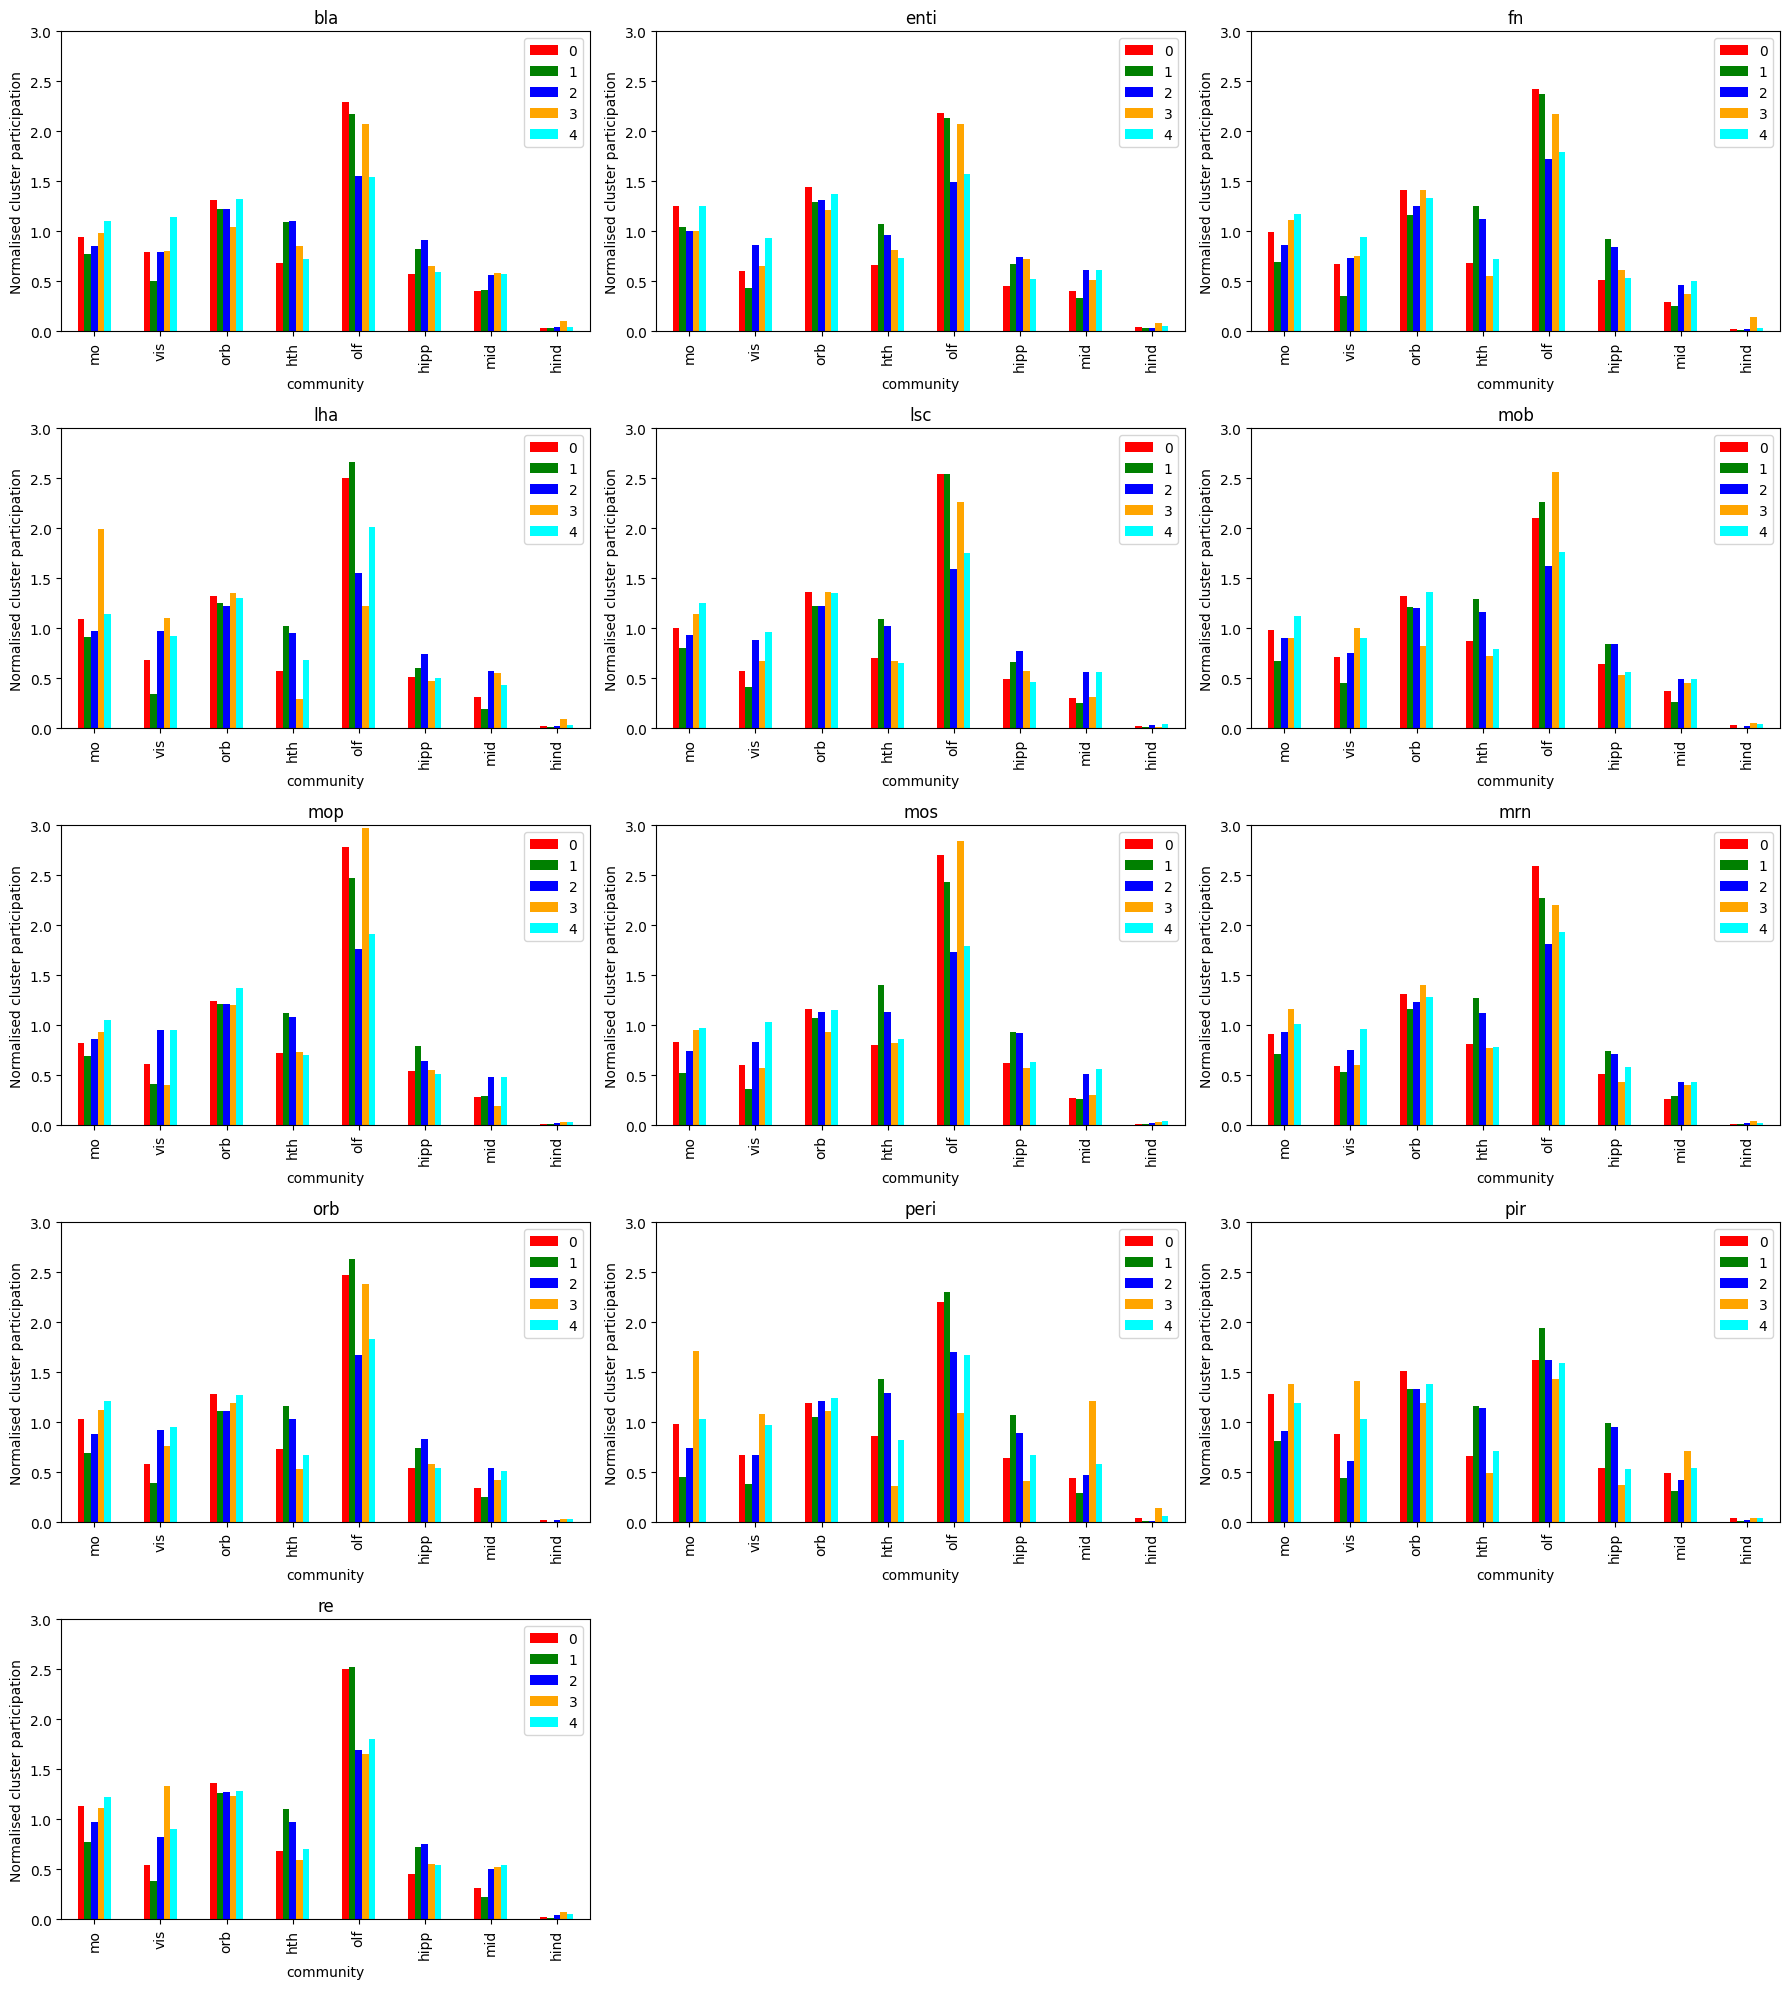

In [ ]:
import math

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()   # flatten to 1D array for easy looping

cluster_colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}
data_dict ={}

for n, (f_full, f_part, ax) in enumerate(zip(file_full, file_part, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    
    clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns]
    )
    
    ax.set_xlabel('community')
    ax.set_ylabel('Normalised cluster participation')
    ax.set_ylim(0,3)
    ax.set_title(file_full[n].split('_')[-1])

    # storing cluster data as flattened 8x5 for each network  
    cl_data=clusterData.values.flatten()
    nw=file_full[n].split('_')[-1]
    data_dict[nw]=cl_data

# Hide any unused subplots if n_files doesn’t fill the grid
for ax in axes[n_files:]:
    ax.set_visible(False)

plt.tight_layout()

# plt.savefig('../../data/results/fig_5_cluster_bar.pdf',format='pdf')


Make data for fig 4 D

In [ ]:
df_out = pd.DataFrame.from_dict(data_dict, orient='index')
df_out.to_pickle('../../data/results/figures/fig4d_data.pkl',compression='bz2')
# convert above dataframe to ndarray and do umap/pca

In [42]:
labels=list(df_out.index)
labels

['bla',
 'enti',
 'fn',
 'lha',
 'lsc',
 'mob',
 'mop',
 'mos',
 'mrn',
 'orb',
 'peri',
 'pir',
 're']

In [57]:
umap_cluster = umap.UMAP(n_neighbors=5,min_dist=0.05,n_components=2,random_state=42)


_reducer = umap_cluster.fit(df_out.values)

# transforming using reducer
clus_data_tf = _reducer.transform(df_out.values)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


do kmeans

In [70]:
kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clus_data_tf)

(7.0, 10.5)

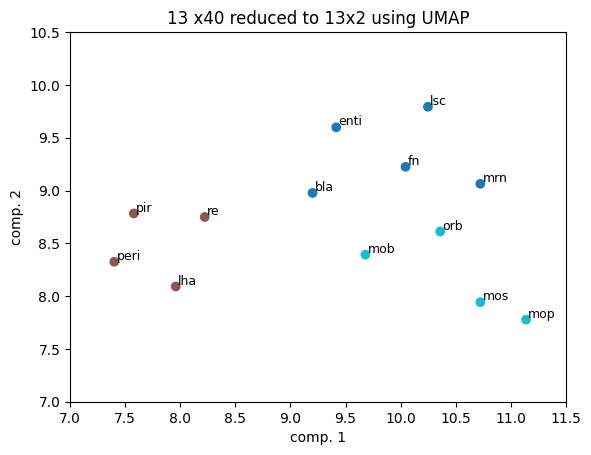

In [ ]:

plt.scatter(clus_data_tf[:,0],clus_data_tf[:,1],c=clus_pl,cmap='tab10')
for i, label in enumerate(labels):
    plt.text(clus_data_tf[i,0]+0.02, clus_data_tf[i,1]+0.02, label, fontsize=9)

plt.ylabel('comp. 2')
plt.xlabel('comp. 1')
plt.title('13 x40 reduced to 13x2 using UMAP')
plt.xlim(7,11.5)
plt.ylim(7,10.5)





Using PCA

Text(0.5, 1.0, '13 x40 reduced to 13x2 using PCA')

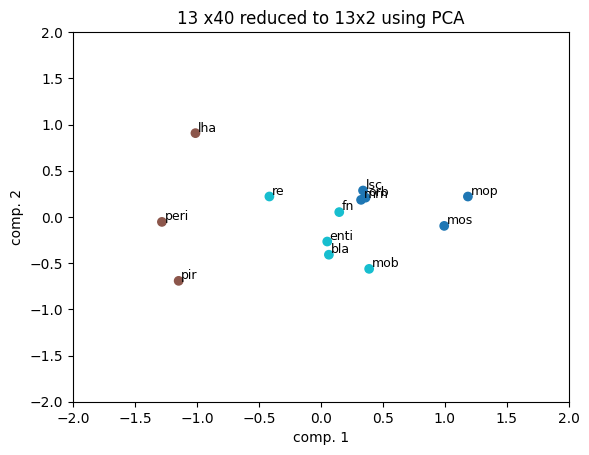

In [ ]:
from sklearn.decomposition import PCA
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(df_out.values)
clu_tf_pca=reducer_pca.transform(df_out.values)

kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)

plt.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10')
for i, label in enumerate(labels):
    plt.text(clu_tf_pca[i,0]+0.02, clu_tf_pca[i,1]+0.02, label, fontsize=9)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.ylabel('comp. 2')
plt.xlabel('comp. 1')
plt.title('13 x40 reduced to 13x2 using PCA')

In [ ]:
cluster_part=[]
network_names=[]

# to store avg community participation for a cluster


for n,(f_full,f_part) in enumerate(zip(file_full,file_part)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    network_names.append(f_full.split('_')[-1])
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    cluster_part.append(clusterData.values)

column_header = clusterData.columns
print(network_names)


    


    


['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']


In [ ]:
# from each network cluster, extract communities

c_0_parcptn=pd.DataFrame()
c_1_parcptn=pd.DataFrame()
c_2_parcptn=pd.DataFrame()
c_3_parcptn=pd.DataFrame()
c_4_parcptn=pd.DataFrame()

for clus_data,nw in zip(cluster_part,network_names):
    df_clus = pd.DataFrame(clus_data)
    df_clus.columns = column_header

    
    # for cluster 0
    row_c0=df_clus.loc[0].to_frame().T
    row_c0.index=[nw]
    c_0_parcptn=pd.concat([c_0_parcptn,row_c0],axis=0)
    

    #for cluster 1
    row_c1=df_clus.loc[1].to_frame().T
    row_c1.index=[nw]
    c_1_parcptn=pd.concat([c_1_parcptn,row_c1],axis=0)

    #for cluster 2
    row_c2=df_clus.loc[2].to_frame().T
    row_c2.index=[nw]
    c_2_parcptn=pd.concat([c_2_parcptn,row_c2],axis=0)
    
    #for cluster 3
    row_c3=df_clus.loc[3].to_frame().T
    row_c3.index=[nw]
    c_3_parcptn=pd.concat([c_3_parcptn,row_c3],axis=0)

    #for cluster 4
    row_c4=df_clus.loc[4].to_frame().T
    row_c4.index=[nw]
    c_4_parcptn=pd.concat([c_4_parcptn,row_c4],axis=0)



        


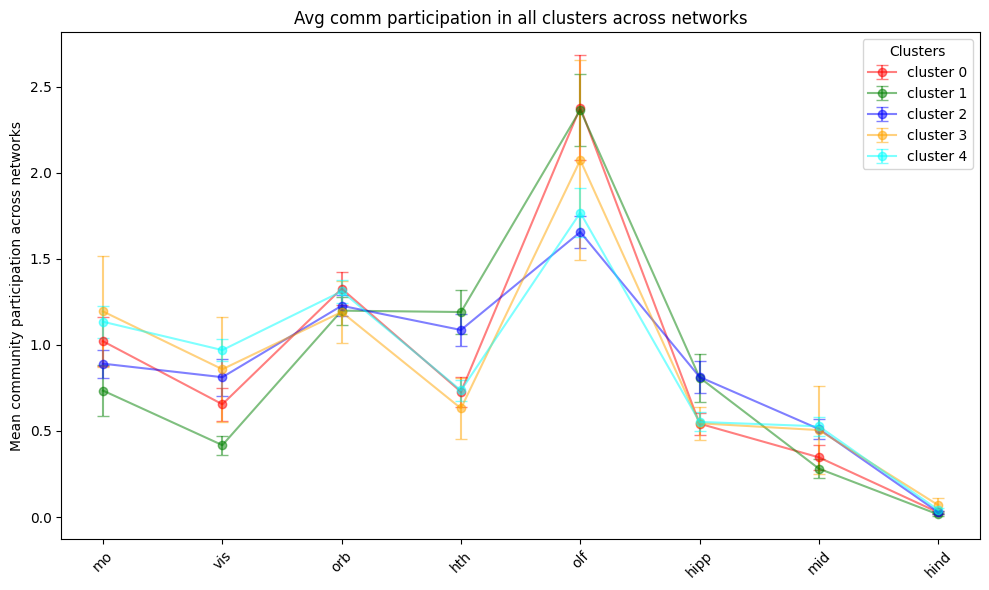

In [ ]:


# Your cluster DataFrames
dfs = [c_0_parcptn, c_1_parcptn, c_2_parcptn, c_3_parcptn, c_4_parcptn]

# Define cluster colors
cluster_colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}

plt.figure(figsize=(10,6))

for i, df in enumerate(dfs, start=0):
    # Vertical mean (row-wise mean for each column)
    mean_vals = df.mean(axis=0)
    # Vertical standard deviation
    std_vals = df.std(axis=0)

    # Plot with error bars, using your chosen cluster color
    plt.errorbar(df.columns, mean_vals, yerr=std_vals,
                 label=f'cluster {i}',
                 color=cluster_colors[i],
                 capsize=4, marker='o', linestyle='-', alpha=0.5)

plt.xticks(rotation=45)
plt.ylabel("Mean community participation across networks")
plt.title("Avg comm participation in all clusters across networks")
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()




In [58]:
dfs[0]

,mo,vis,orb,hth,olf,hipp,mid,hind
bla,0.946027,0.790222,1.315748,0.679832,2.293980,0.569710,0.404481,0.030669
enti,1.257179,0.599361,1.439222,0.661568,2.186557,0.454208,0.401906,0.041159
fn,0.993989,0.678284,1.416082,0.684669,2.423625,0.511457,0.291894,0.019842
lha,1.093092,0.685441,1.320350,0.570927,2.502703,0.512058,0.315430,0.024017
lsc,1.002861,0.575773,1.367462,0.706469,2.547664,0.492780,0.306991,0.024914
mob,0.979523,0.712642,1.321307,0.873694,2.101735,0.639470,0.371628,0.030643
mop,0.821761,0.610196,1.240884,0.723040,2.778786,0.538973,0.286359,0.015224
mos,0.835596,0.598804,1.162153,0.805413,2.700909,0.627684,0.269439,0.014000
mrn,0.911909,0.596253,1.316891,0.808545,2.593021,0.513201,0.260179,0.015049
orb,1.037653,0.582054,1.283048,0.737487,2.472195,0.546333,0.341231,0.027185


Save clusterwise participation dtaframes list to use for figure 4c plot  
results/figures/fig4c_data.pkl  

In [57]:
reader.data_dump_pkl('results/figures/fig4c_data.pkl',dfs)

## Compute clusterwise params

Use this file which contains iteration number and the transition in it for every network  
Saved in 'results/comm_umap_results/part_full_comm_ind.pkl'

- Network based iteration number and index result
- Tuple index is row number of your 'trans x 8' file
- Tuple 1st element is iteration number
- Tuple 2nd element is the index number of the transition in that iteration

In [40]:
nw_itr= reader.data_read_pkl('results/comm_umap_results/part_full_comm_ind.pkl')

Peek inside above file

In [32]:
# nw_itr.keys()    
# ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
# nw_itr['bla'].keys()
# ['part_ind', 'full_ind']
# nw_itr['bla']['full_ind']    
# list of tuples

Define function which labels each transition by it's cluster  
INPUT: trans x 8, nw_itr, _reducer, ref_centroids  
OUTPUT:   Cluster indices i.e row index of trans x 8  

In [33]:
df_par= reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')

In [ ]:
def compute_cluster_indices(df,nw_itr,_reducer, ref_centroids, nw, trans_type):
    """Compute index of rows of df specific to a cluster

    Args:
        df (dataframe): number of transitions x 8 (Community wise participation for each transition)
        nw_itr (dict): Contains iteration number and the transition in it for all networks (Partial and Full transitions both)
        _reducer (UMAP): UMAP reduced on partial FN data
        ref_centroids (nd array): Centroids as per FN data after clustering
        nw (string): ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
        trans_type (string): ['part_ind', 'full_ind']

    Returns:
        dictionary: keys: 'cluster_ind',''new_ind'
    """
    i_part=nw_itr[nw][trans_type].copy()
    # find NaN rows index of entries x 8 vector space
    nan_indices = df.index[df.isnull().any(axis=1)].tolist()

    # removing the NaN row
    if not nan_indices:
        pass
        new_ind=i_part
    else:
        # dropping NaN value
        df.dropna(inplace = True)
        # removing nan entries from nw_itr of given network
        
        for i in nan_indices:
            new_ind = [val for i, val in enumerate(i_part) if i not in nan_indices]

    

    embedding = _reducer.transform(df.values)
    network_labels = assign_clusters(embedding,ref_centroids)

    # assigning cluster labels to our 186 x2 vector space  
    df_embed = pd.DataFrame(embedding)
    df_embed['cluster'] = network_labels

    cluster_indices = {c: df_embed.index[df_embed['cluster'] == c].tolist() for c in df_embed['cluster'].unique()}
    
    return {'cluster_ind':cluster_indices,'nw_new':new_ind}



   

In [35]:
l=compute_cluster_indices(df_par,nw_itr,_reducer,ref_centroids,'fn','full_ind')


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [36]:
l['cluster_ind'].keys()

dict_keys([2, 4])

Define function which computes parameters clusterwise

In [ ]:
def compute_cluster_params(cluster_indices,new_ind,df_go,df_nc):
    """Computes cluster wise params and stores them in dict

    Args:
        cluster_indices (_type_): _description_
        new_ind (_type_): _description_
        df_go (_type_): _description_
        df_nc (_type_): _description_

    Returns:
        _type_: _description_
    """
    clus_params={}
    for i in list(l['cluster_ind'].keys()):

        # saving clusterwise params data
        fpt=[]
        st=[]
        cov=[]
        tt=[]
        for ind in cluster_indices[i]:
            

            # getting actual iteration number
            itrn = new_ind[ind]
            
            # compute params
            pts=algo_umap.compute_parameters(df_go[itrn[0]])
            fpt_list=algo.compute_fpt(pts['start_points'].copy(),pts['stop_points'].copy())[itrn[1]]
            fpt.append(fpt_list)
            st_list = algo.compute_sync(pts['start_points'].copy(),pts['stop_points'].copy())
            if itrn[1]  < len(st_list):
                # consider case when transition doesn't falls back
                st.append(st_list[itrn[1]])
            
            cov_list = comm_ops.compute_individual_coverage_nc(df_nc.loc[itrn[0]], df_go[itrn[0]])[itrn[1]]
            cov.append(cov_list)
            tt_list = algo_umap.compute_transition_time(df_go[itrn[0]],pts['start_points'].copy())[itrn[1]]
            tt.append(tt_list)

        clus_params[i]={'fpt':fpt,'st':st, 'cov':cov, 'tt':tt}
    return clus_params
        

In [ ]:
df_go = reader.data_read_bz2('raw/workstation/tes_fn_go.bz2')
df_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')

In [ ]:
f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

#### Compute for full params clusterwise

In [4]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))



In [ ]:
data_folder = Path('../../data/raw/workstation')
file_go =glob.glob(str(data_folder/'tes_*_go.bz2'))
file_nc=glob.glob(str(data_folder/'tes_*_nc.bz2'))

In [ ]:
f_name = file_full[0]

In [ ]:
f_name.split('_')[-1]

'bla'

In [ ]:
for f_full,f_part,f_go,f_nc in zip(file_full,file_part,file_go,file_nc):
    nw=f_full.split('_')[-1]
    
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_go=pd.read_pickle(f_go,compression='bz2')
    df_nc=pd.read_pickle(f_nc,compression='bz2')
    # computing full
    l=compute_cluster_indices(df_full,nw_itr,_reducer,ref_centroids,nw,'full_ind')
    f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # save
    # reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/full_{nw}',f_full)


    #computing part
    l=compute_cluster_indices(df_part,nw_itr,_reducer,ref_centroids,nw,'part_ind')
    f_part=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/part_{nw}',f_part)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


#### Read cluster wise params and plot

In [ ]:
def plot_params(data,label):
    """Plots violinplots for every parameter clusterwise

    Args:
        data (dictionary): cluster wise param data
        label (string): network name
    """

    fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(15, 15),sharey='row')
    key_list=['fpt', 'st', 'cov', 'tt']
    for i in list(data.keys()):              # outer loop cluster
        for j in range(4):
                    # inner loop (columns)
            ax = axes[j,i]         # select subplot
            plt_data = data[i][key_list[j]]  # get the data from dictionary

            # Example: violin plot
            if plt_data:
                ax.violinplot(plt_data, showmedians=True)
                ax.set_title(f"cluster {i}, {key_list[j]}")
            else:
                ax.text(0.5, 0.5, "Empty", ha='center')

    plt.suptitle(f'Cluster wise {label}')
    plt.tight_layout()
    # plt.savefig(f'../../data/results/comm_umap_results/comm_wise_params/cw_{label}.pdf', format='pdf')
    
    
    
    plt.show()


    

Folder where clusterwise params data is stored

In [39]:
data_folder = Path('../../data/results/comm_umap_results/comm_wise_params')
file_full = glob.glob(str(data_folder/'full_*'))
file_part = glob.glob(str(data_folder/'part_*'))



To count number of transitions for each cluster


In [40]:
data=reader.data_read_pkl('results/comm_umap_results/comm_wise_params/part_fn')

In [43]:
len(data[2]['tt'])

24

In [49]:
# we count by counting entries in transition time  

def count_cw(data,cl):
    cl_count={}
    # cl=[0,1,2,3,4]
    for i in cl:
        cl_count[i]=len(data[i]['tt'])

    return cl_count
    

In [51]:
clc_nw={}
for fp in file_part:
    with open(fp, "rb") as f:
        pkl_part = pickle.load(f)
    clc_nw[fp.split('_')[-1]]=count_cw(pkl_part,[0,1,2,3,4])

In [52]:
clc_nw

{'bla': {0: 38, 1: 11, 2: 21, 3: 13, 4: 24},
 'enti': {0: 62, 1: 6, 2: 13, 3: 24, 4: 46},
 'fn': {0: 53, 1: 21, 2: 24, 3: 38, 4: 50},
 'lha': {0: 63, 1: 13, 2: 12, 3: 14, 4: 38},
 'lsc': {0: 75, 1: 22, 2: 23, 3: 19, 4: 48},
 'mob': {0: 41, 1: 18, 2: 16, 3: 25, 4: 32},
 'mop': {0: 64, 1: 30, 2: 9, 3: 34, 4: 27},
 'mos': {0: 69, 1: 33, 2: 16, 3: 44, 4: 24},
 'mrn': {0: 51, 1: 24, 2: 19, 3: 23, 4: 31},
 'orb': {0: 49, 1: 15, 2: 11, 3: 34, 4: 27},
 'peri': {0: 31, 1: 13, 2: 6, 3: 16, 4: 12},
 'pir': {0: 32, 1: 11, 2: 8, 3: 24, 4: 35},
 're': {0: 63, 1: 33, 2: 28, 3: 27, 4: 49}}

Making data for figure 5b,c

Define function to compute mean params of a given network data clusterwise

In [ ]:
def compute_nw_clust_means(data):
    """Takes in clusterwise param data for a given network and then computes means clusterwise
    Input files at '../../data/results/comm_umap_results/comm_wise_params'

    Args:
        data (dictionary): contains clusterwise parameters for a given network
    Returns:
        dictionary: clusterwise parameter means
    """
# define dictionary to store clusterwise mean param for each network
    nw_data={}
    # dictionary to store each parameter for a cluster
    clus_param={}
    #iterating over clusters
    for k in data.keys():
        #iterating over params  
        for p in data[k].keys():
            # store mean of params in dictionary
            # remove zero values if any mostly in coverage
            data_=[x for x in data[k][p] if x>0]
            clus_param[p]=np.mean(data_)
        nw_data[k]=clus_param
        clus_param={}
    return nw_data
    


In [ ]:
# compute and store data for figure 5b (network wise partial transitions parameter means)
data_5b={}
for fp in file_part:
    with open(fp, "rb") as f:
        pkl_part = pickle.load(f)
    data_5b[fp.split('_')[-1]]=compute_nw_clust_means(pkl_part)

In [ ]:
# compute and store data for figure 5c (network wise full transitions parameter means)
data_5c={}
for ff in file_full:
    with open(ff, "rb") as f:
        pkl_full = pickle.load(f)
    data_5c[ff.split('_')[-1]]=compute_nw_clust_means(pkl_full)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [38]:
data_5b['fn'][4]

{'fpt': 448.9,
 'st': 127.17391304347827,
 'cov': 0.233860678480881,
 'tt': 55.89200000000001}

define function to get clusterwise params from data_5b,c

In [ ]:
def comp_clus_data(data,n):
    """Takes in data and gives clusterwise params

    Args:
        data (dictionary): data_5b,data_5c
        n (integer): cluster number 0,1,2,3,4
    Returns:
        dictionary: clusterwise mean params
    """
    fpt=[]
    st=[]
    tt=[]
    cov=[]
    for nw in data.keys():
       fpt.append(data[nw][n]['fpt'])
       st.append(data[nw][n]['st'])
       tt.append(data[nw][n]['tt'])
       cov.append(data[nw][n]['cov'])
    
    return {'fpt':fpt,'st':st,'tt':tt,'cov':cov}

In [ ]:
cluster_dt5b={}
for i in data_5b['fn'].keys():
    cluster_dt5b[i]=comp_clus_data(data_5b,i)


In [ ]:
cluster_dt5c={}
for i in data_5c['fn'].keys():
    cluster_dt5c[i]=comp_clus_data(data_5c,i)

Store data for figure 5b 5c

In [26]:
reader.data_dump_pkl('results/figures/fig5b_data.pkl',cluster_dt5b)
reader.data_dump_pkl('results/figures/fig5c_data.pkl',cluster_dt5c)

In [ ]:
d=reader.data_read_pkl('results/comm_umap_results/comm_wise_params/full_fn')

In [ ]:
fpt_med=[]
st_med =[]
cov_med =[]
tt_med=[]
def collect_data(d):
    key_list=['fpt', 'st', 'cov', 'tt']
    
    for clus in list(d.keys()):
        for j in range(4):
            data = d[clus][key_list[j]]
            if j==0:
                fpt_med.append(np.median(data))
            elif j==1:
                st_med.append(np.median(data))
            elif j==2:
                cov_med.append(np.median(data))
            else:
                tt_med.append(np.median(data))


In [ ]:
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    collect_data(pkl_full)

    # with open(f_part, "rb") as f:
    #     pkl_part = pickle.load(f)

    # plot_params(pkl_part,f"part_{f_part.split('_')[-1]}")

    # print(f"full_{f_full.split('_')[-1]}")

full_bla
full_enti
full_fn
full_lha
full_lsc
full_mob
full_mop
full_mos
full_mrn
full_orb
full_peri
full_pir
full_re


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
collect_data(d)

In [ ]:
tt_med

[78.47500000000001,
 67.05,
 78.95,
 72.65,
 76.15,
 67.525,
 76.22500000000001,
 75.55,
 78.7,
 65.3,
 80.05000000000001,
 83.05000000000001,
 73.55,
 65.4,
 77.9,
 74.10000000000001,
 74.85,
 61.85,
 82.0,
 65.3,
 76.05,
 86.35000000000001,
 78.7,
 79.55000000000001,
 75.9,
 75.25]

full_bla


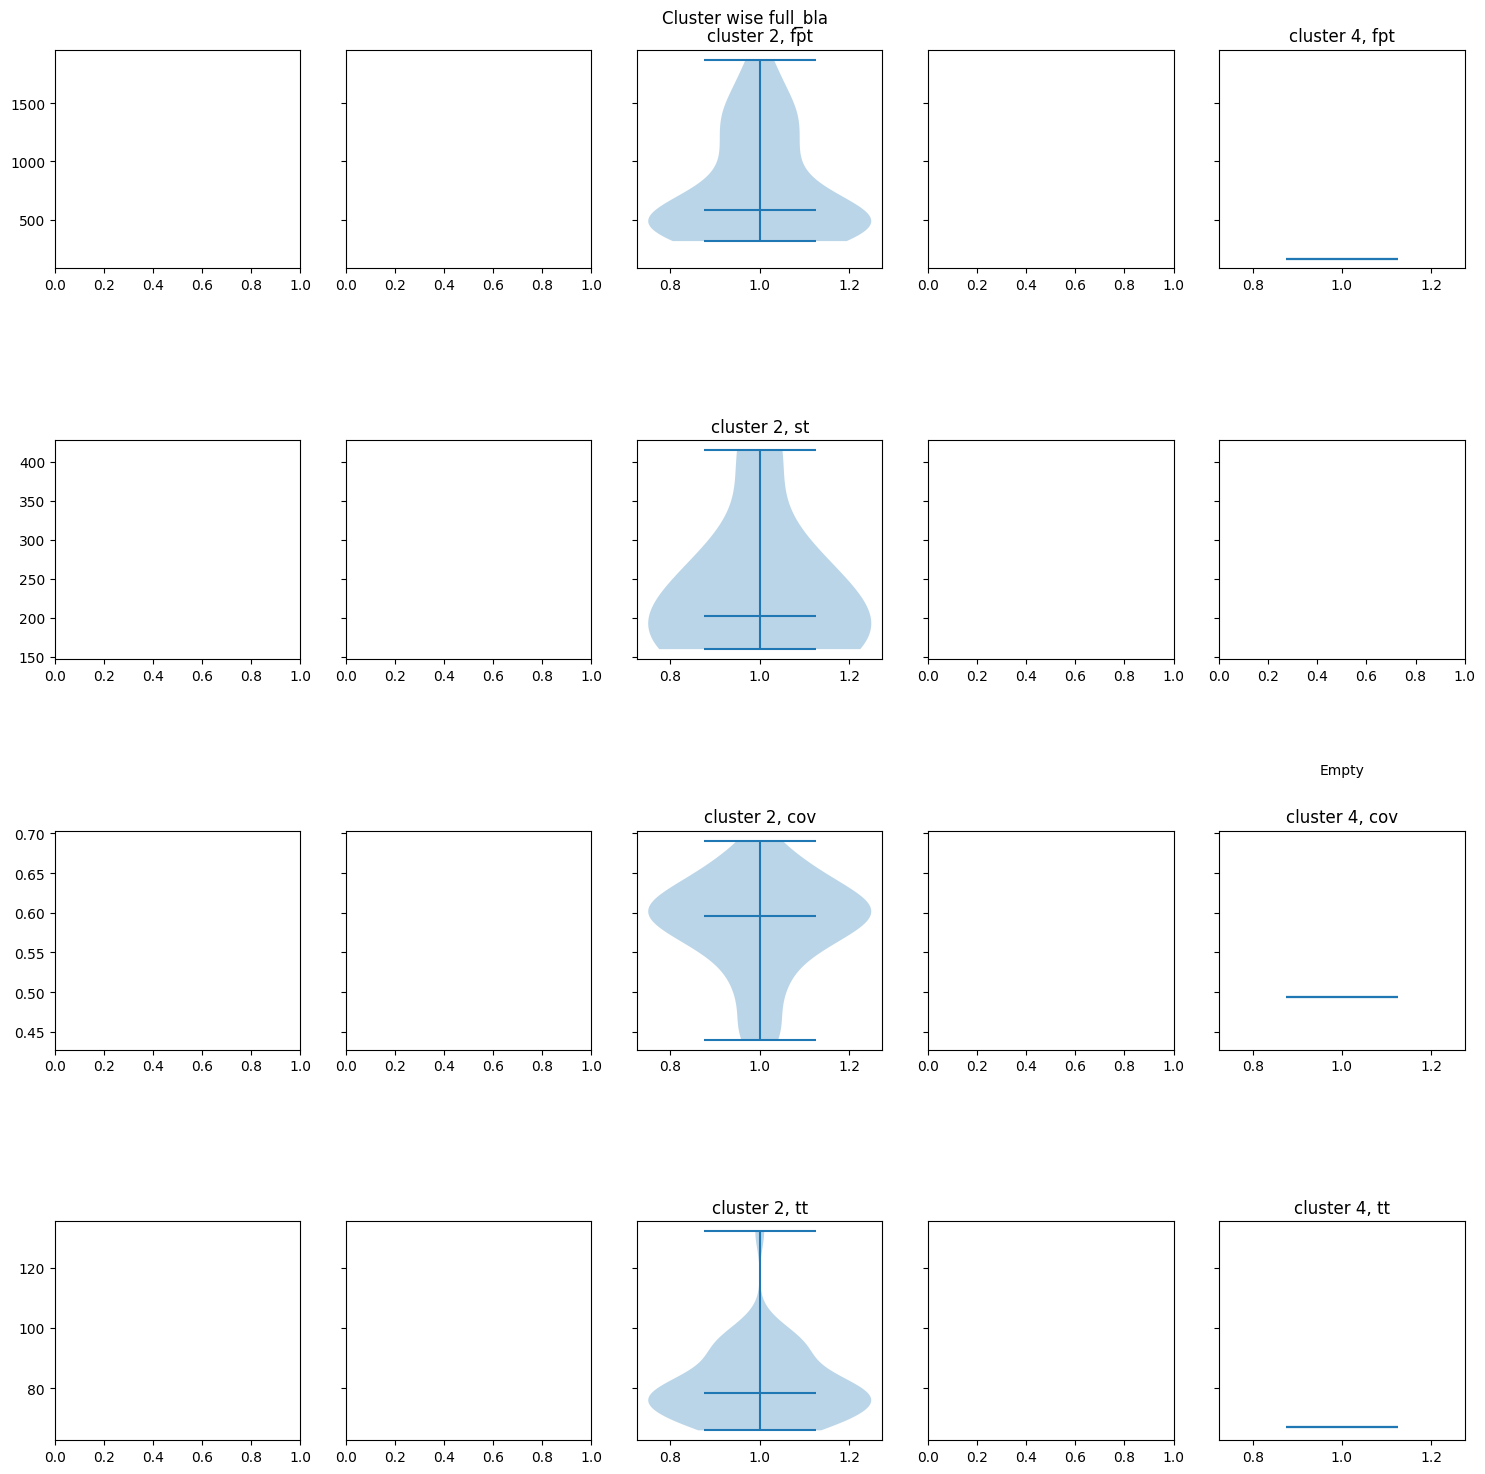

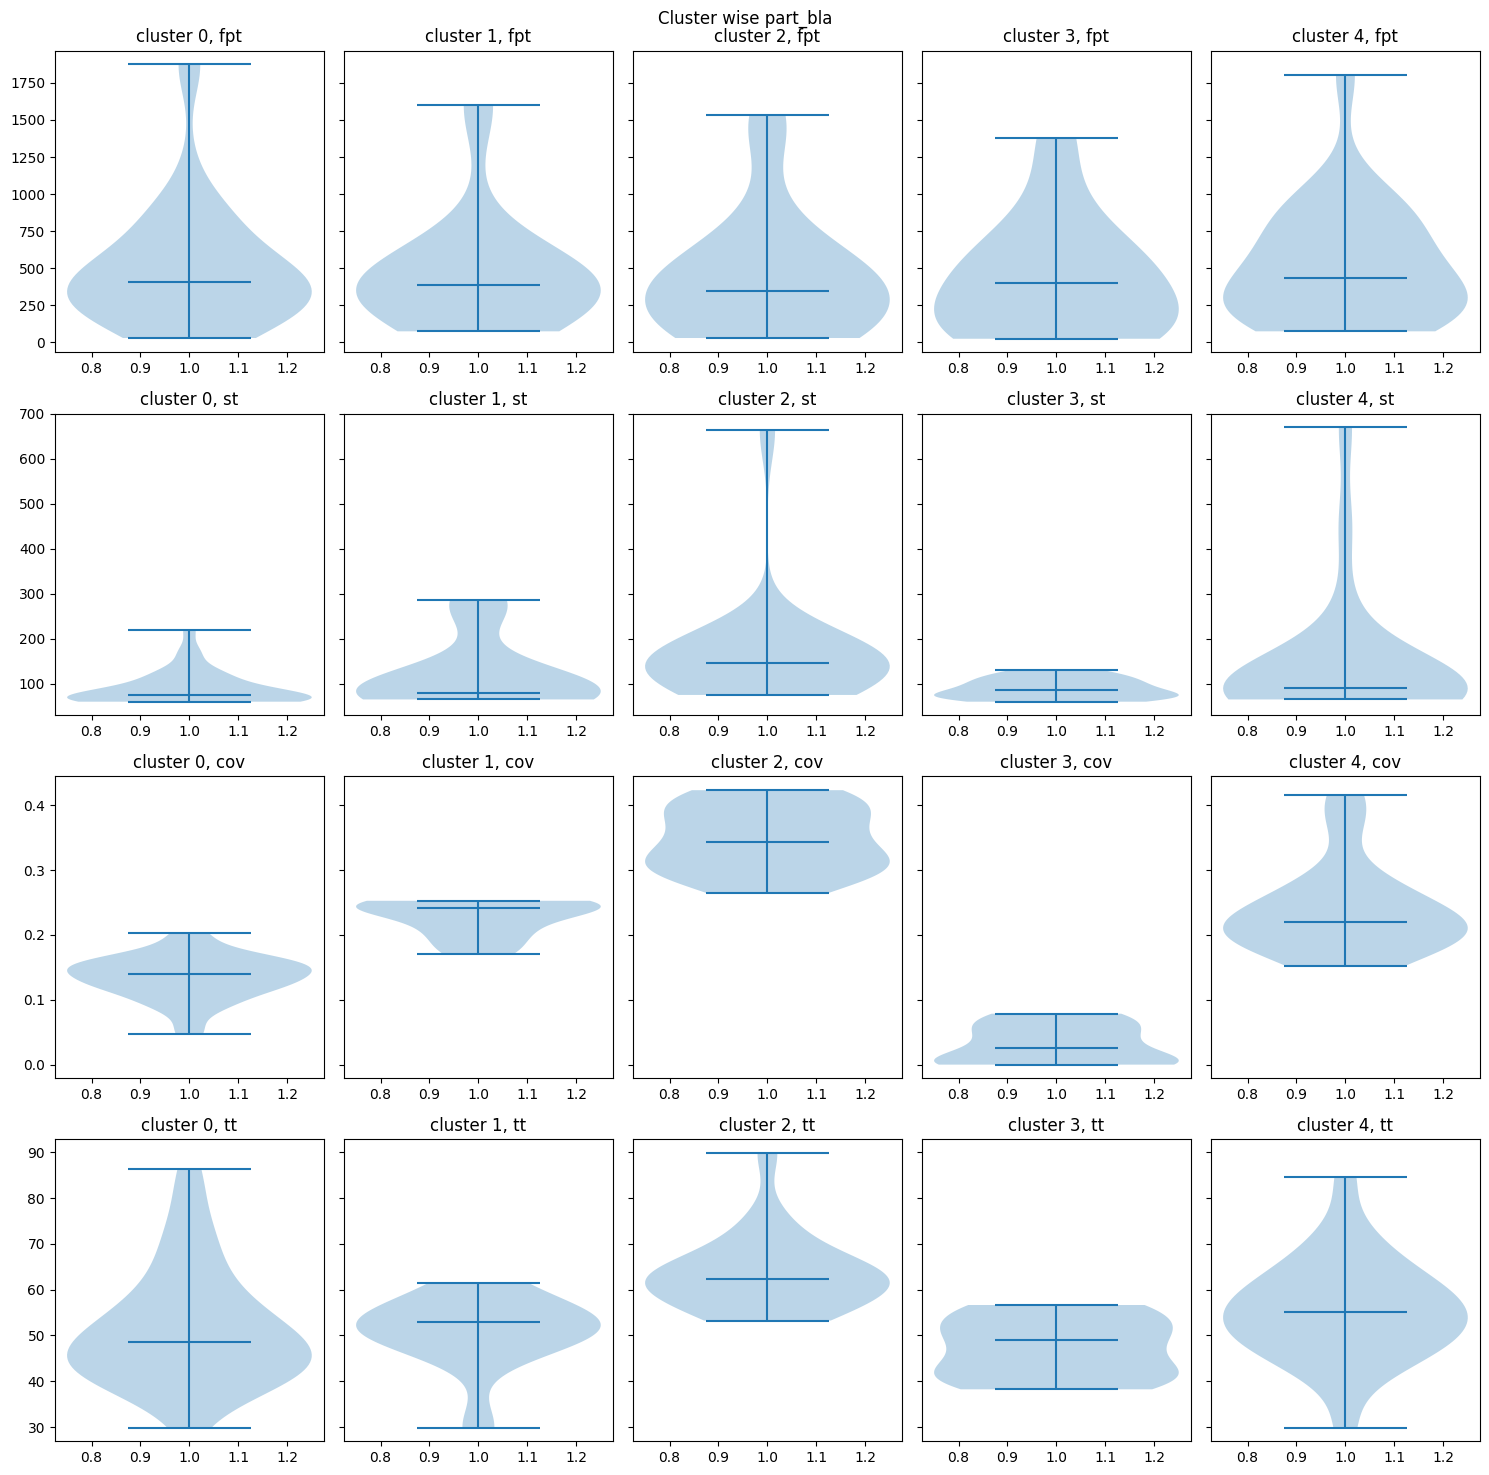

full_bla
full_enti


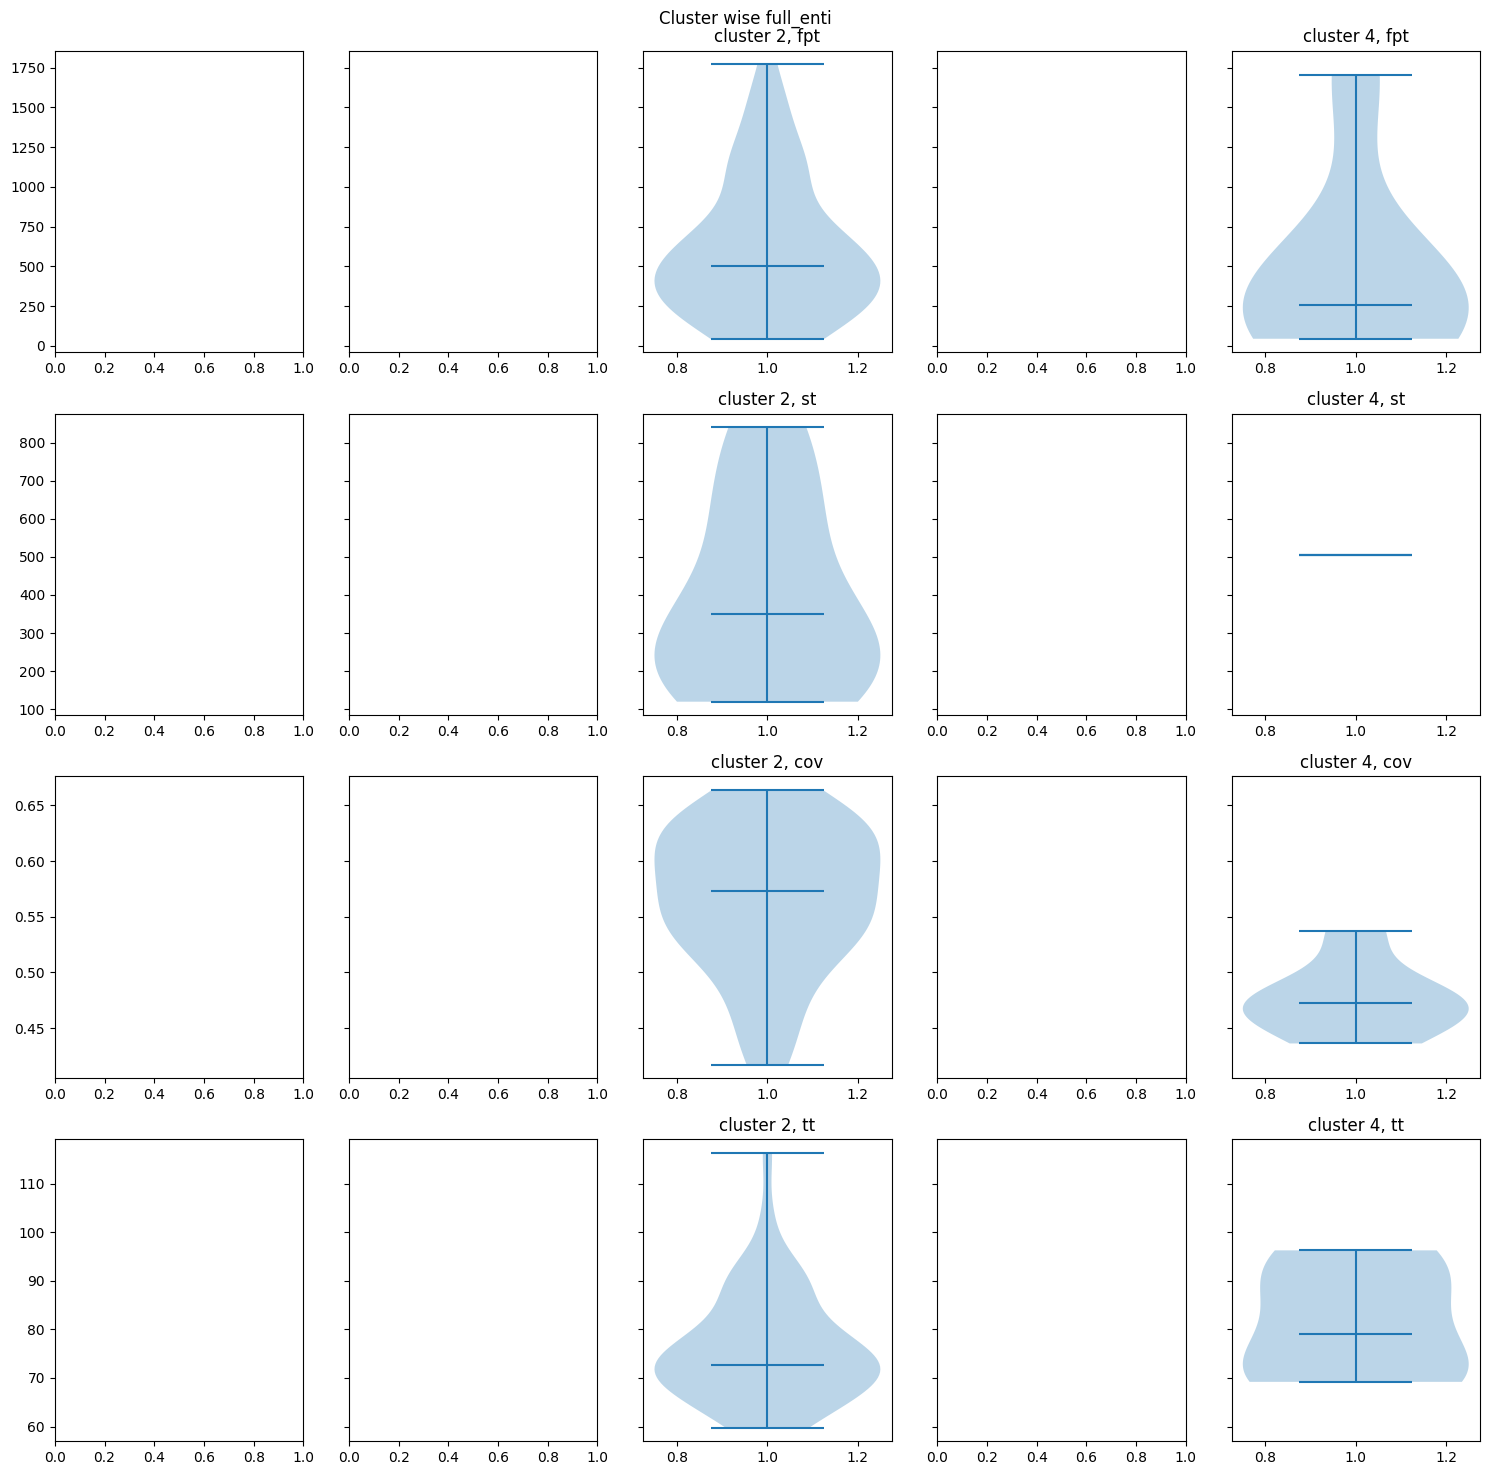

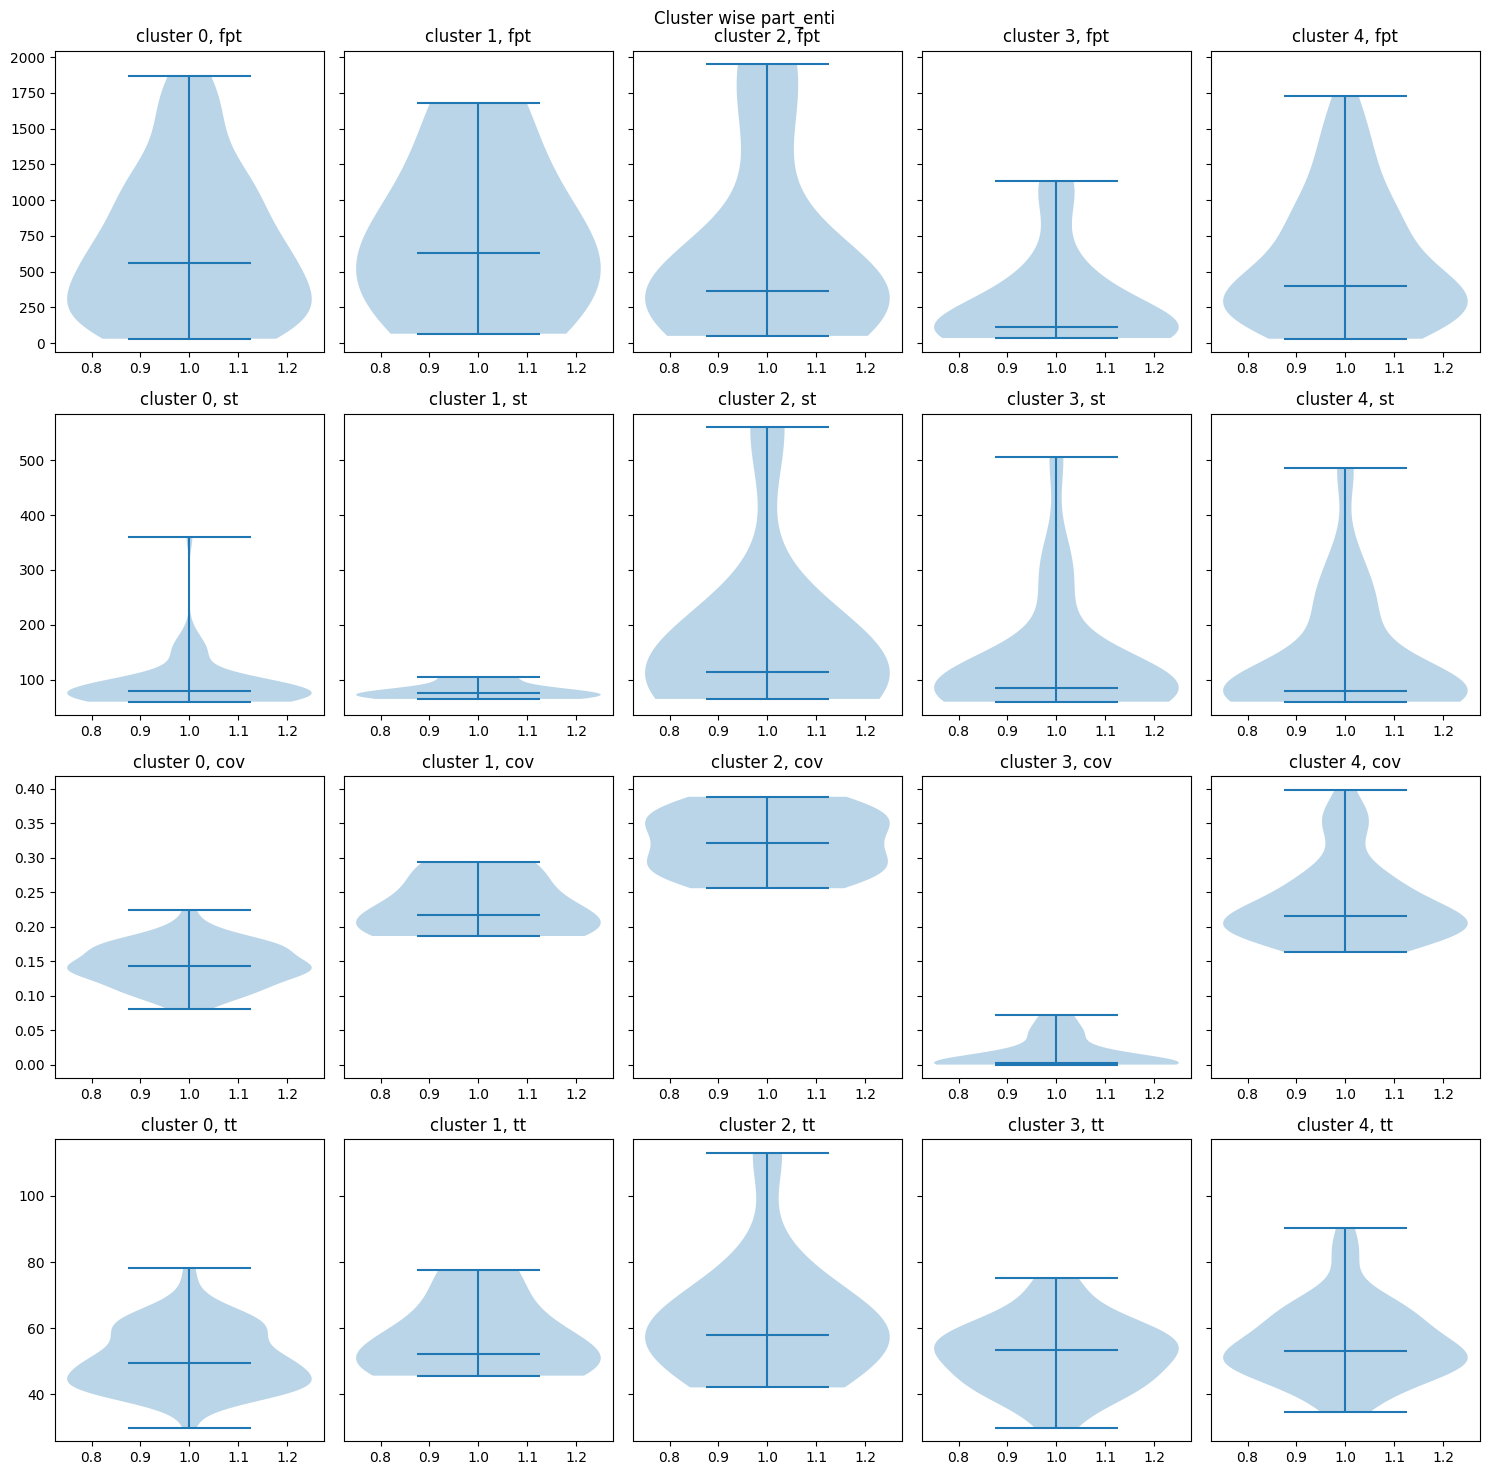

full_enti
full_fn


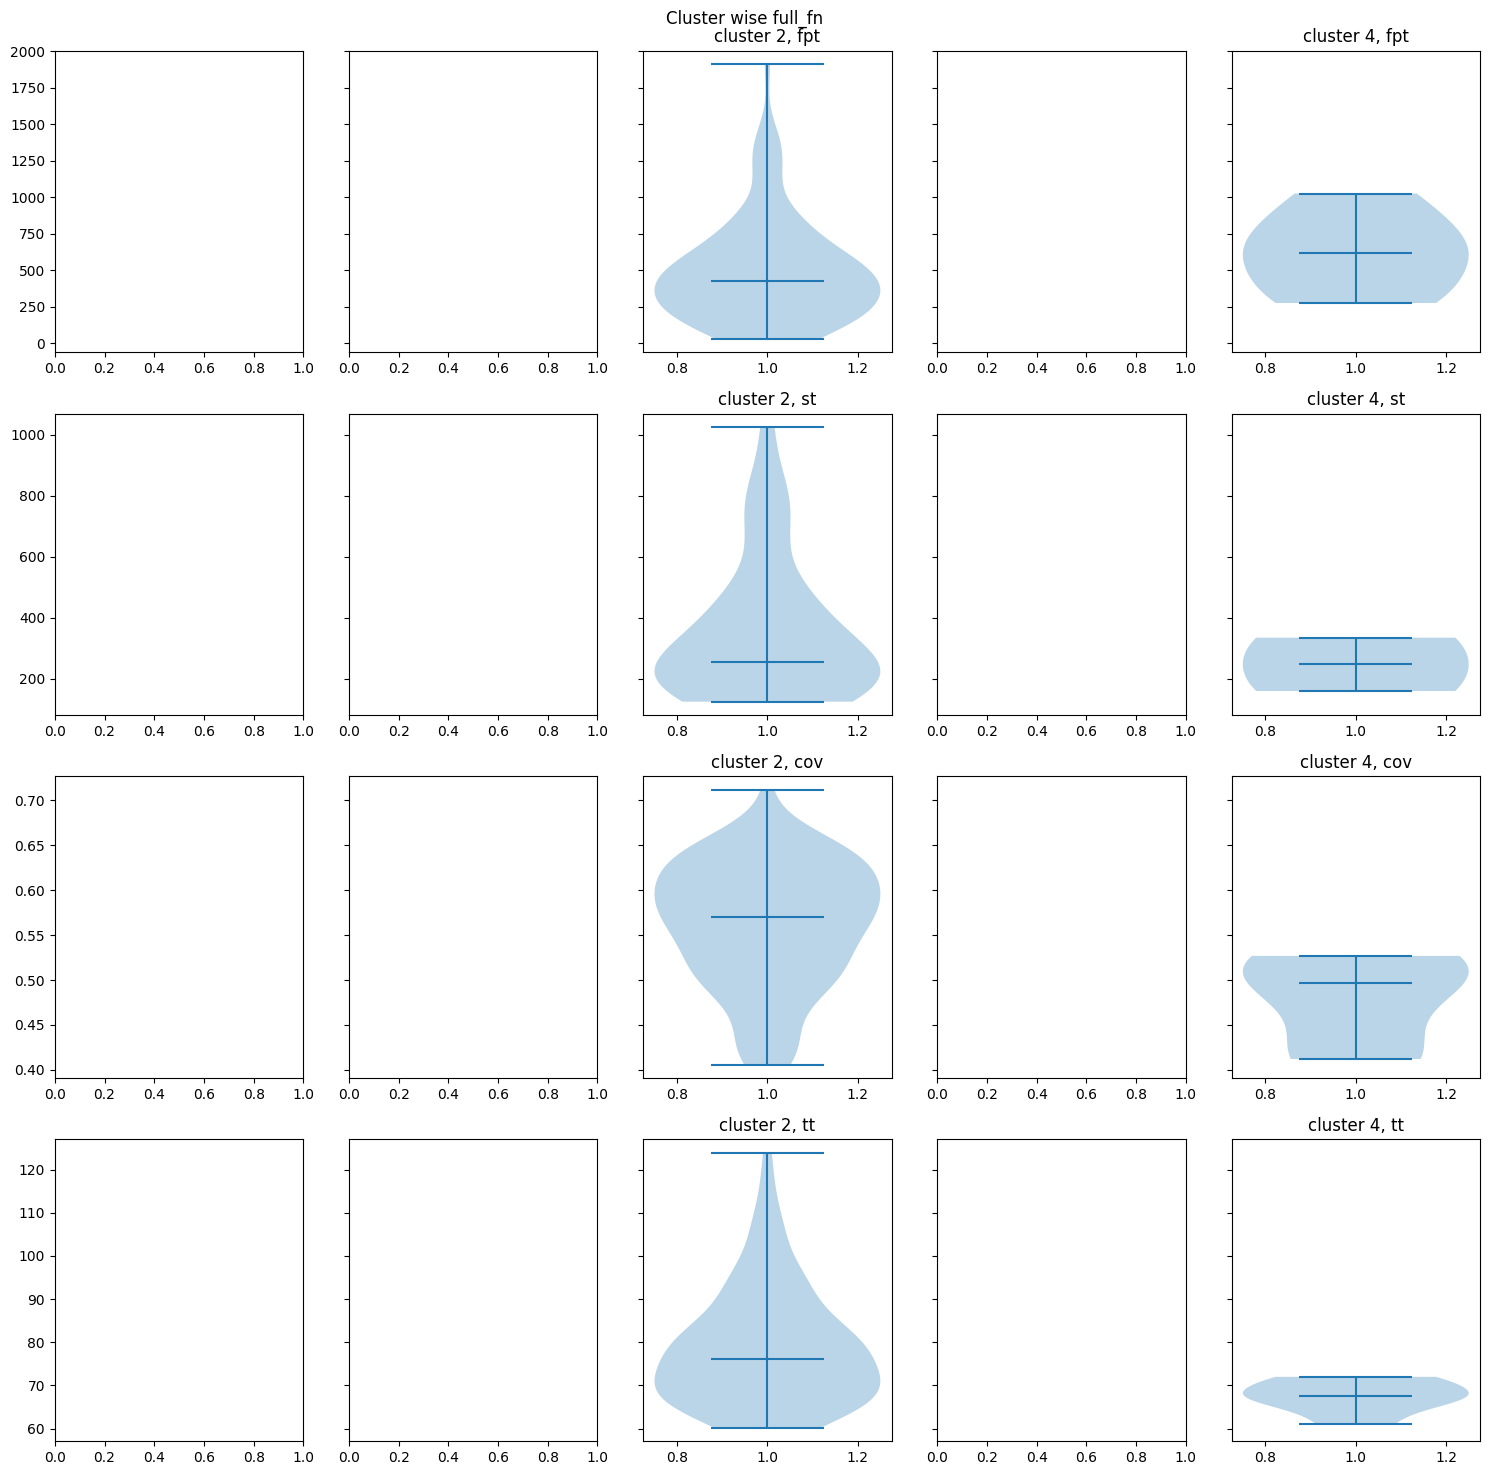

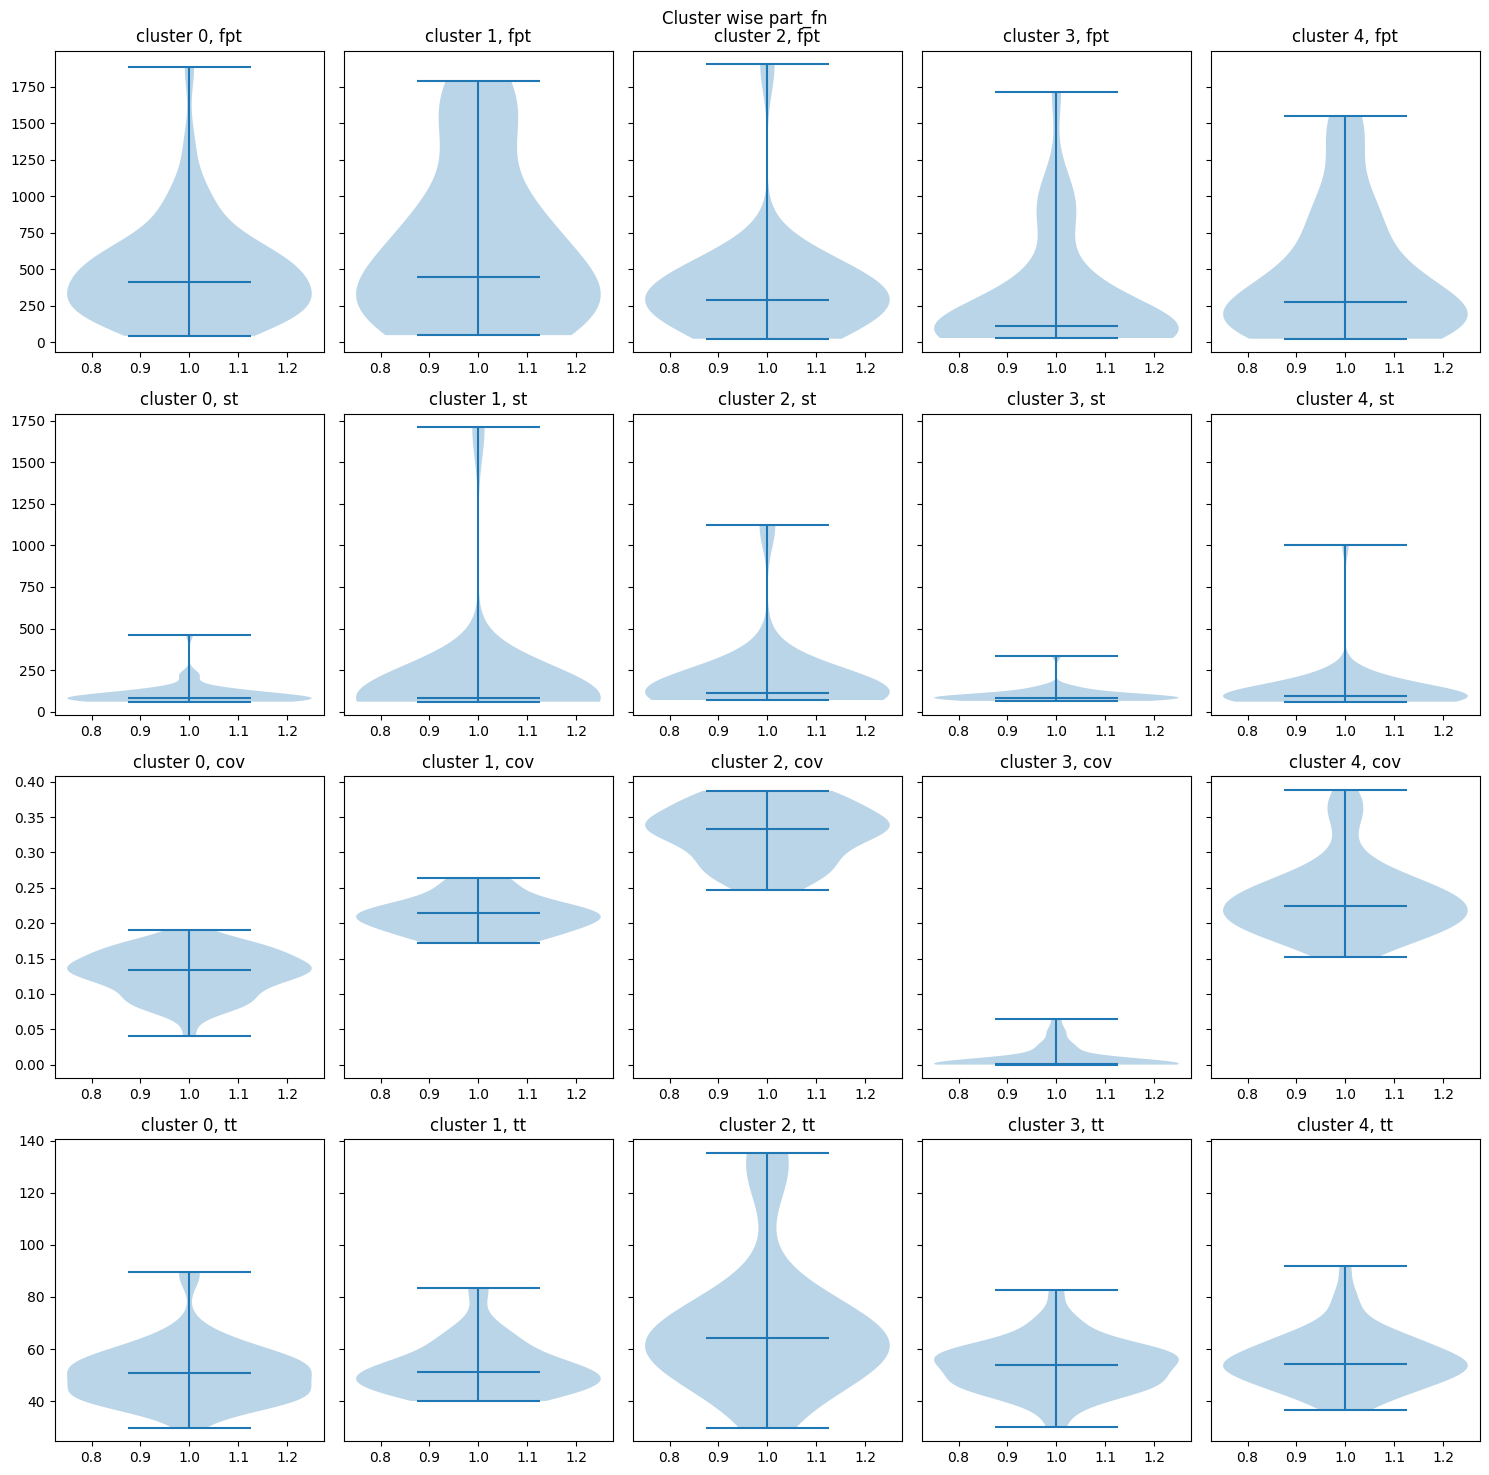

full_fn
full_lha


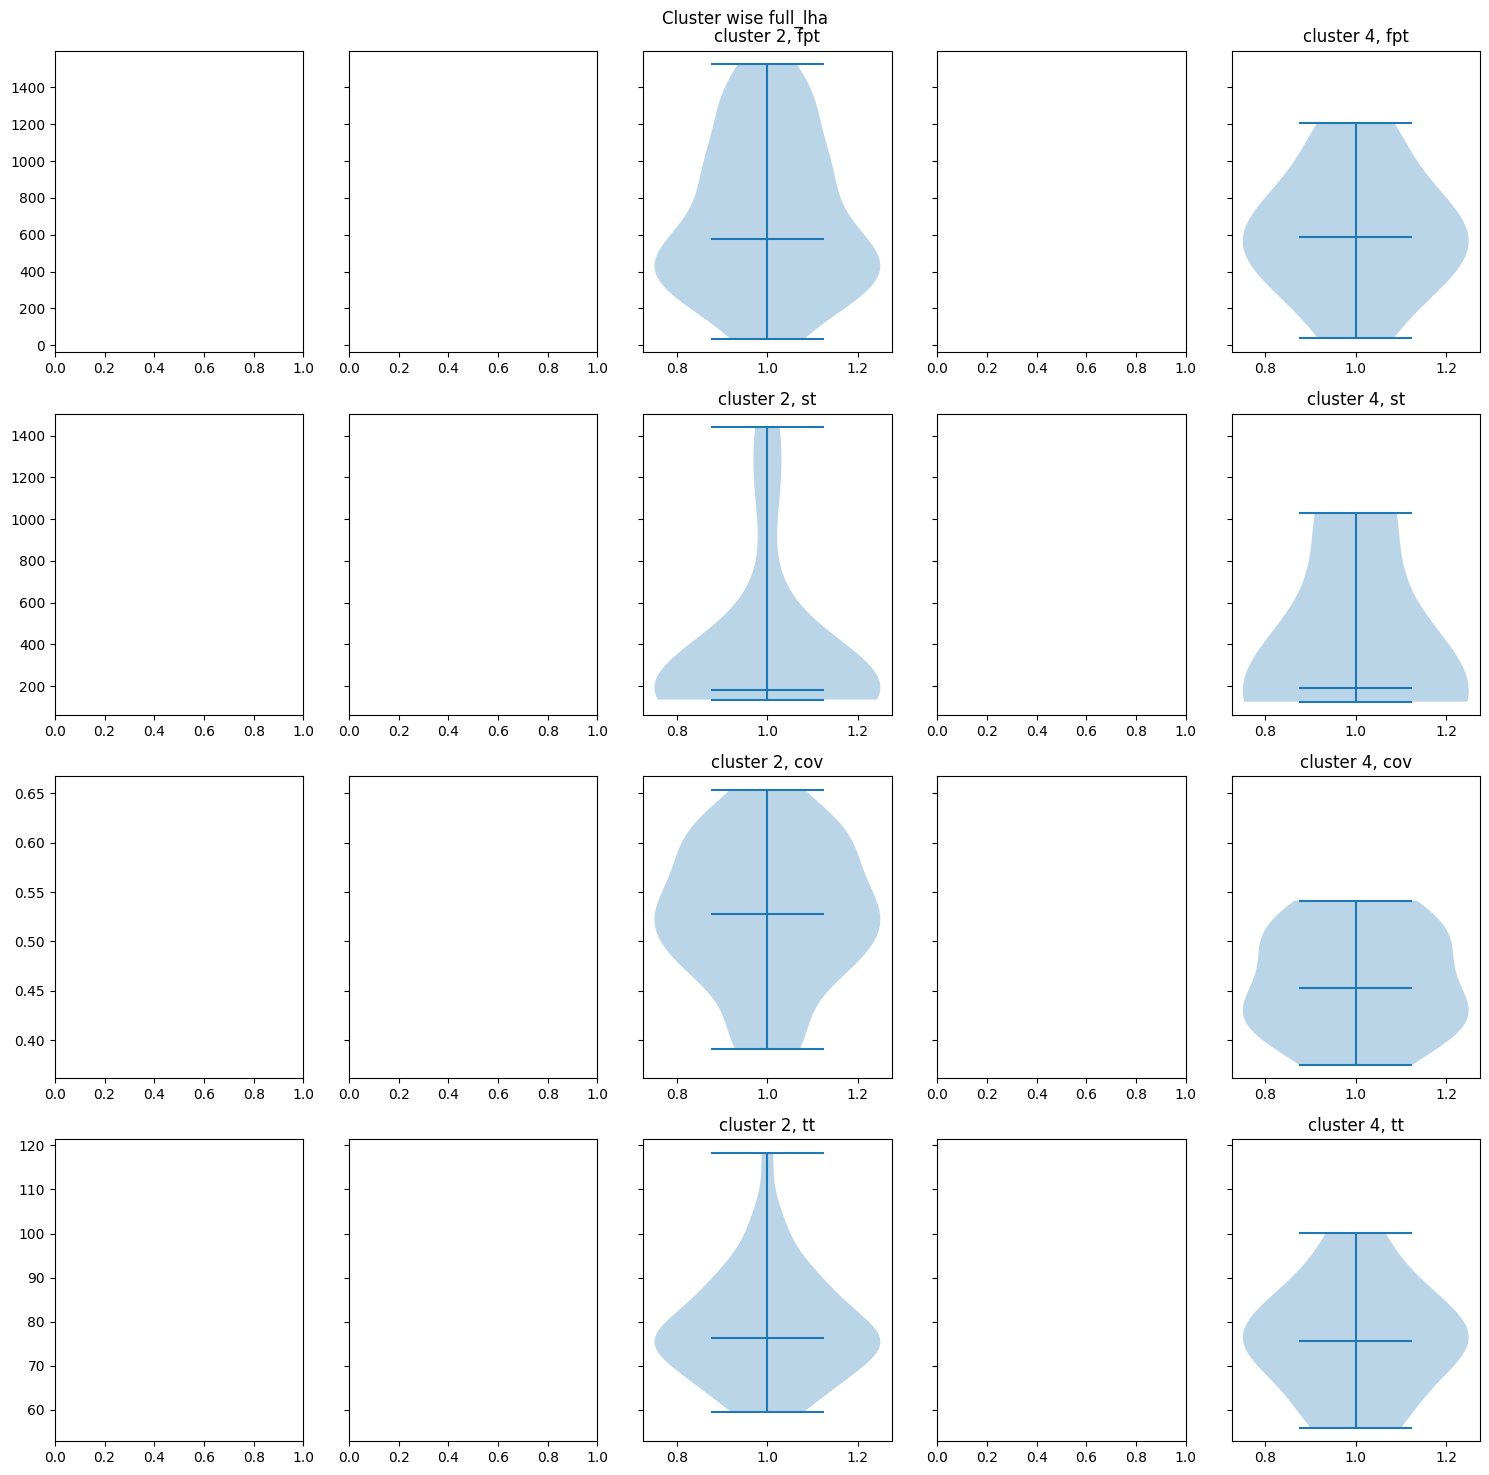

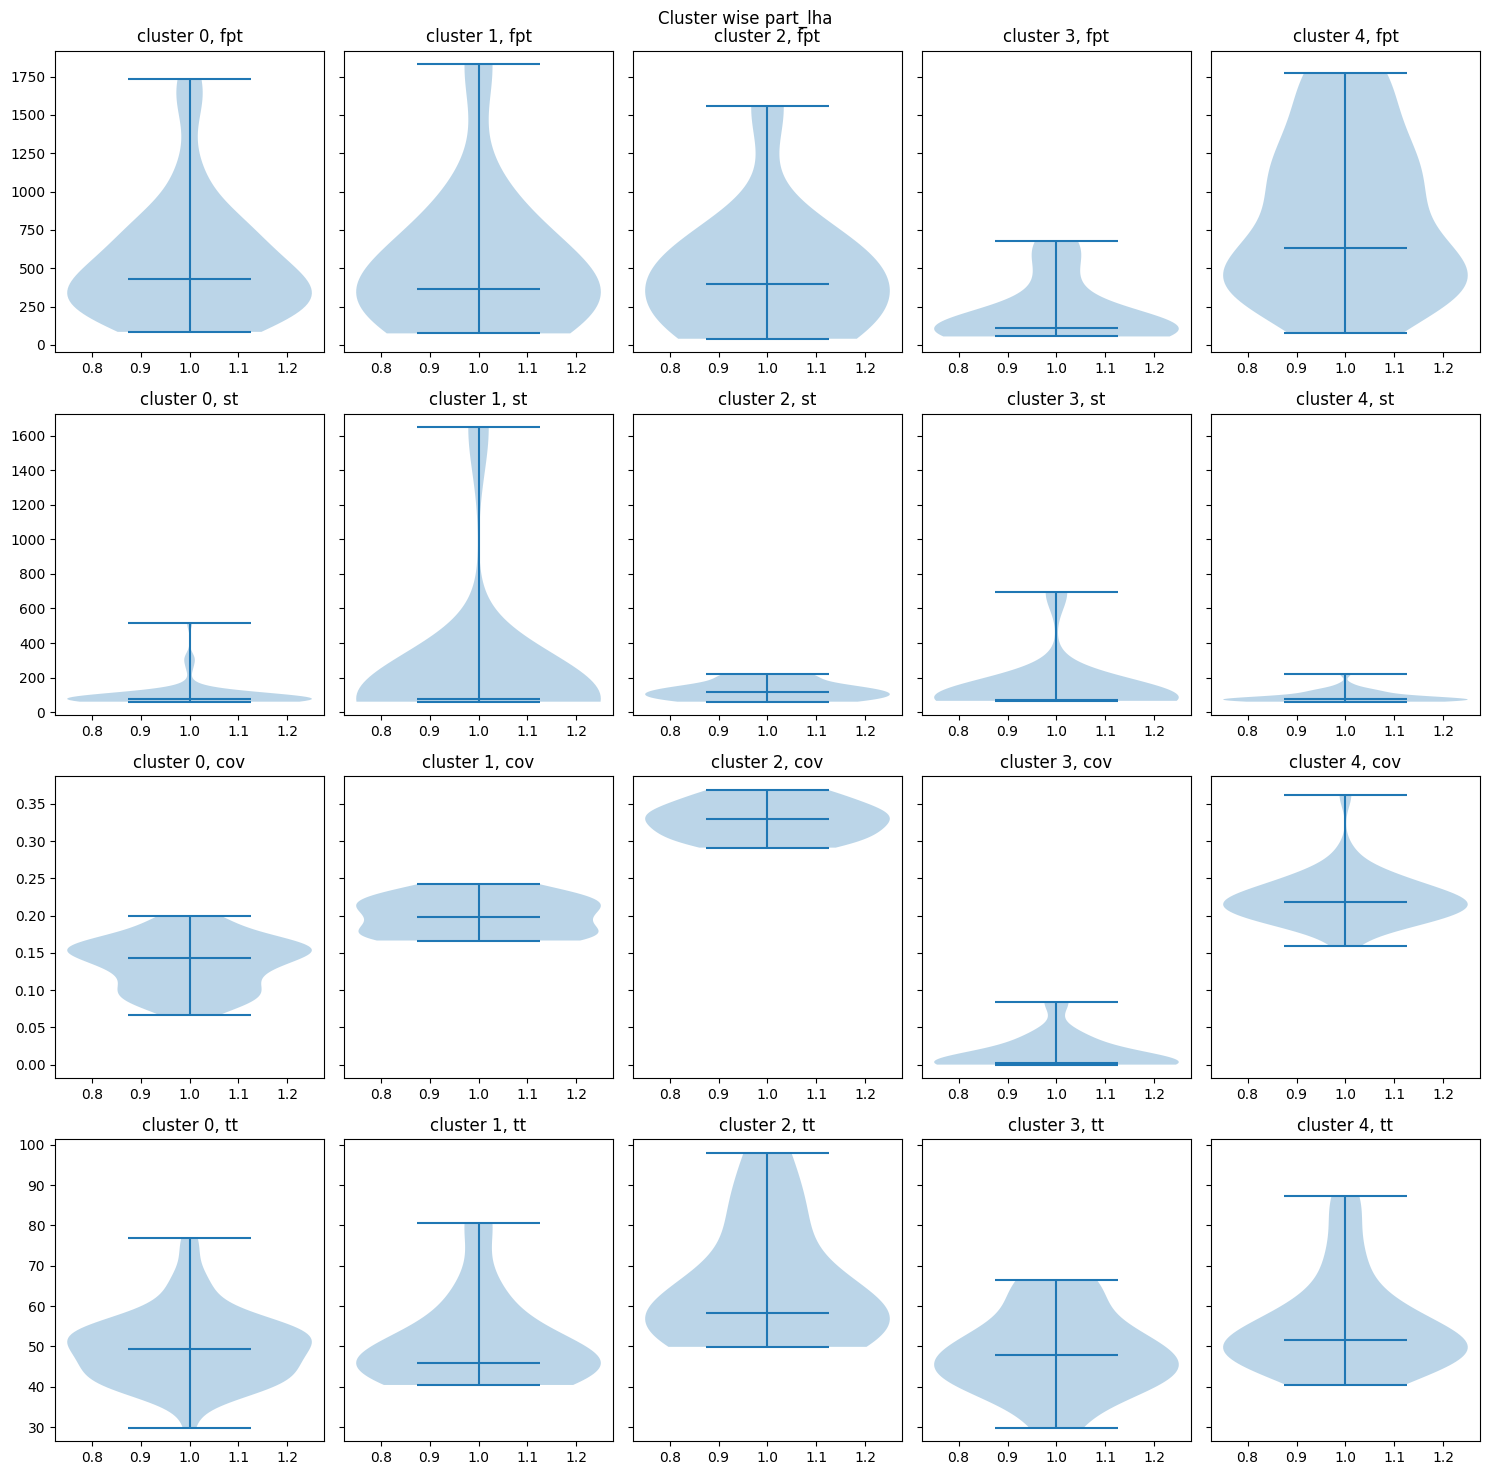

full_lha
full_lsc


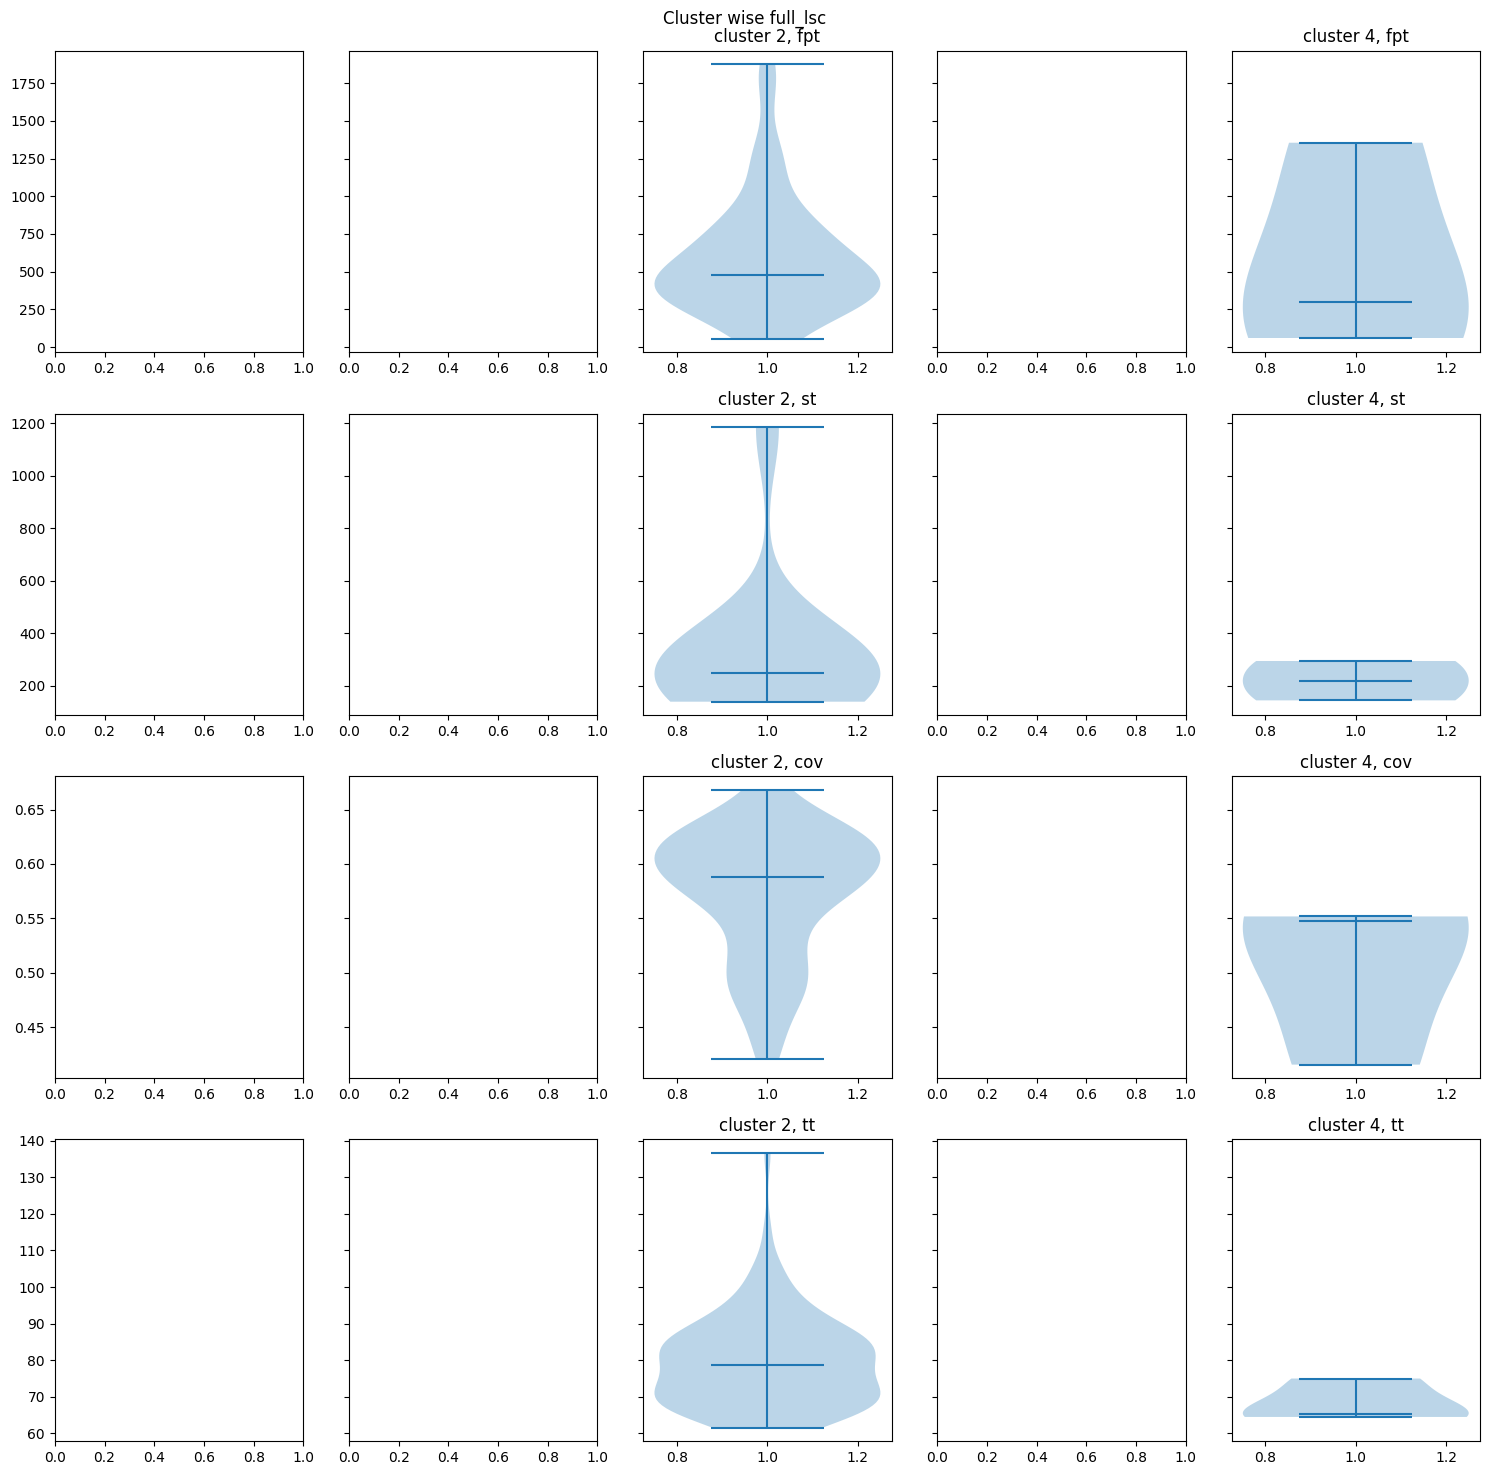

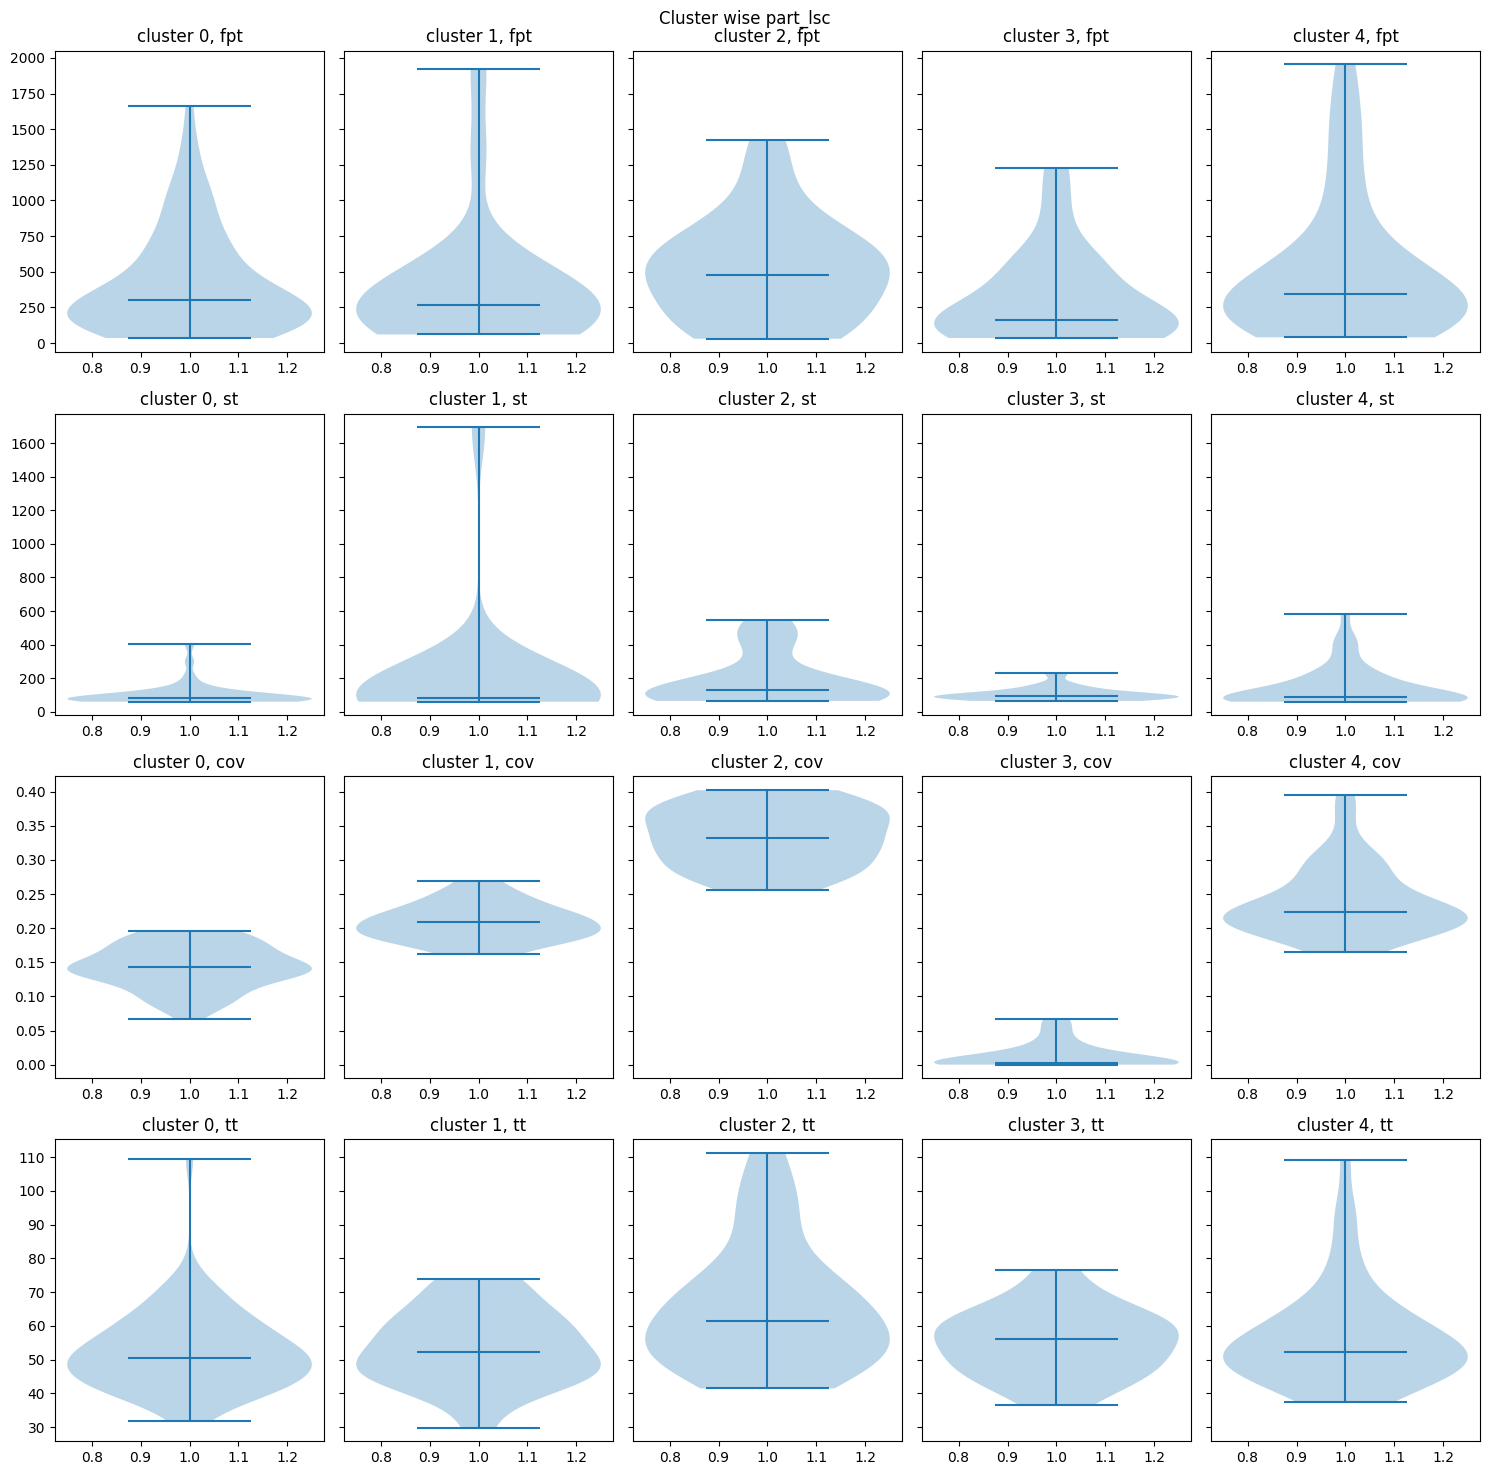

full_lsc
full_mob


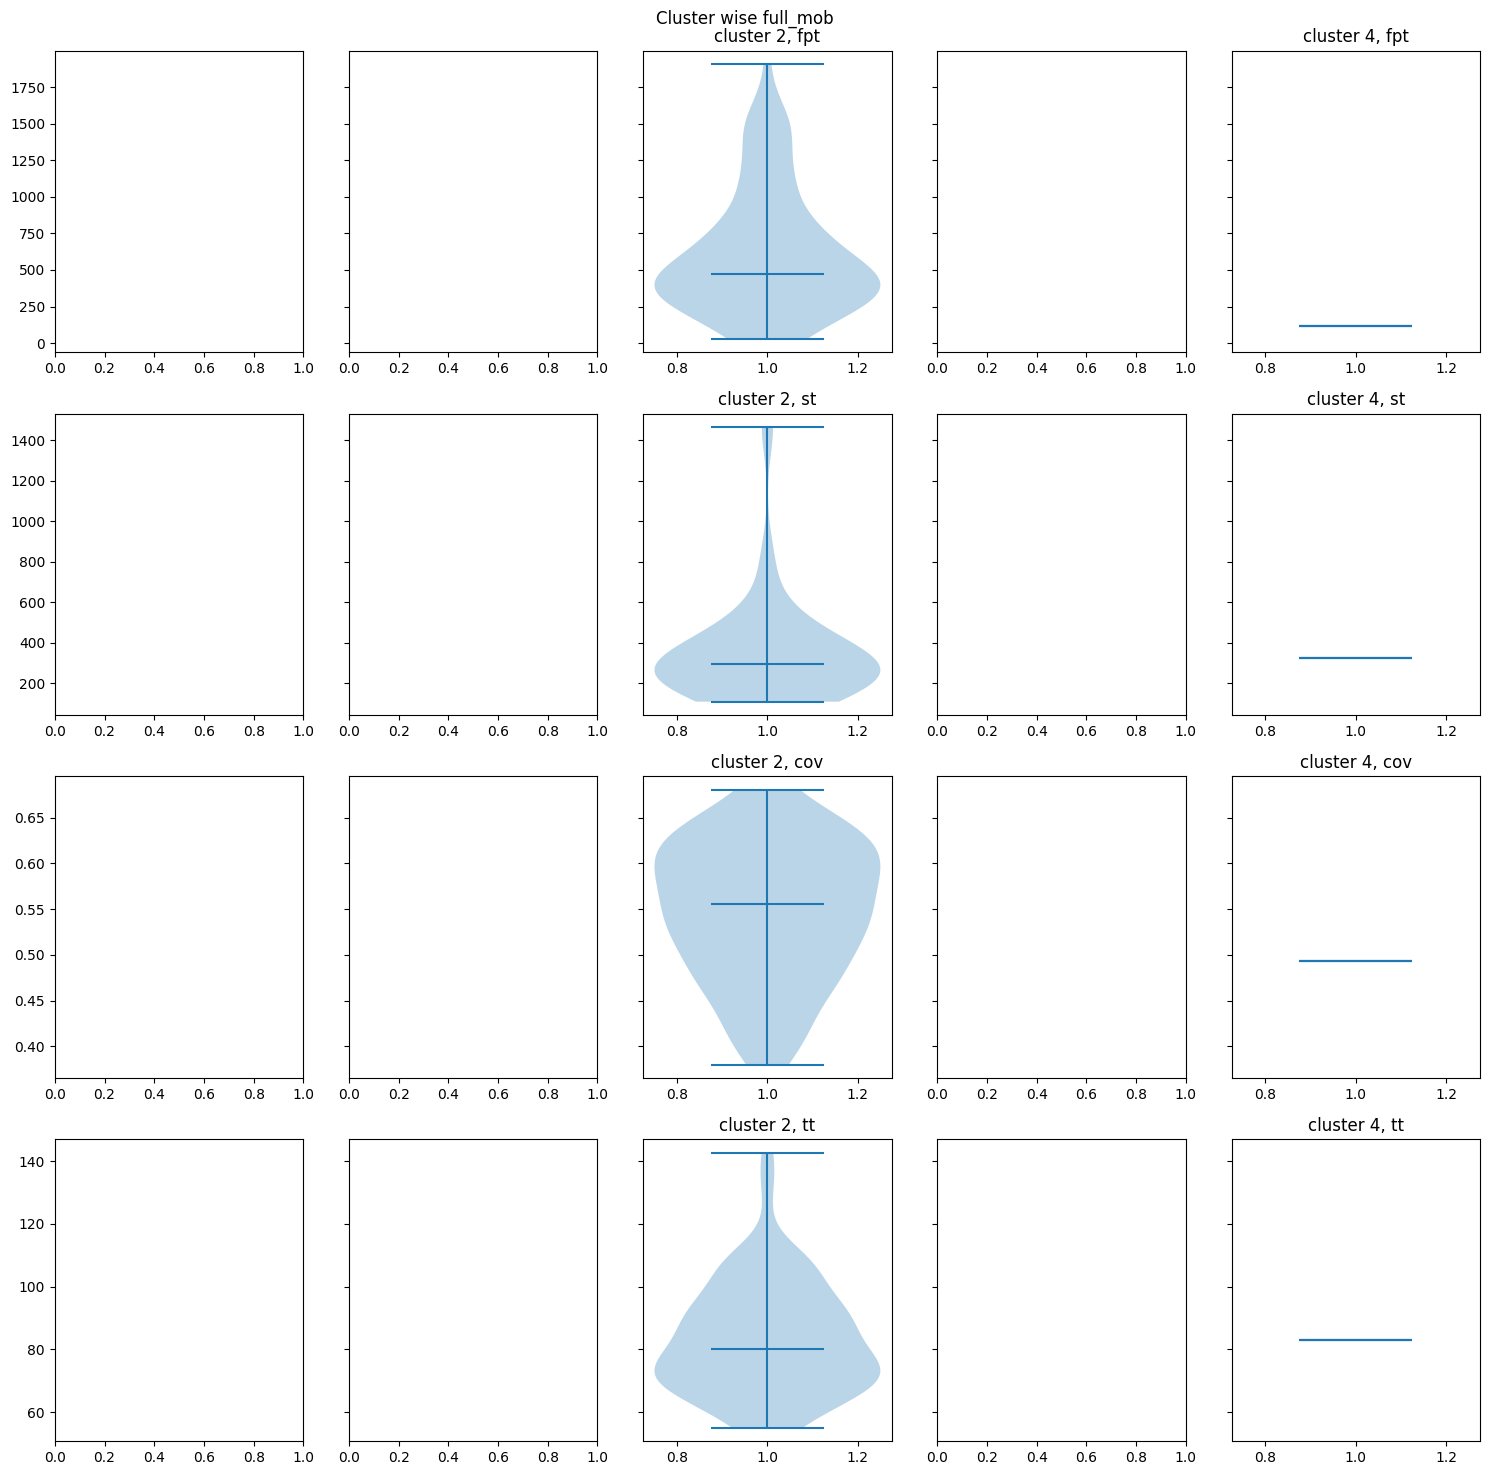

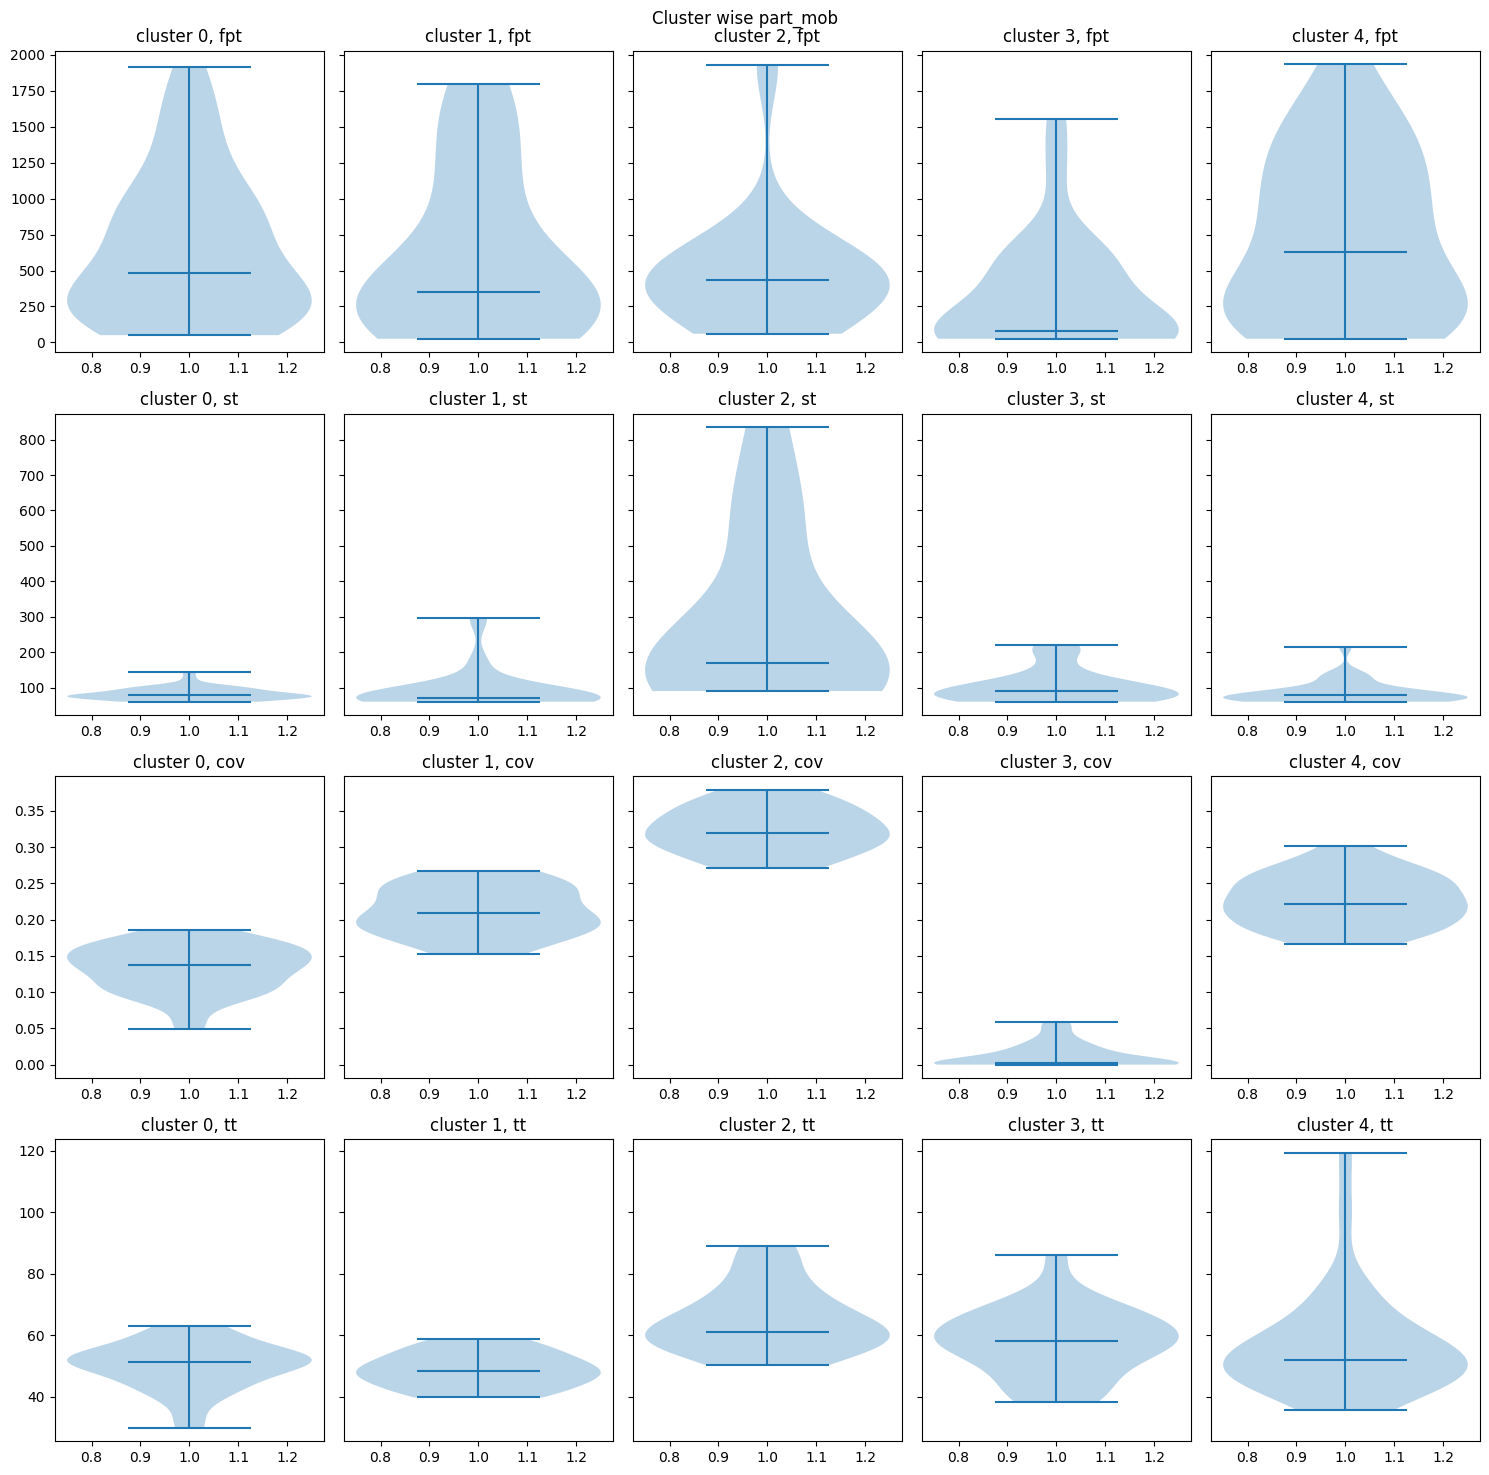

full_mob
full_mop


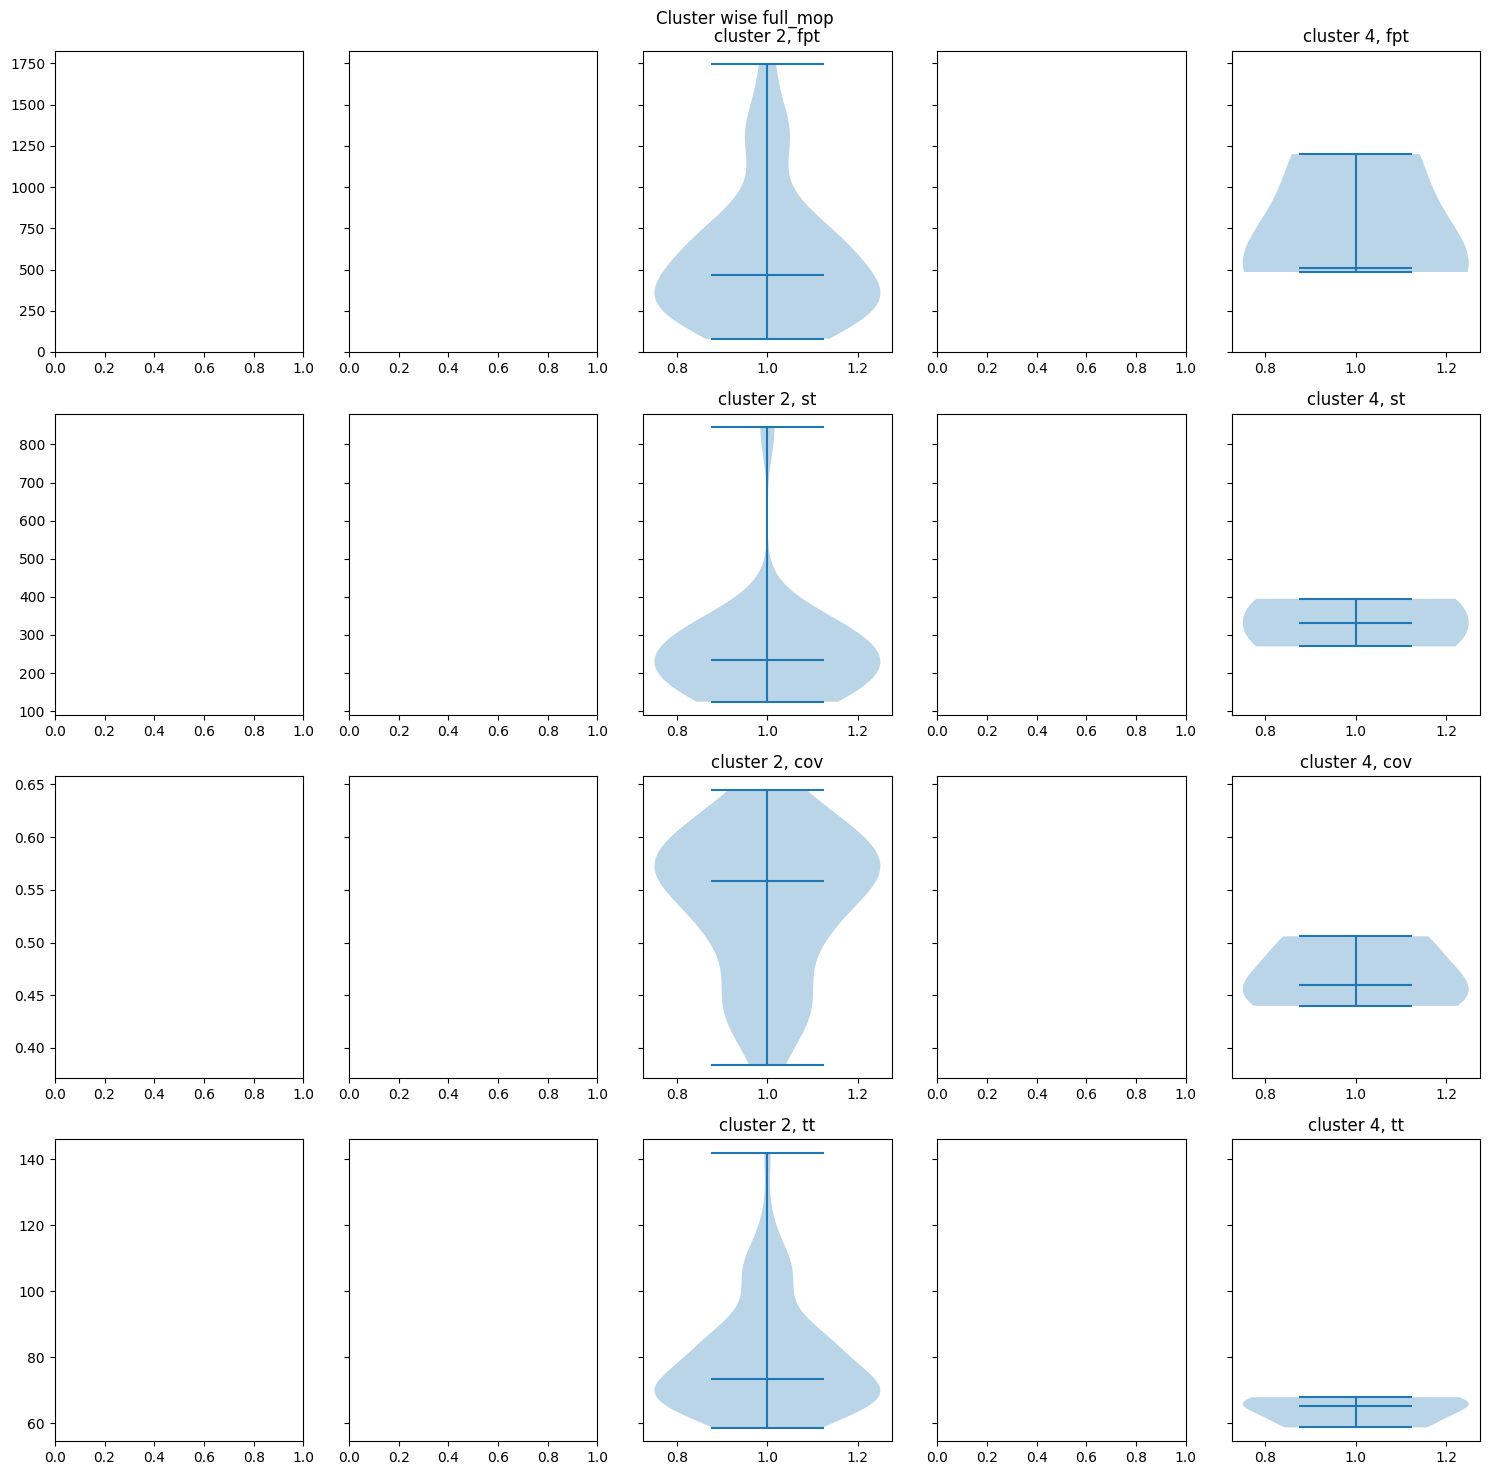

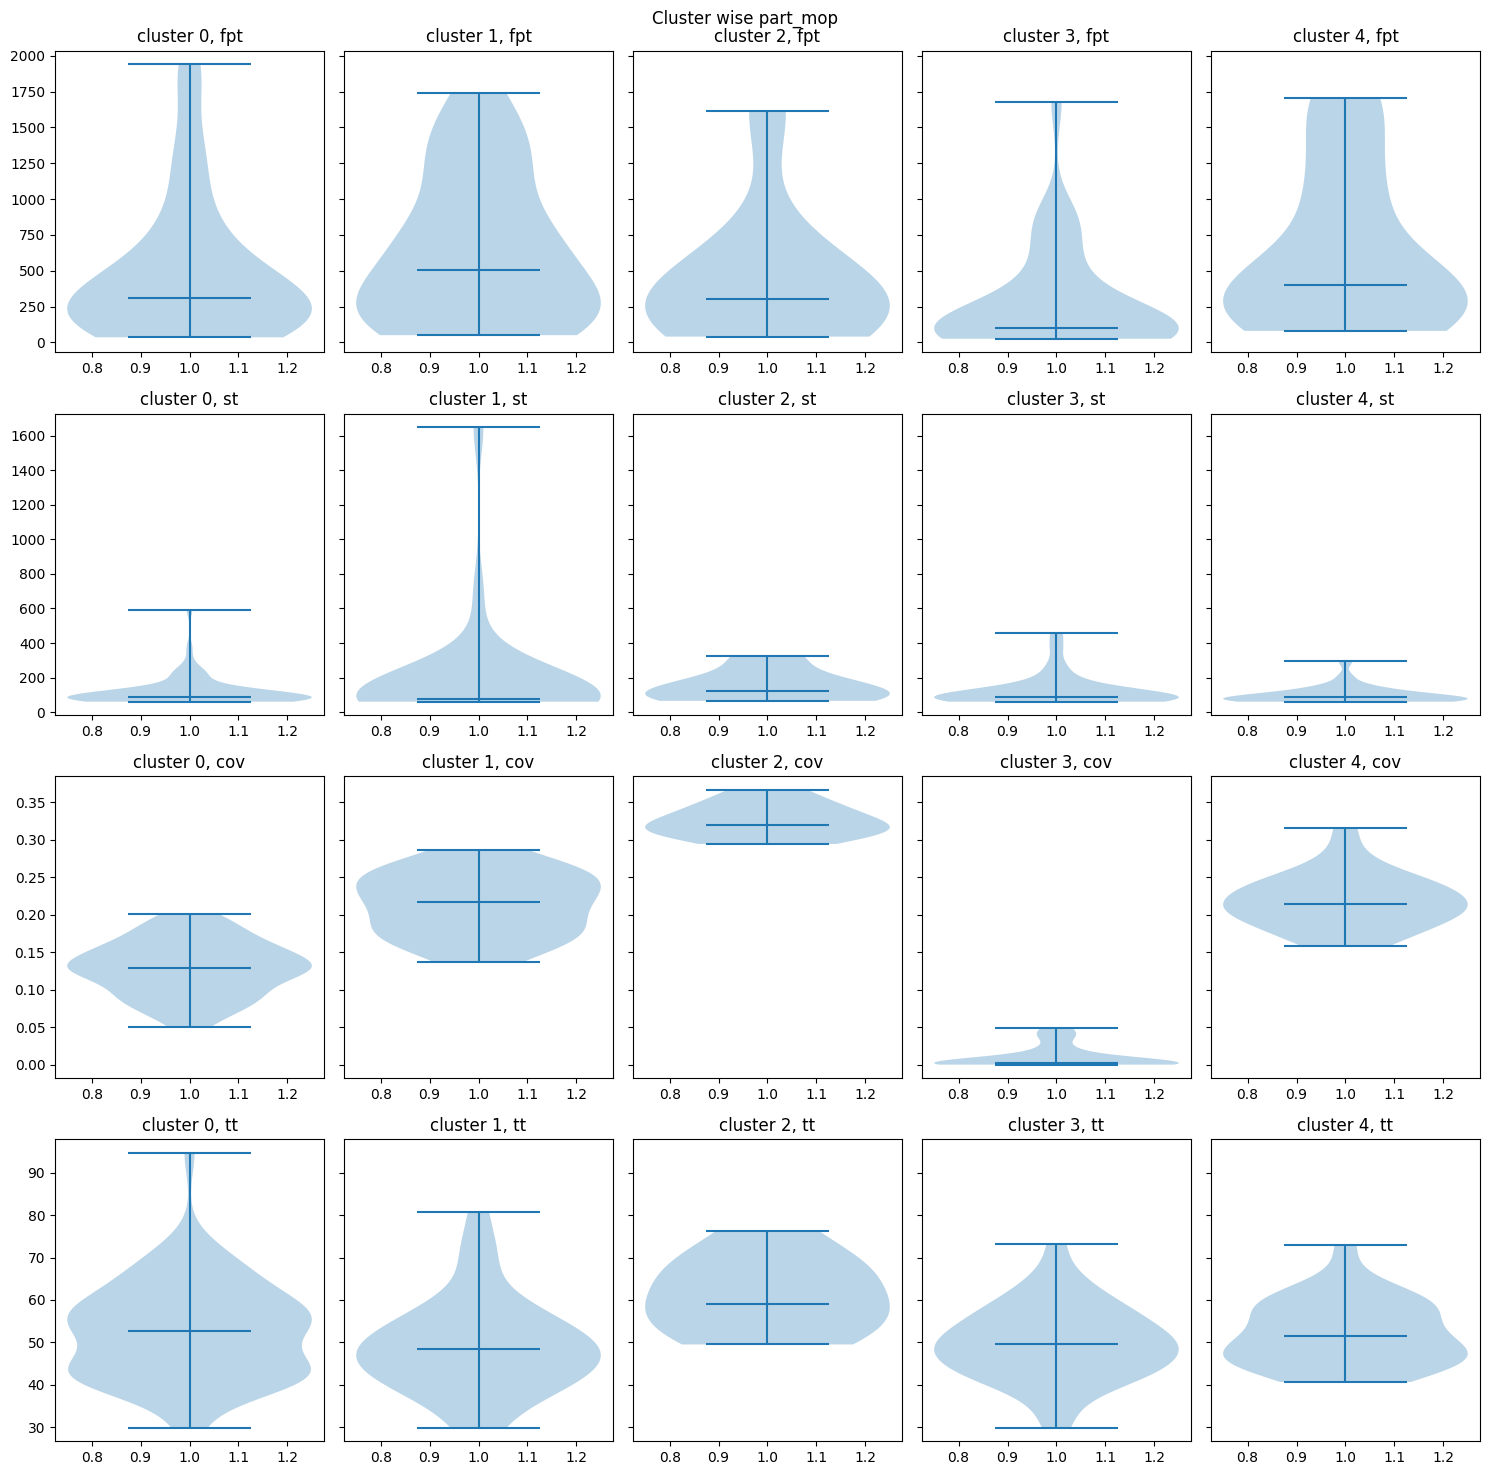

full_mop
full_mos


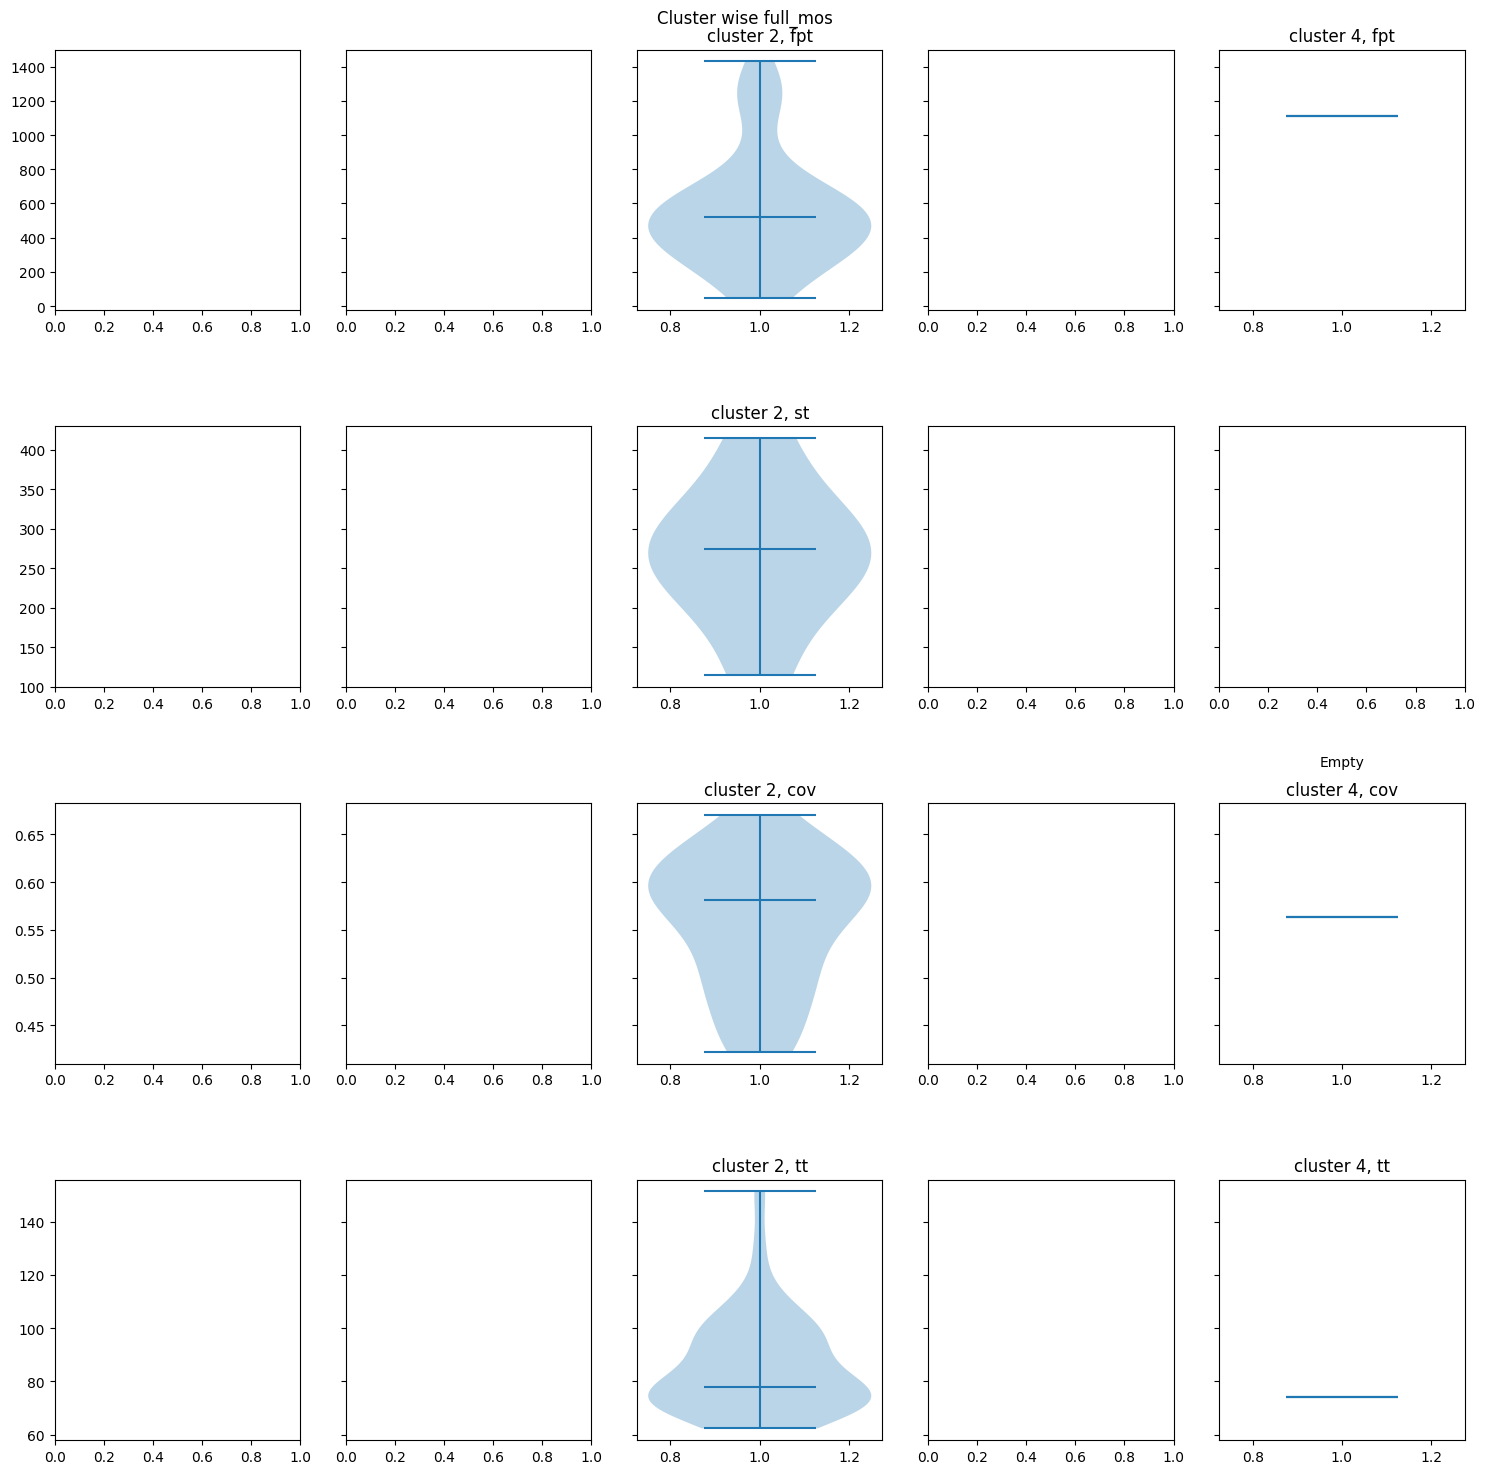

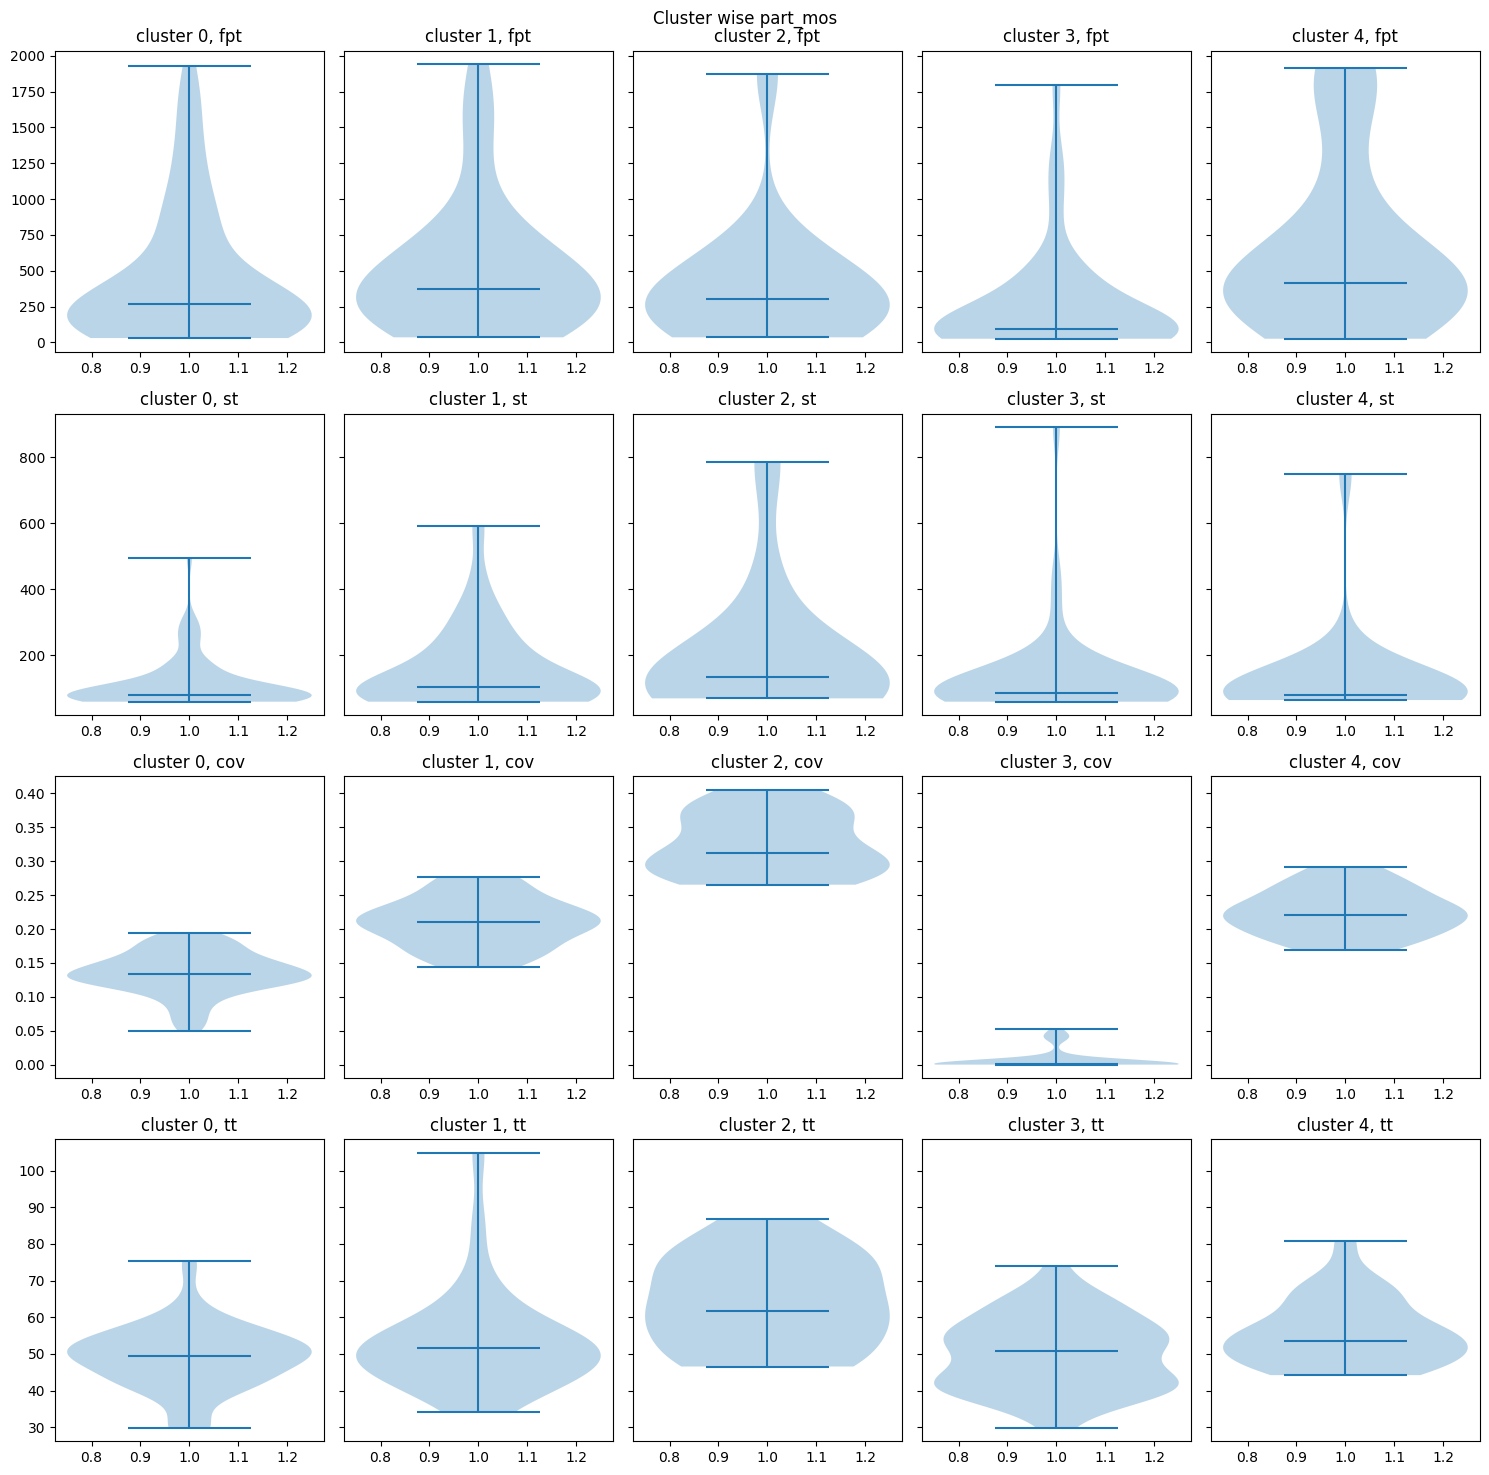

full_mos
full_mrn


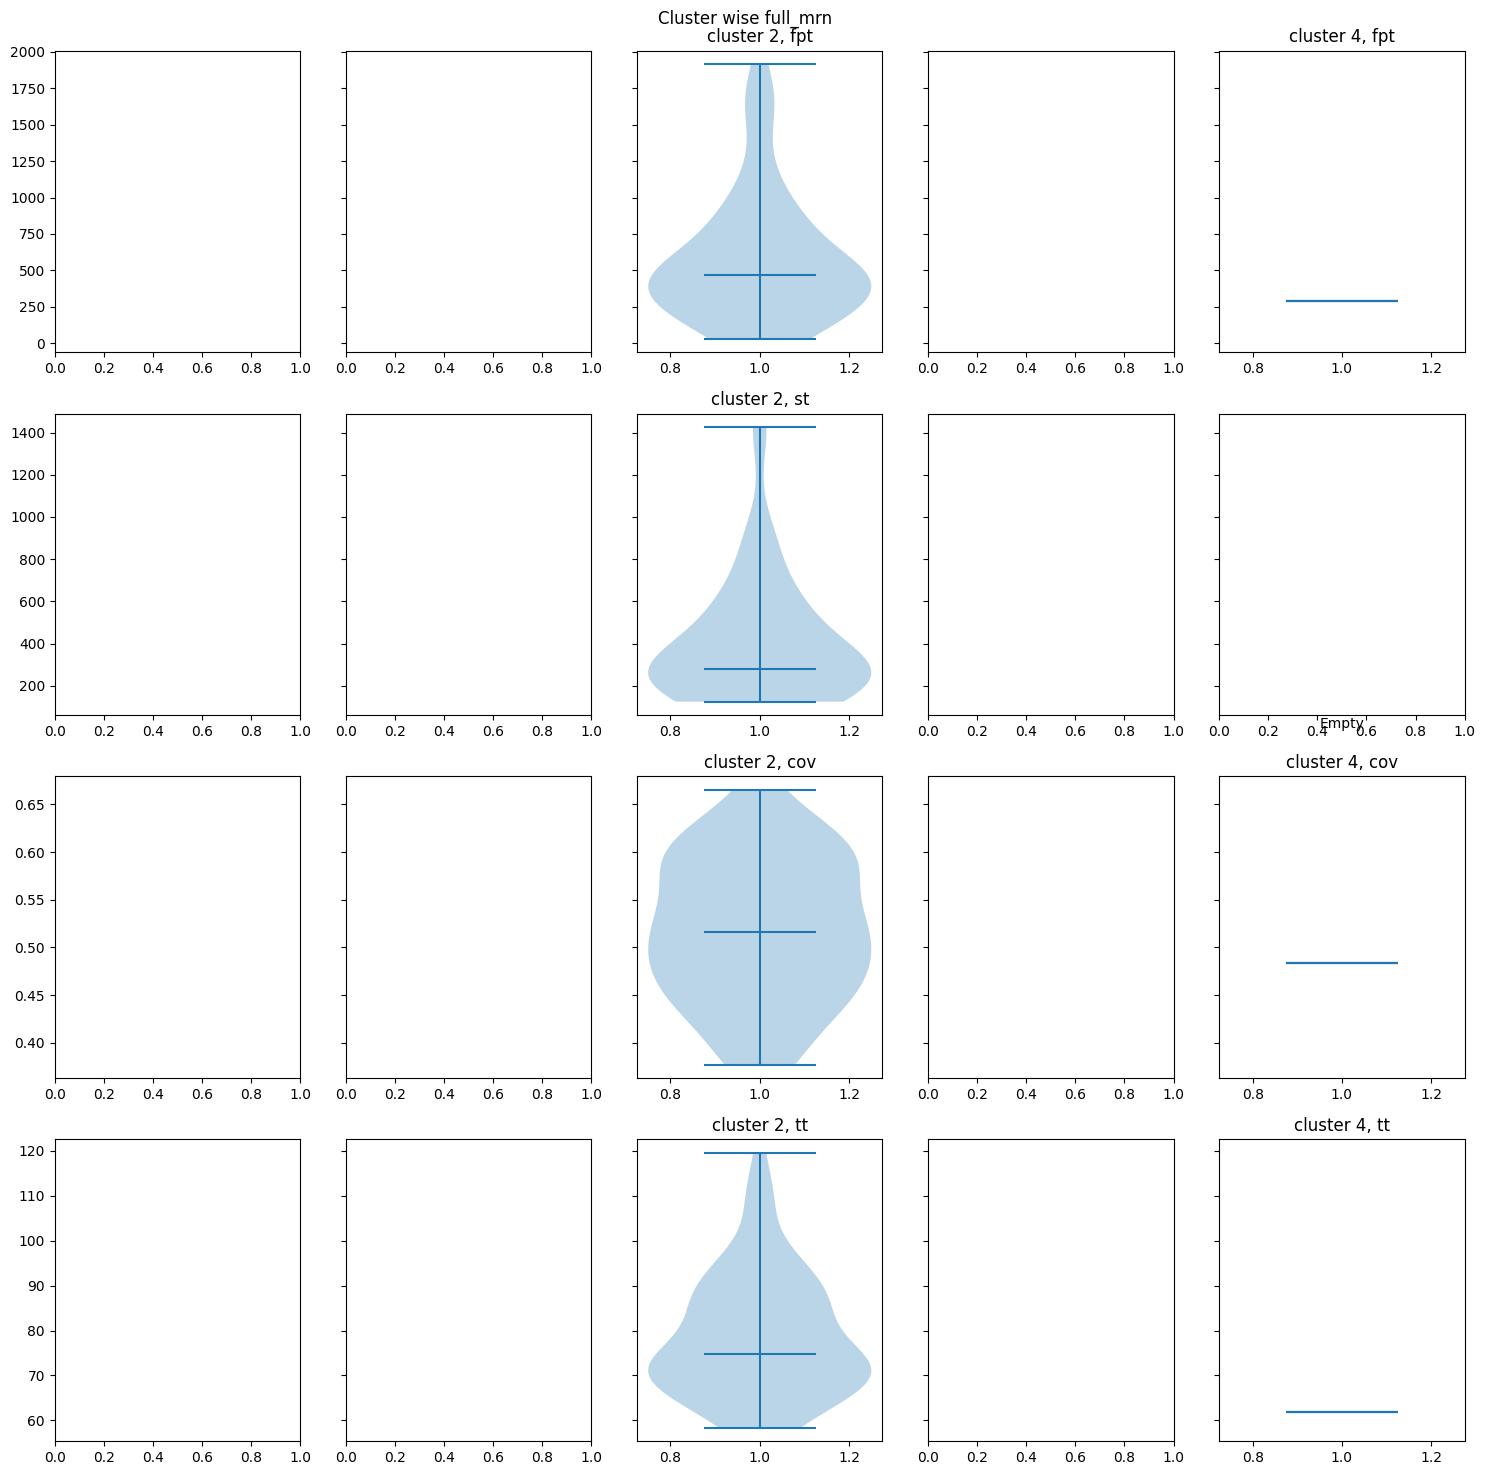

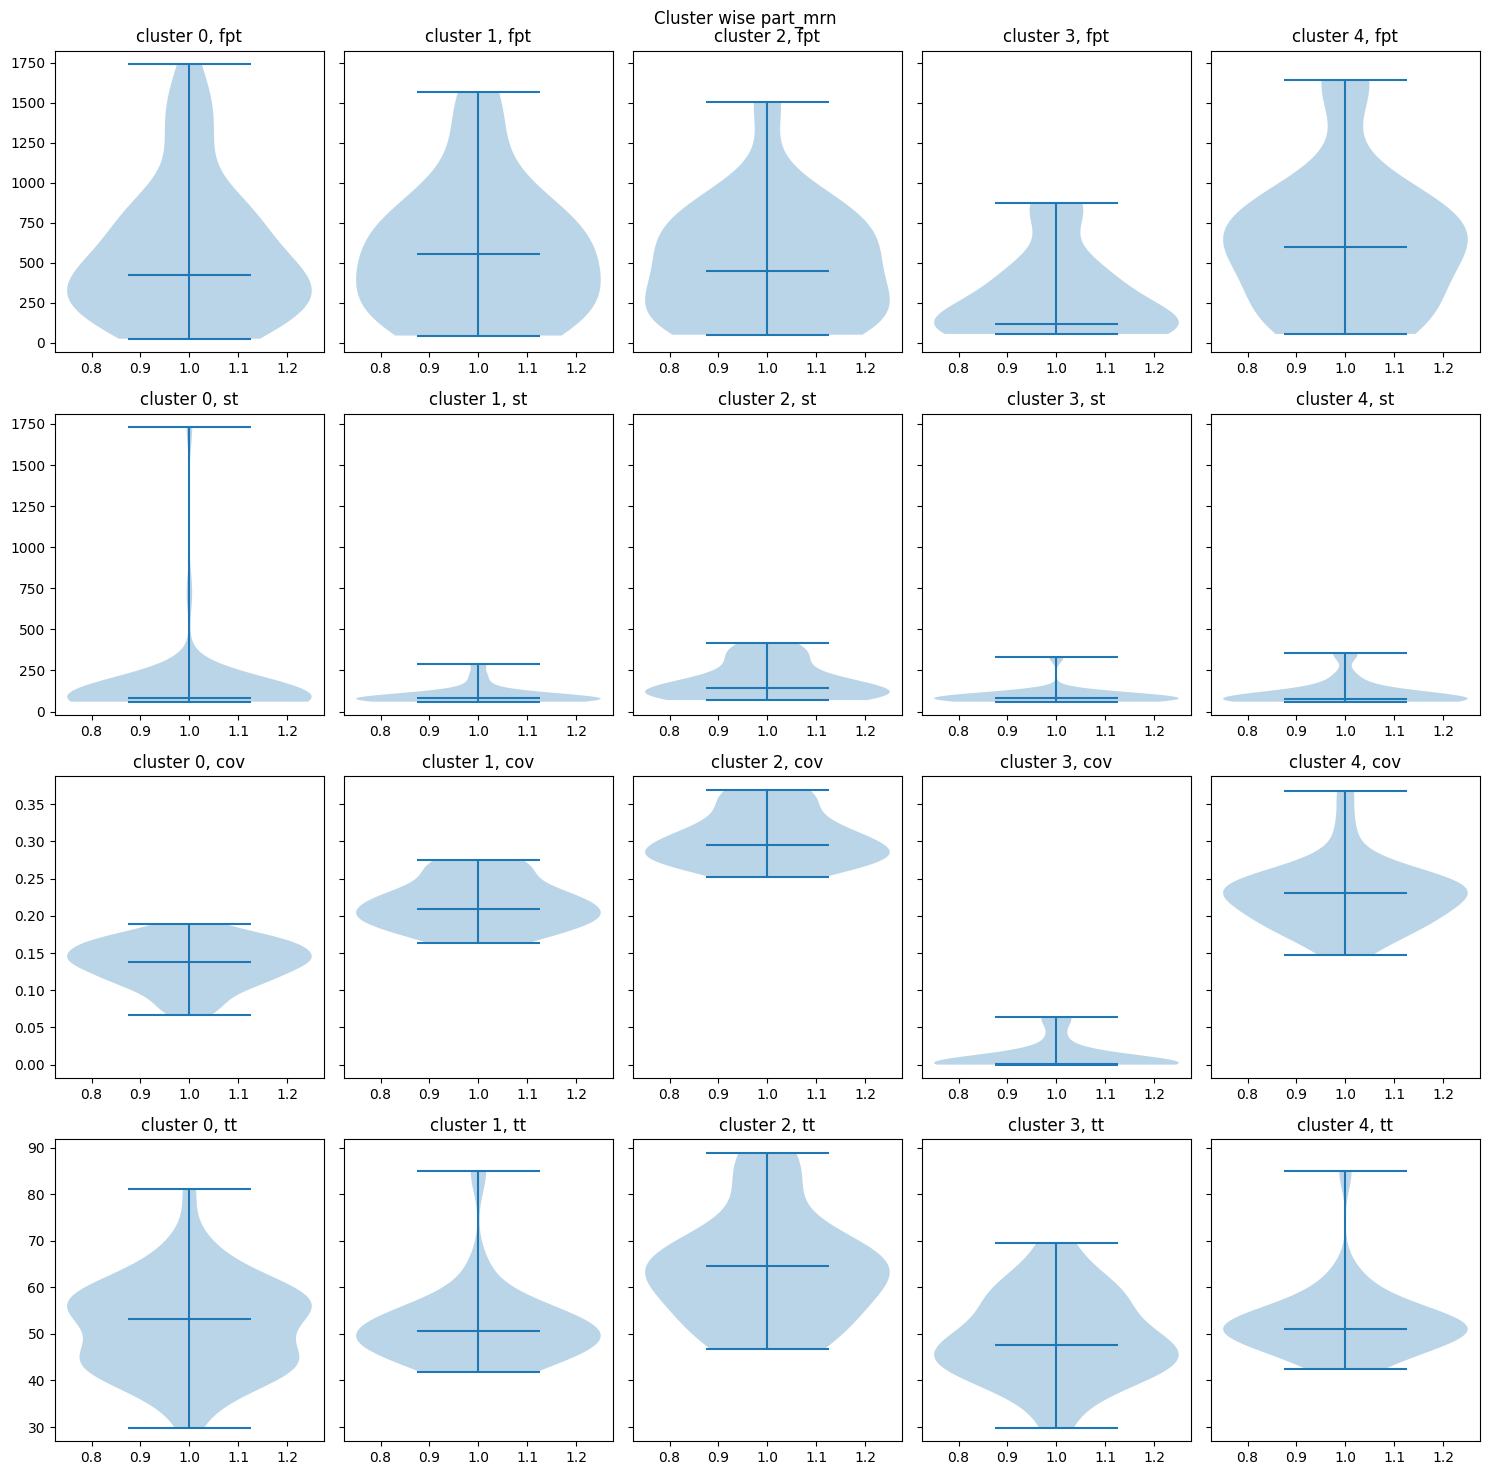

full_mrn
full_orb


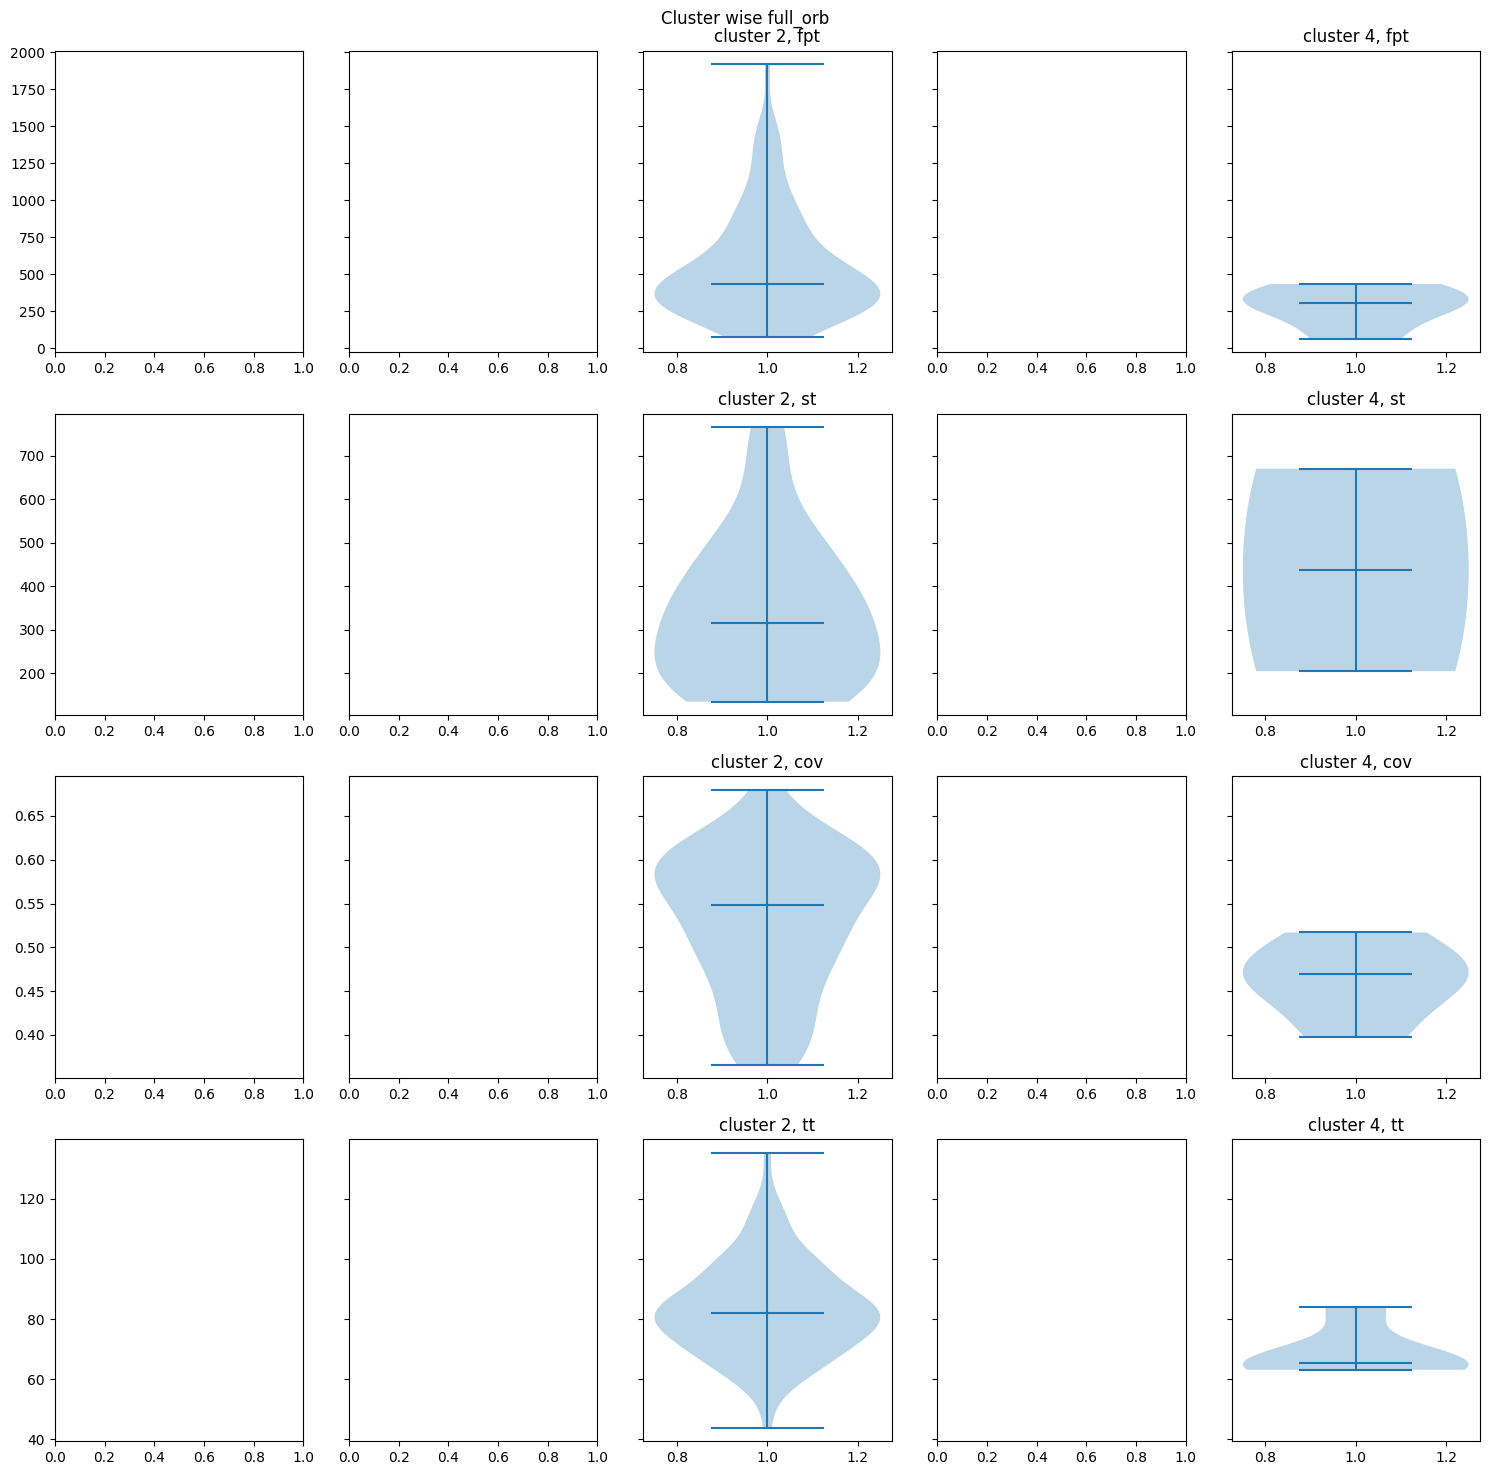

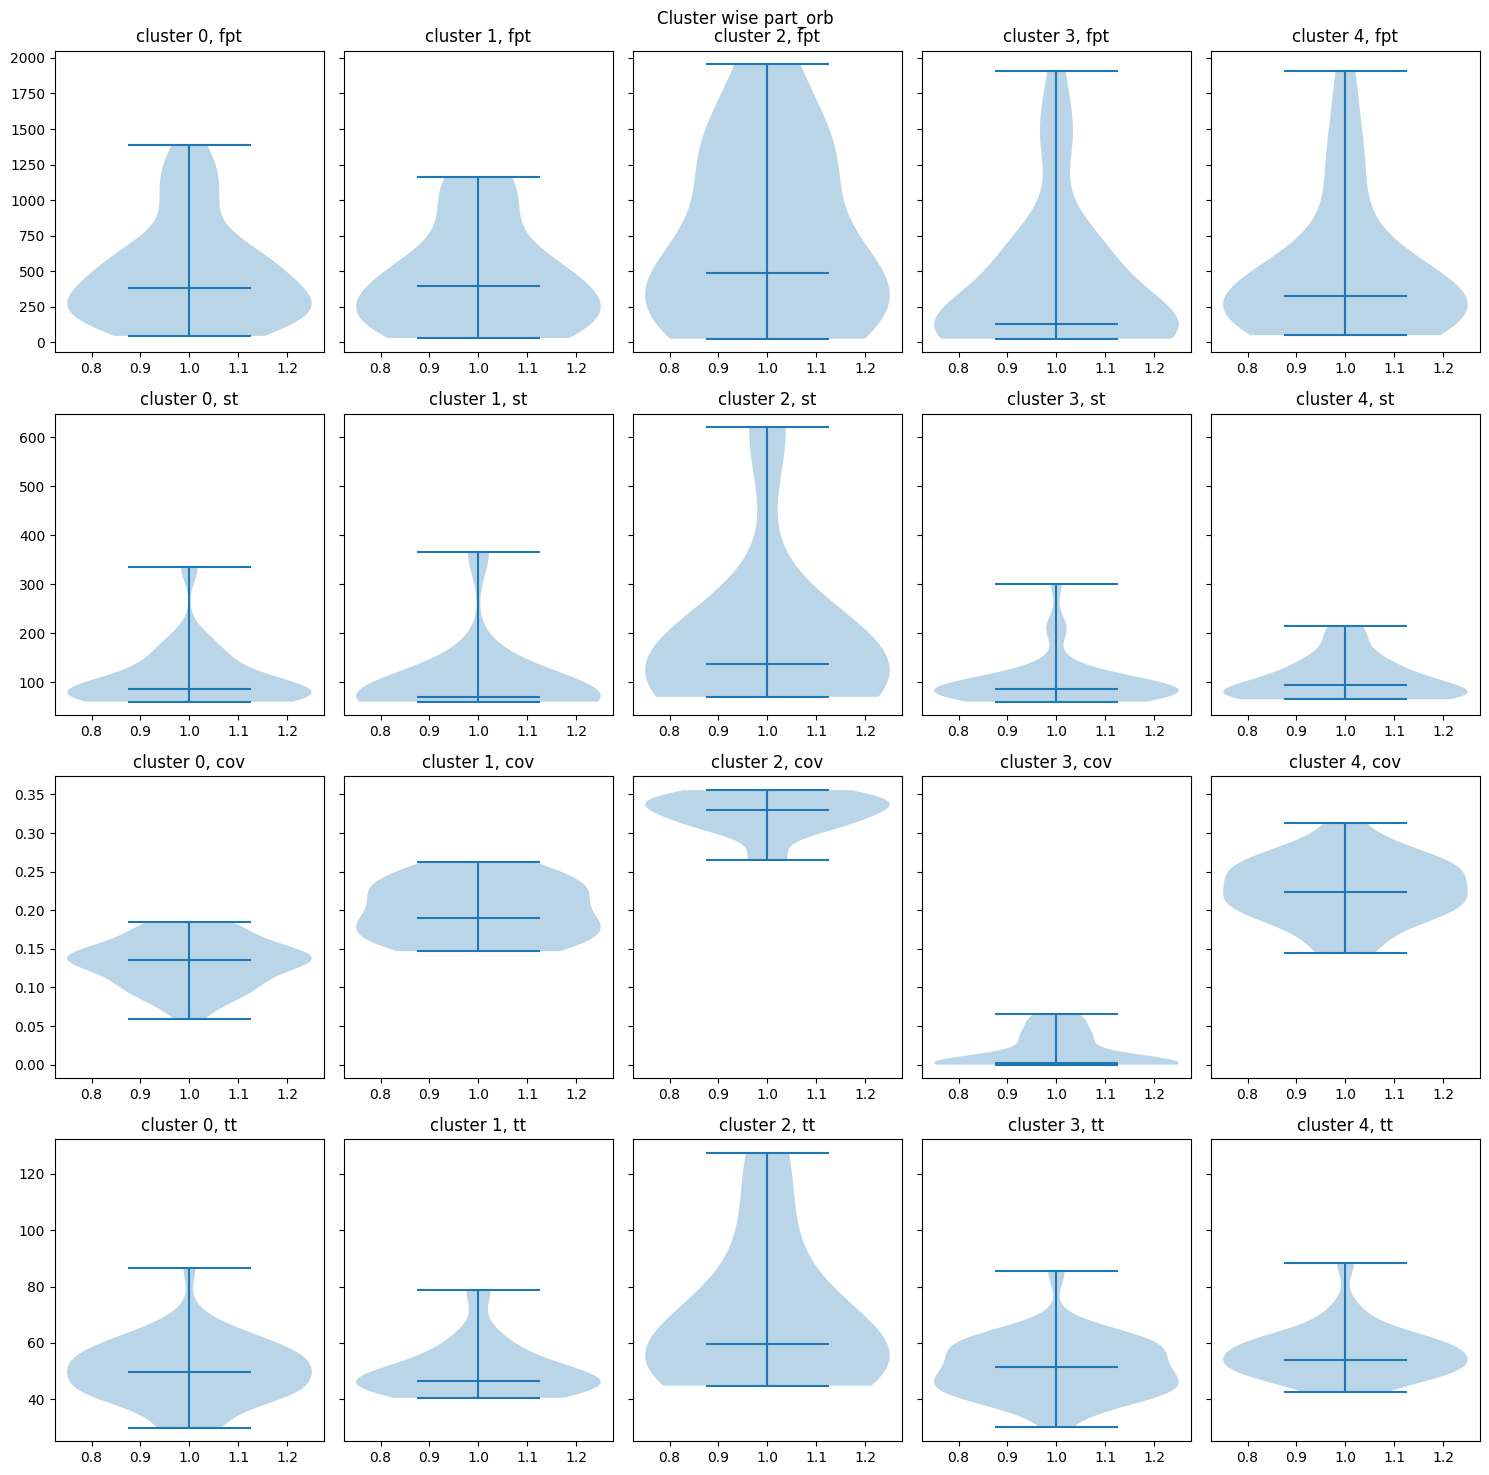

full_orb
full_peri


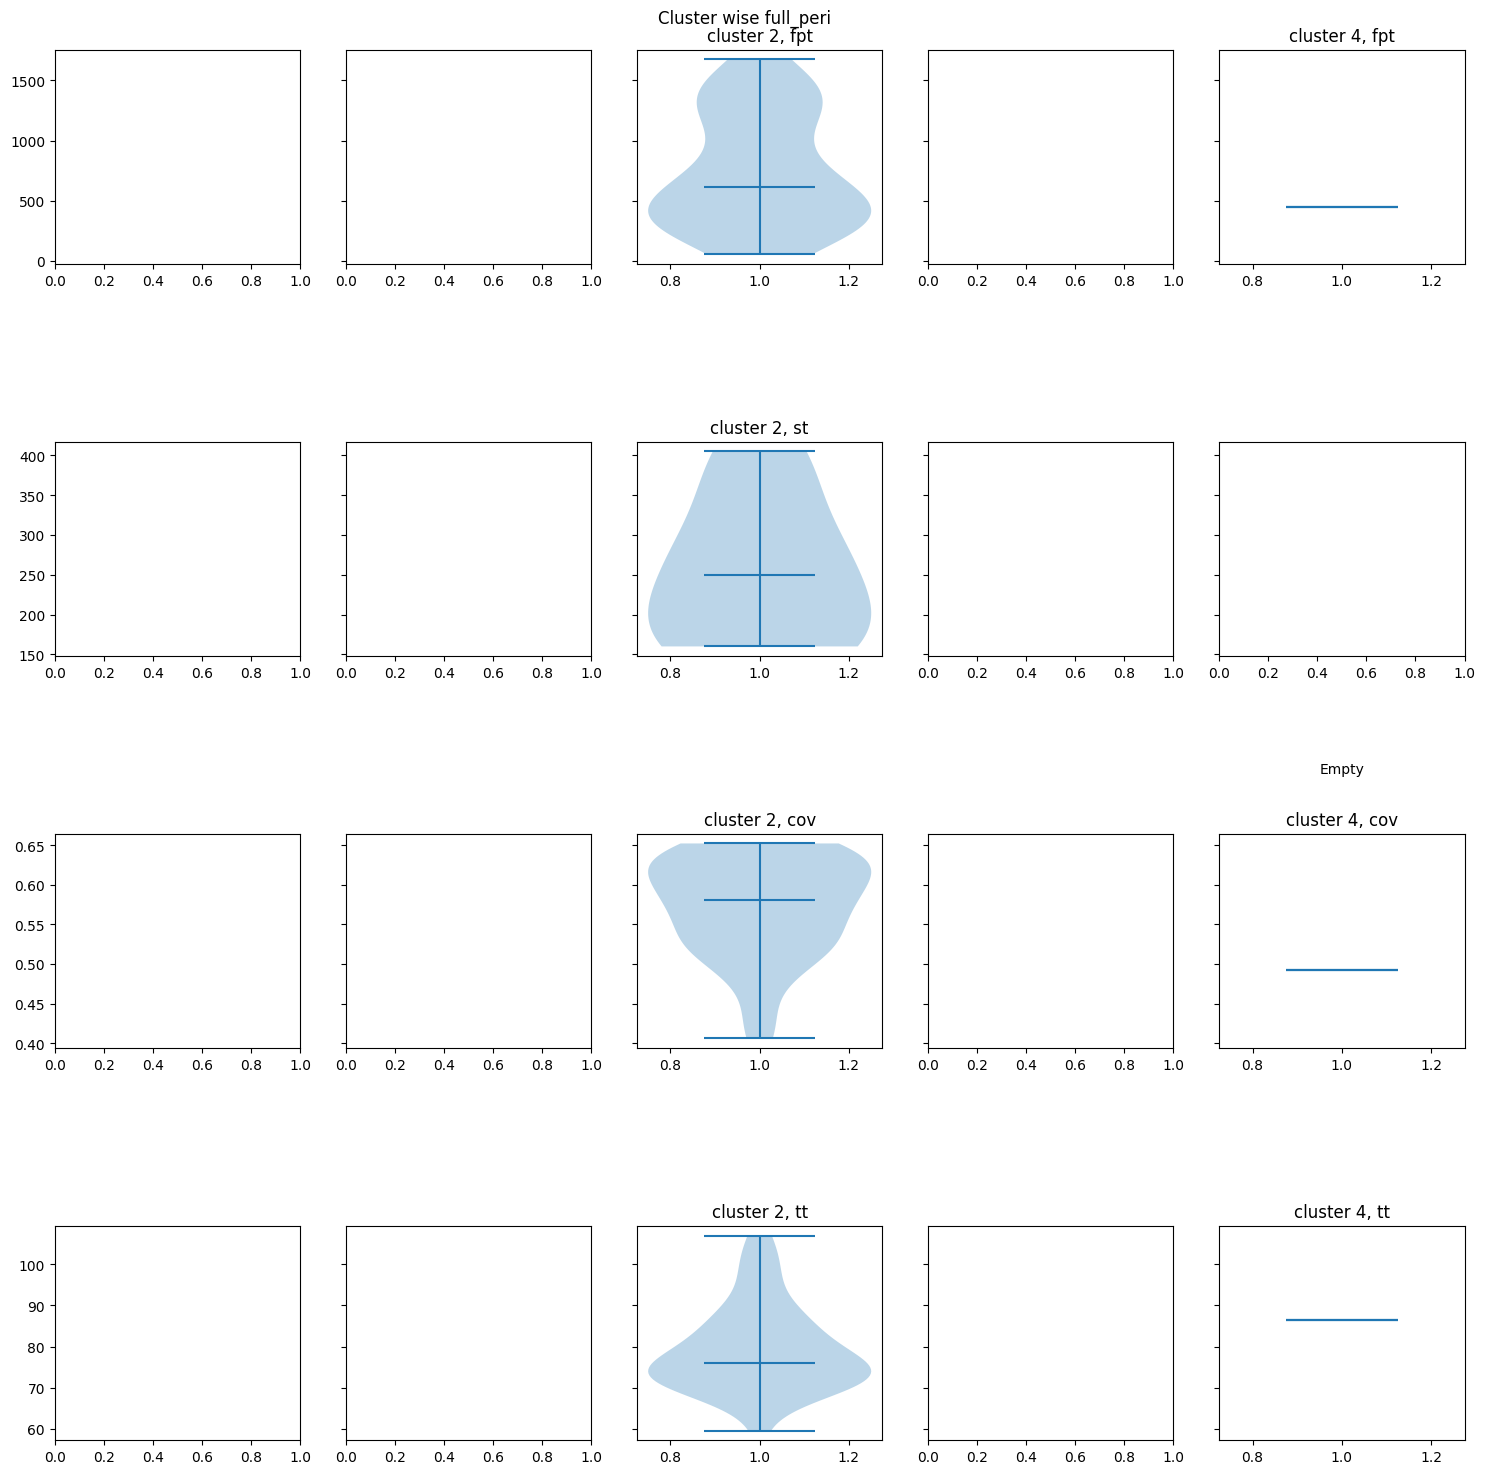

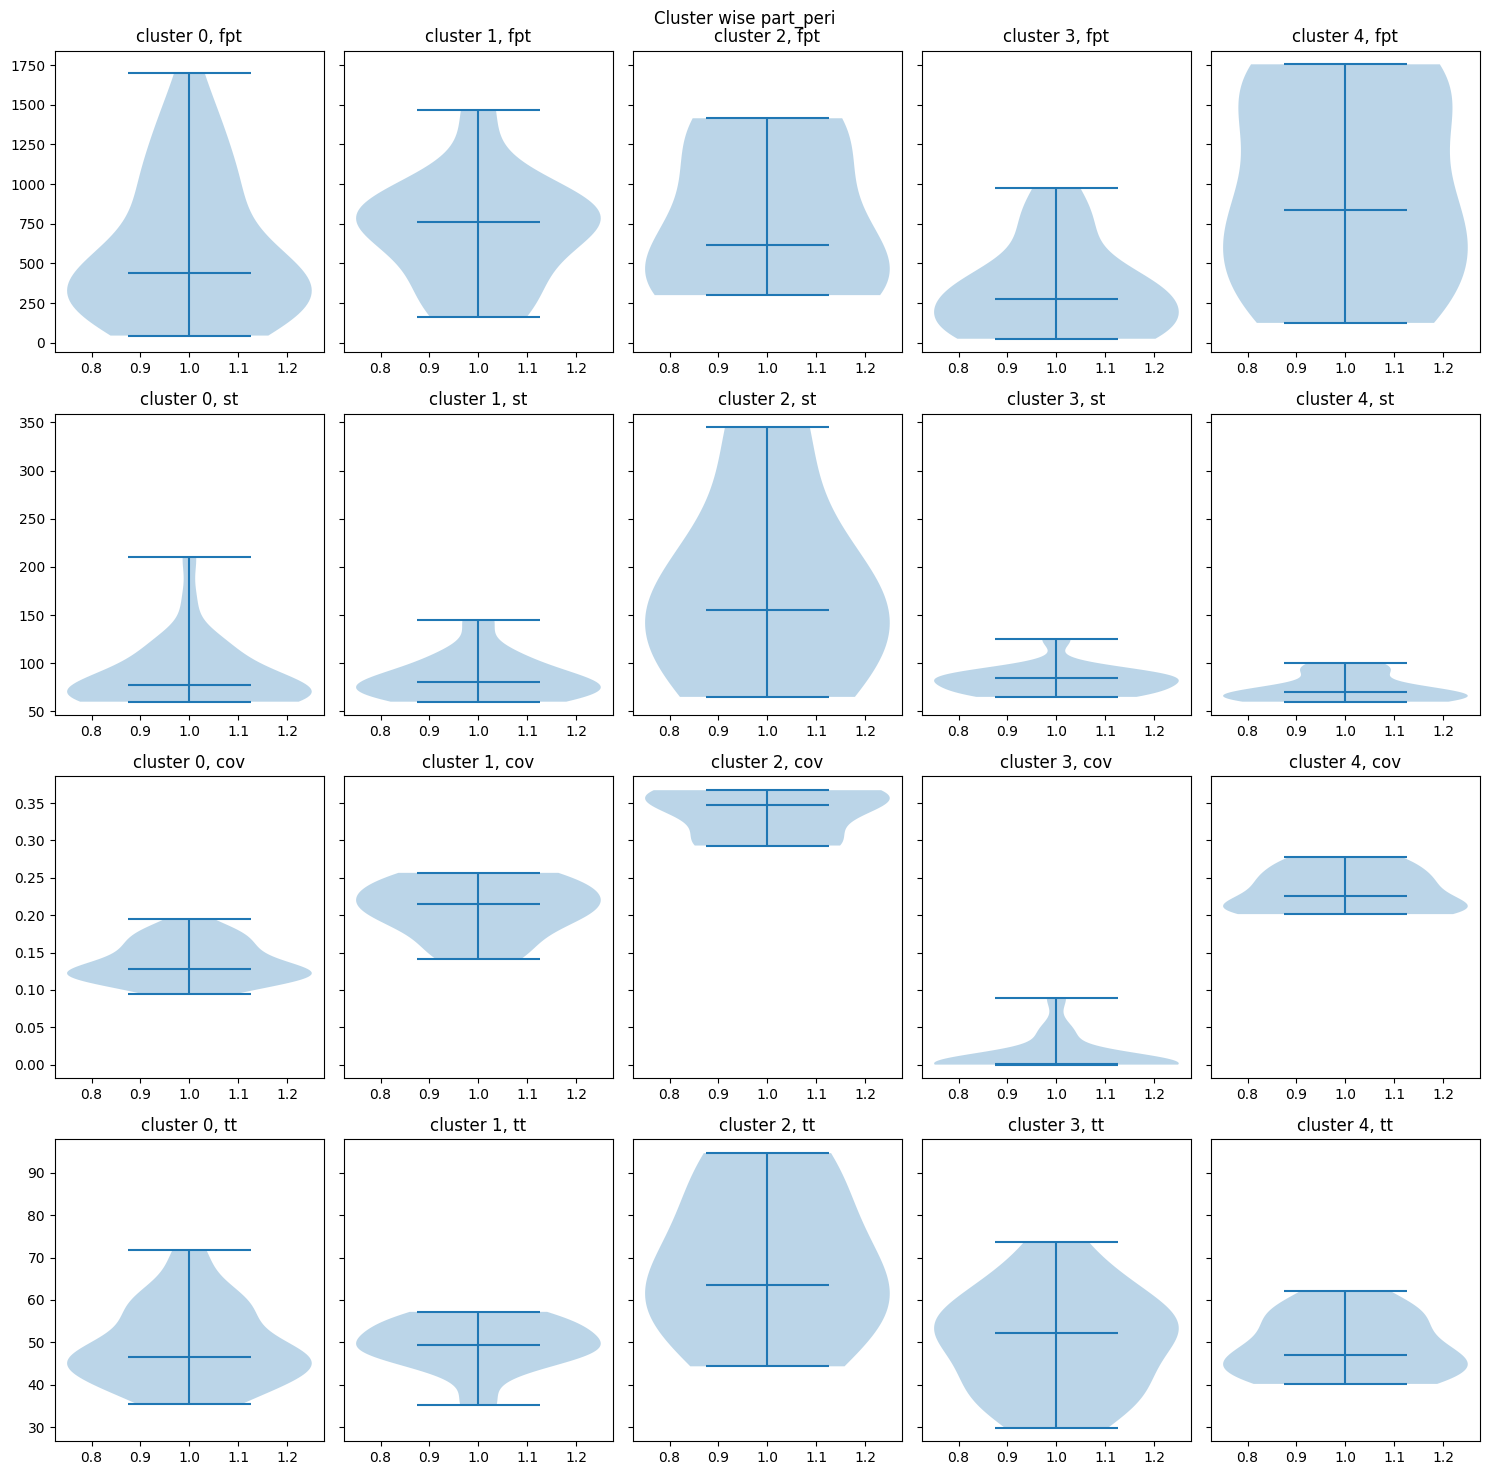

full_peri
full_pir


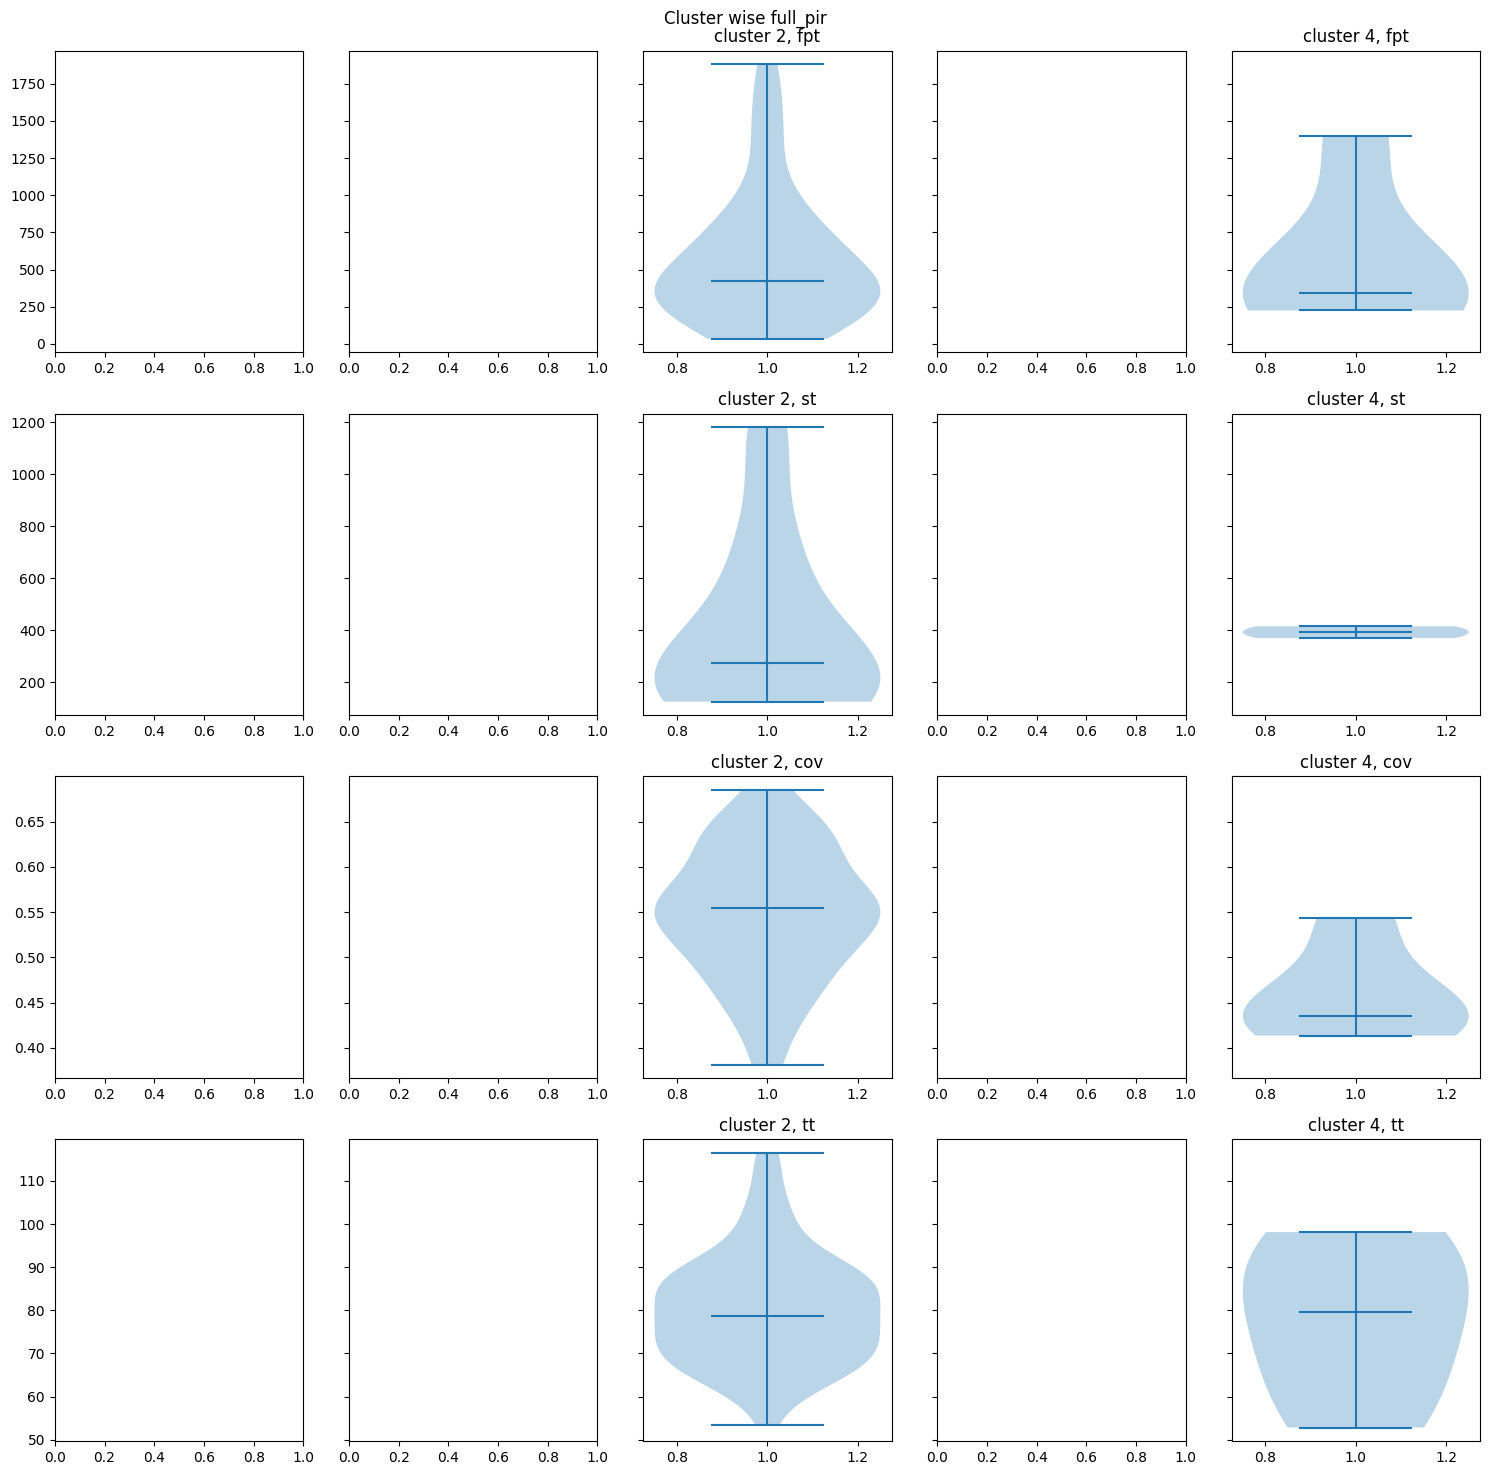

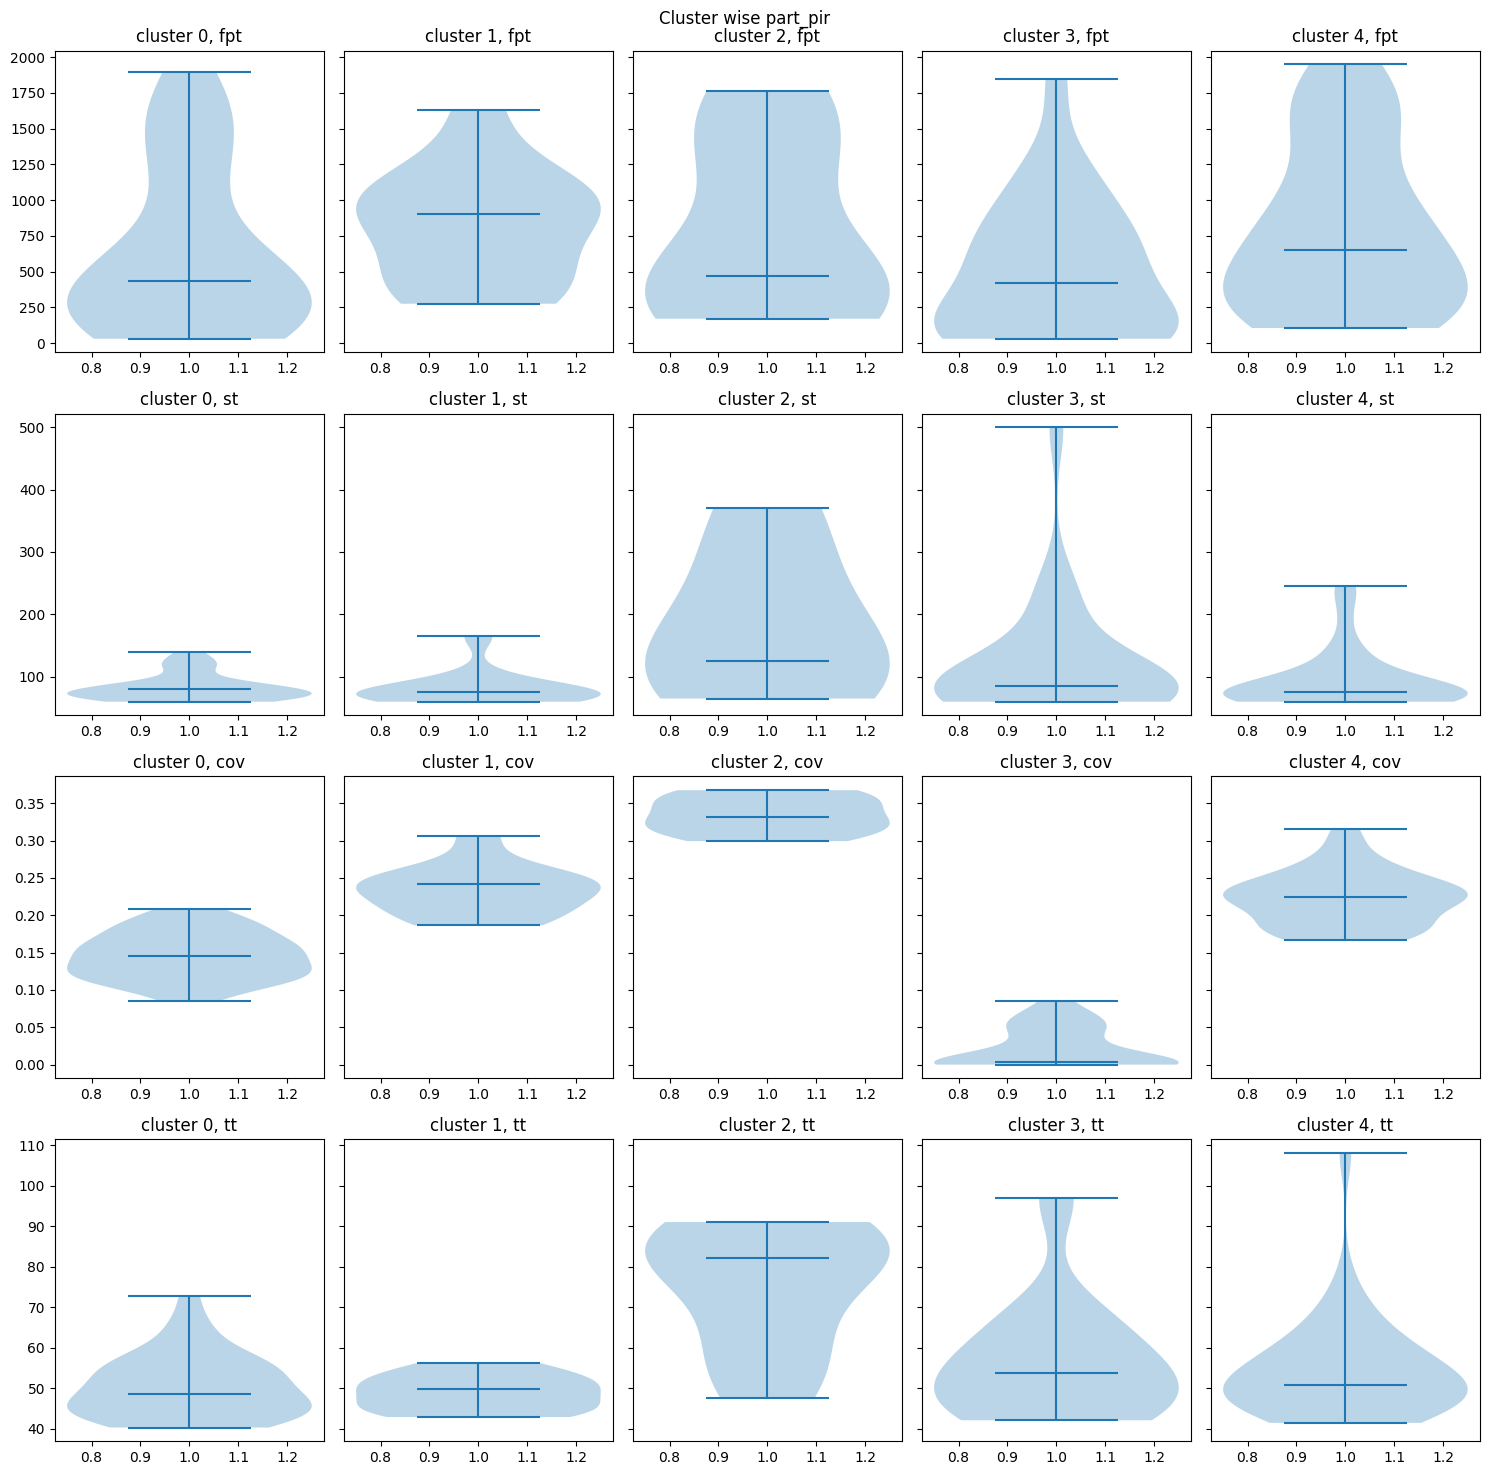

full_pir
full_re


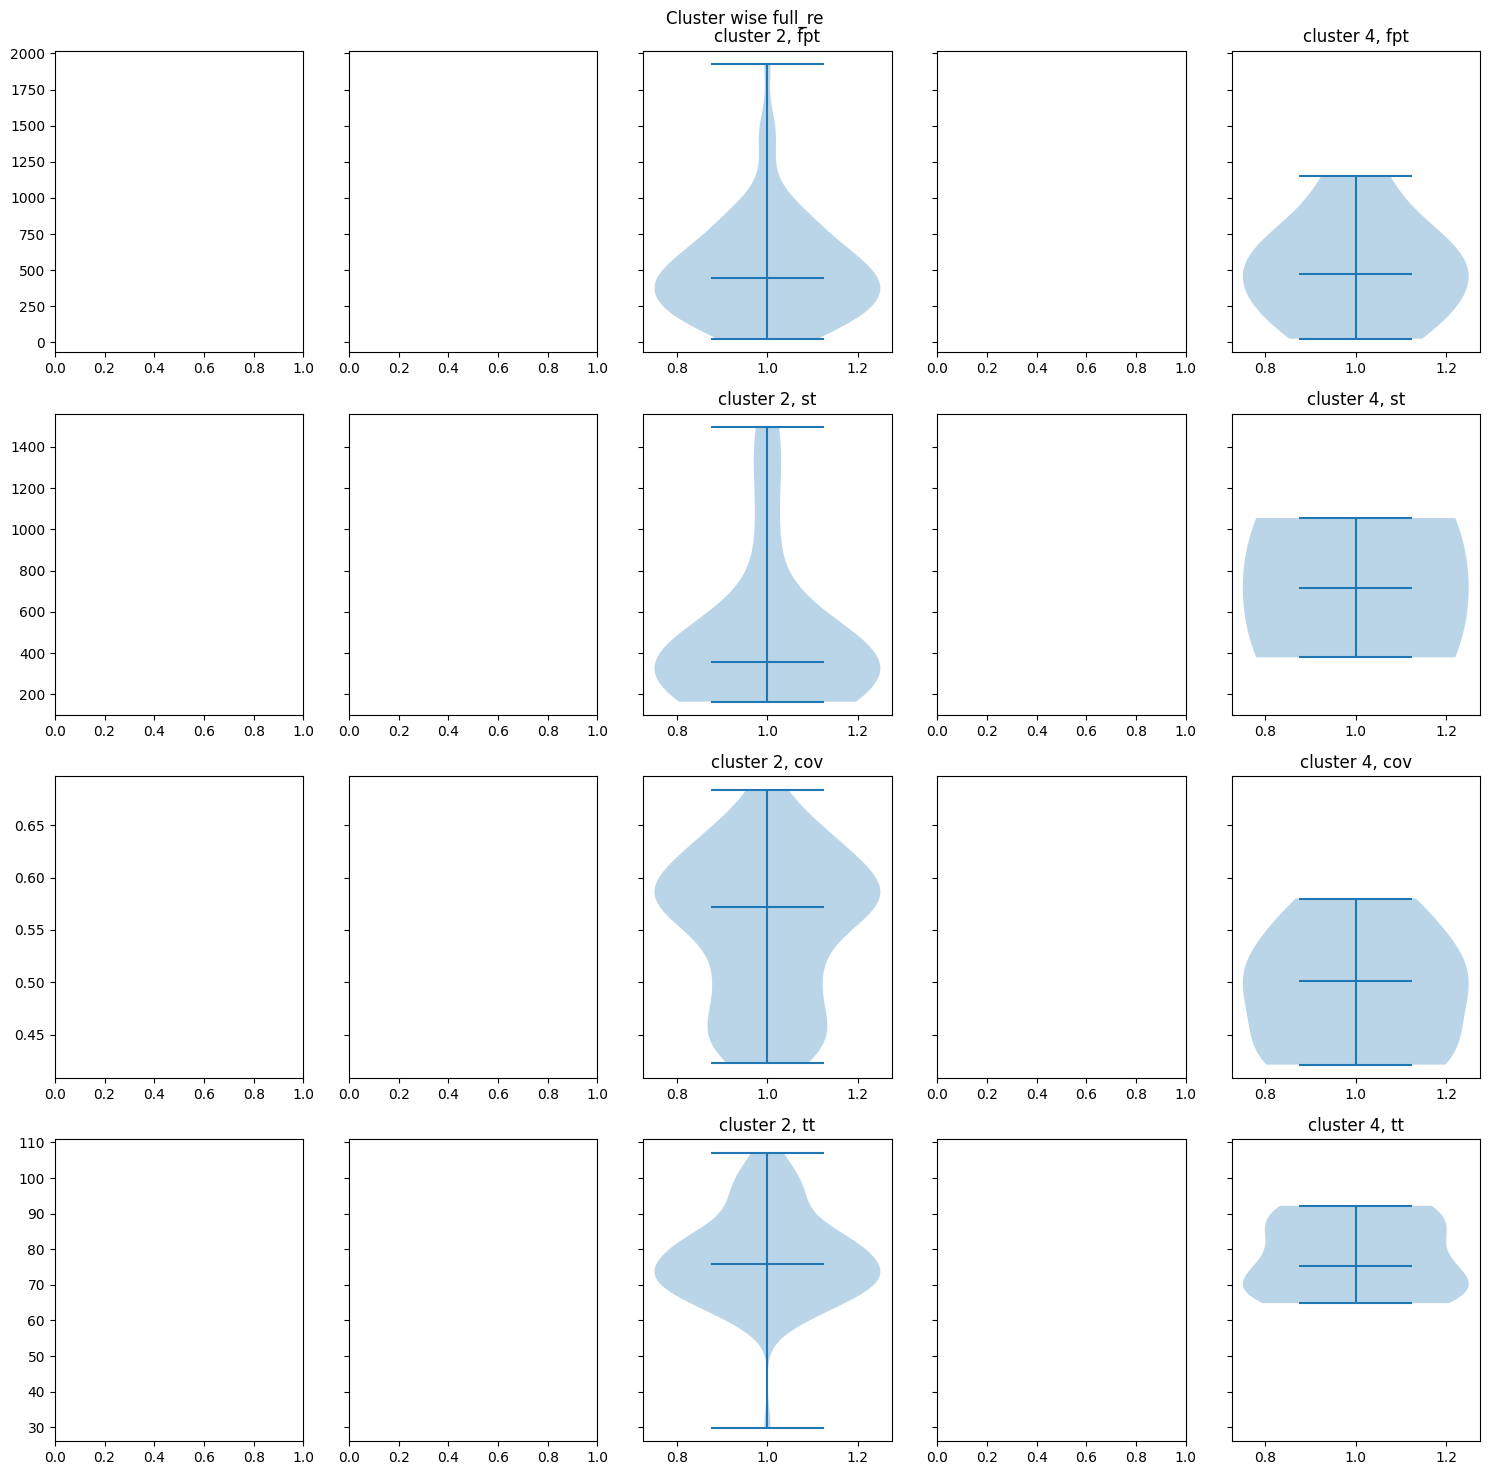

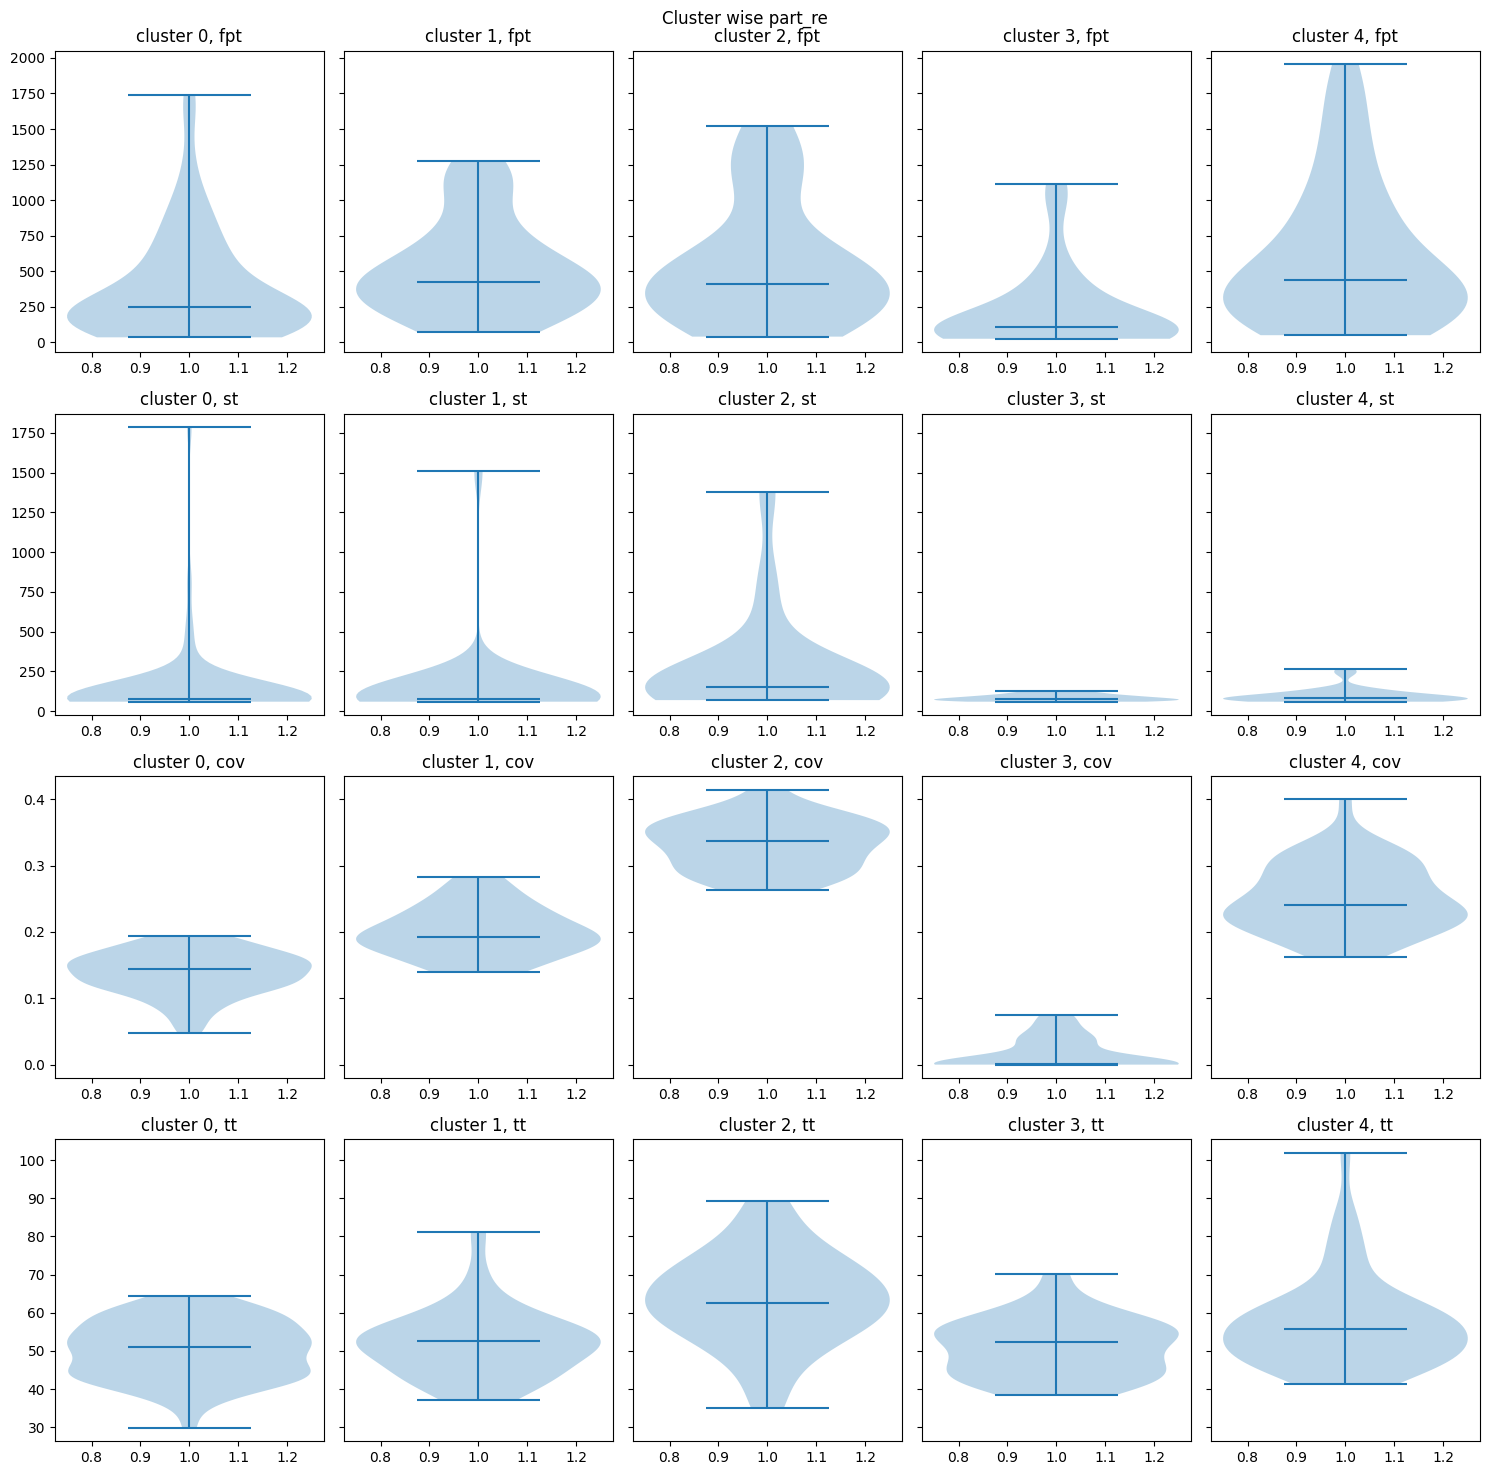

full_re


In [ ]:
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    plot_params(pkl_full,f"full_{f_full.split('_')[-1]}")

    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)

    plot_params(pkl_part,f"part_{f_part.split('_')[-1]}")

    print(f"full_{f_full.split('_')[-1]}")

#### Fit st and fpt clusterwise

In [ ]:
def fit_piecewiseLinear(data):
    intervals=data.copy()
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)
    # Fit piecewise linear with 3 segments
    x=intervals
    y=log_ccdf
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    # Predict
    y_hat = my_pwlf.predict(x)

    return [x,y,y_hat,breaks[1]]

    
    # ax.scatter(x, y)
    # ax.plot(x, y_hat, 'r')
    # ax.set_ylabel("log P(T > t)")
    # ax.set_title(f"Log-CCDF {label} {round(breaks[1])} (2 fits)")
    # ax.legend()
    

In [ ]:

def is_empty(arr):
    if arr is None:
        return True
    if isinstance(arr, (list, tuple)):
        return len(arr) == 0
    if isinstance(arr, np.ndarray):
        return arr.size == 0
    if isinstance(arr, (pd.Series, pd.DataFrame)):
        return arr.empty
    return False


In [ ]:
def plot_fit(data, label):
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    key_list = ['fpt', 'st', 'cov', 'tt']
    colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}
    
    for j in range(2):  # two subplots
        for i in data.keys():  # loop over your 5 dictionaries
            plt_data = data[i][key_list[j]]
            # limit fpt from 20 to 600 i.e j = 0
            if j==0:
                plt_data=[x for x in plt_data if 0<x<600]
            else:
                # limit ST from 0 to 250 for partial data
                # plt_data=[x for x in plt_data if 0<x<250]
                # comment out for full
                plt_data=[x for x in plt_data if 0<x<600]
                
            
            # check emptiness
            if plt_data is None or len(plt_data) == 0:
                ax = axes[j]
                ax.text(0.5, 0.5, "Empty", ha='center')
                continue
            
            ax = axes[j]
            try:
                # attempt fit
                l = fit_piecewiseLinear(plt_data)
                x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
                
                # pick color based on i
                color = colors.get(i, "black")
                
                # scatter and line with chosen color
                ax.scatter(x, y, color=color, alpha=0.5, label=f"clust {i}")
                ax.plot(x, y_hat, color=color, alpha=0.5)
                
                ax.set_ylabel("log P(T > t)")
                ax.set_title(f"Log-CCDF {label} {key_list[j]}")
                ax.legend()
            
            except Exception as e:
                # if fit fails, skip gracefully
                ax.text(0.5, 0.5, f"Fit failed: cluster {i}", ha='center', fontsize=8)
    
    plt.tight_layout()
    

                
    # plt.savefig(f'../../data/results/comm_umap_results/comm_wise_params/cw_{key_list[j]}{label}.pdf', format='pdf')

  


In [ ]:
pkl_full[2].keys()

dict_keys(['fpt', 'st', 'cov', 'tt'])

full_bla
full_enti


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_fn
full_lha
full_lsc
full_mob
full_mop
full_mos
full_mrn
full_orb
full_peri
full_pir
full_re


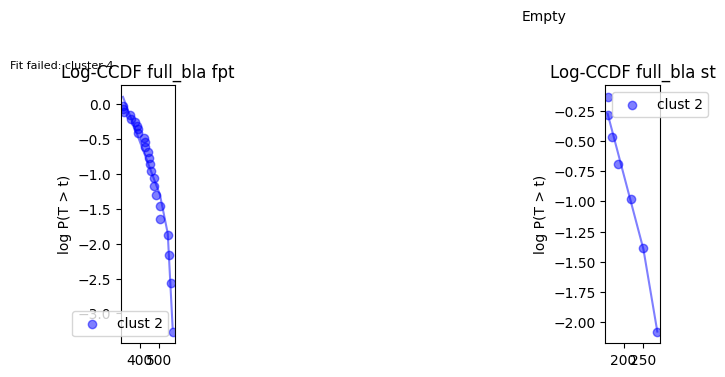

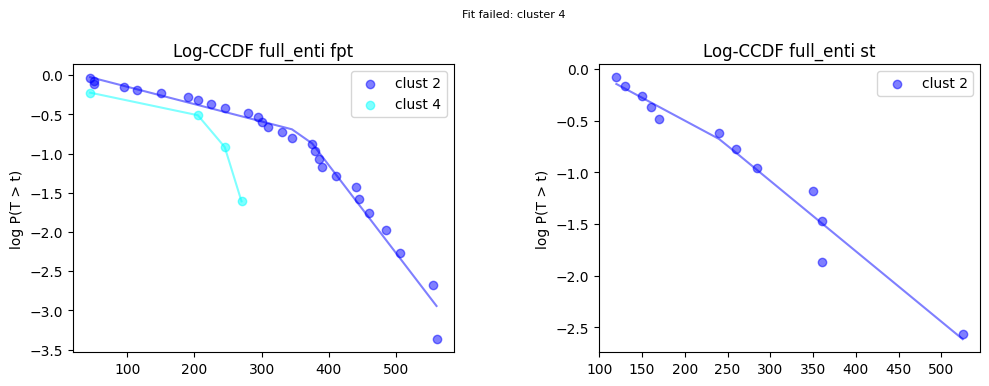

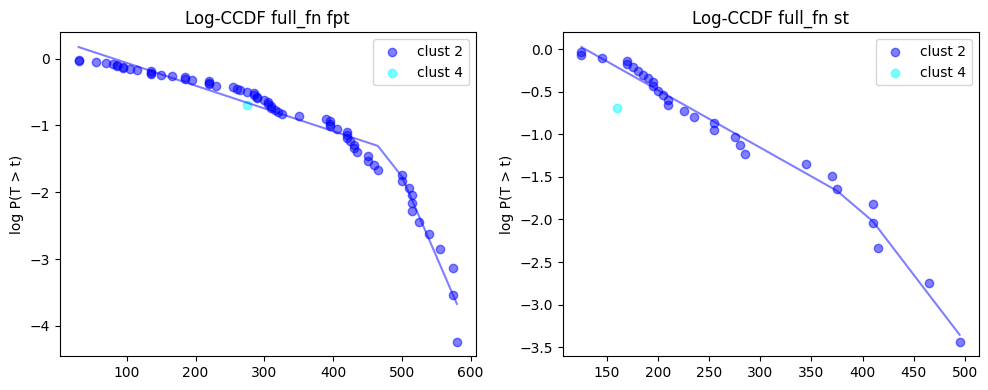

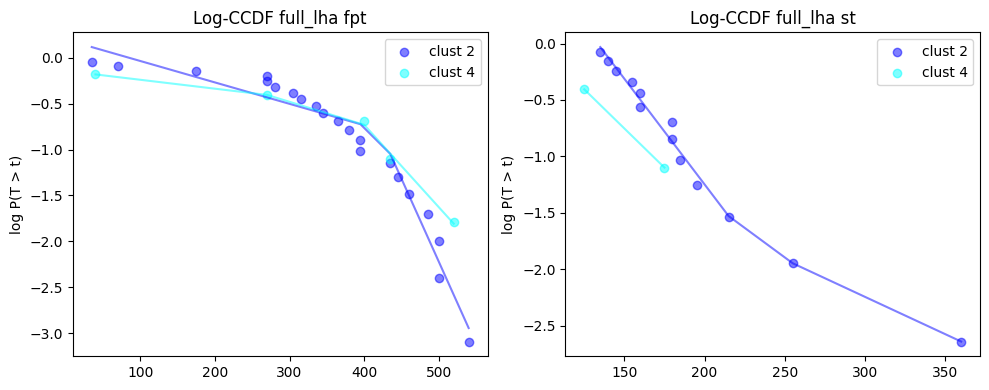

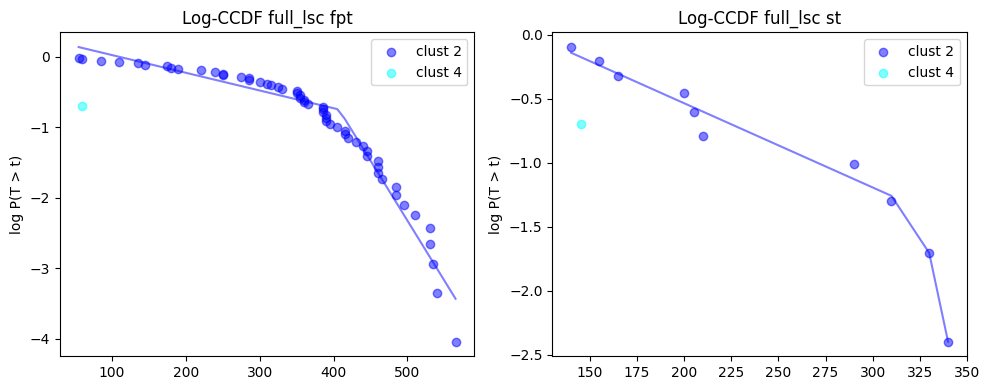

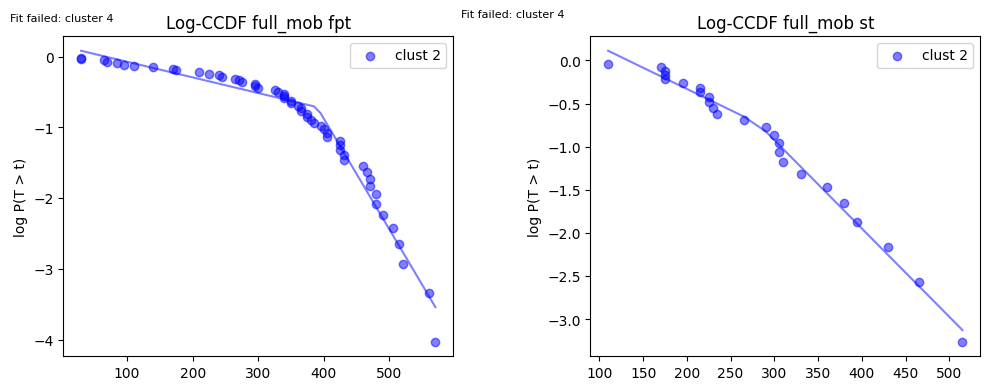

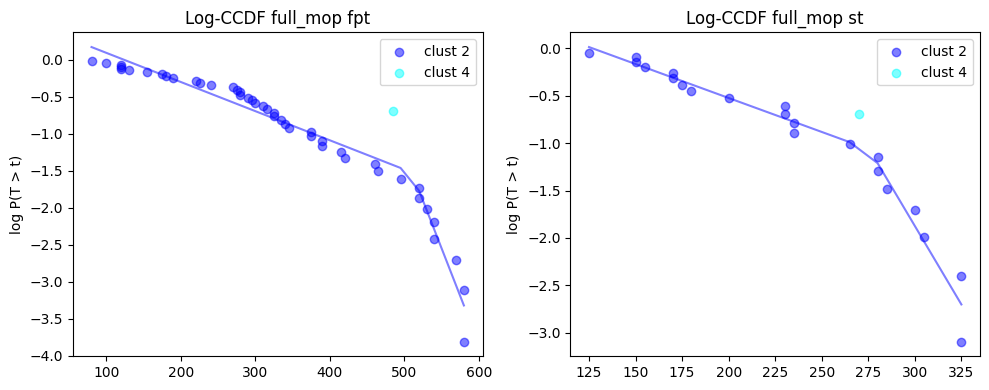

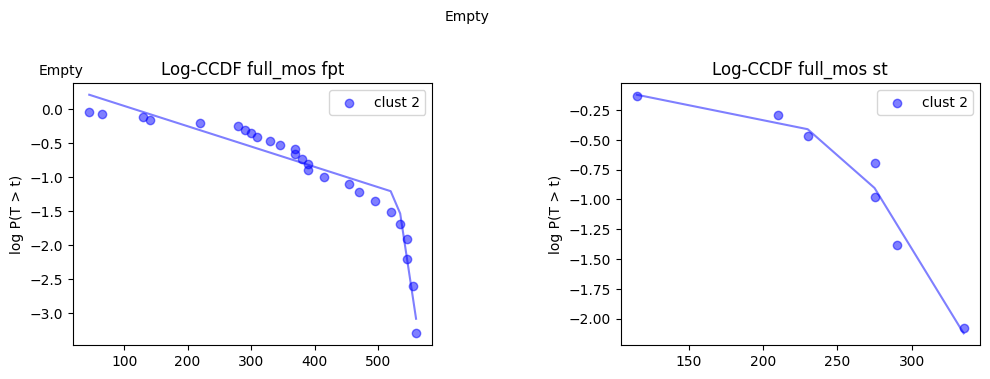

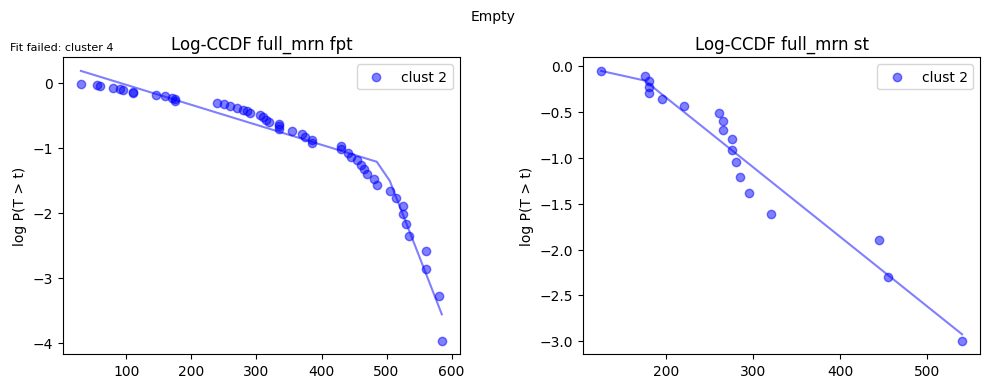

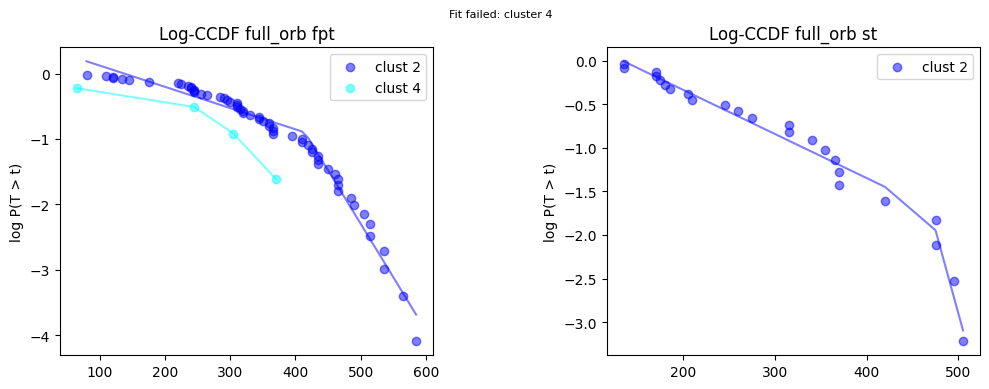

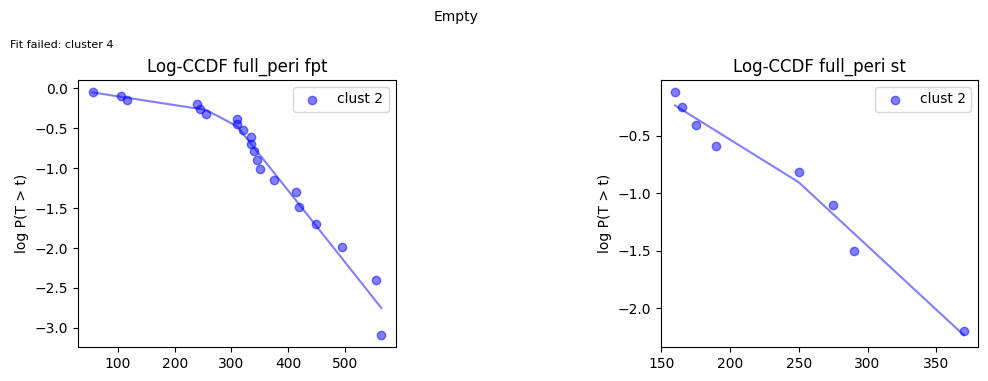

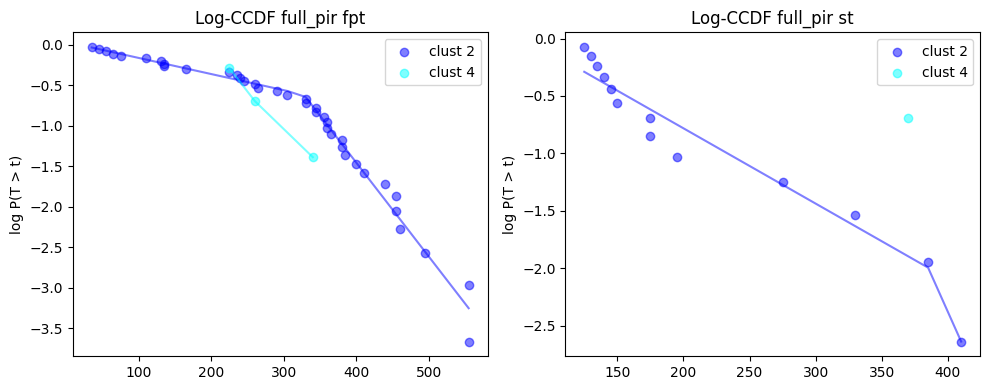

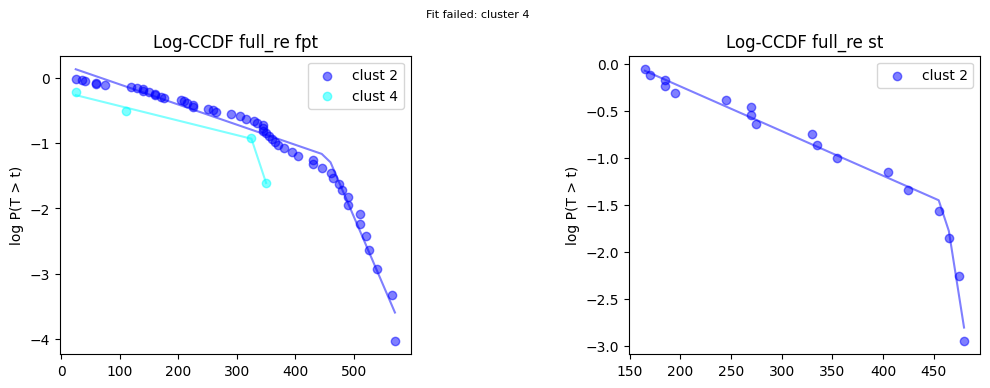

In [ ]:
for f_full, f_part in zip(file_full,file_part):
    # print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    plot_fit(pkl_full,f"full_{f_full.split('_')[-1]}")

    # with open(f_part, "rb") as f:
    #     pkl_part = pickle.load(f)

    # plot_fit(pkl_part,f"part_{f_part.split('_')[-1]}")

    print(f"full_{f_full.split('_')[-1]}")

#### Calculate the mean median of params clusterwise

In [ ]:
# read data
data_folder = Path('../../data/results/comm_umap_results/comm_wise_params')
file_full = glob.glob(str(data_folder/'full_*'))
file_part = glob.glob(str(data_folder/'part_*'))

In [ ]:
d_fn=reader.data_read_pkl('results\\comm_umap_results\\comm_wise_params\\part_enti')
d_fn.keys()

dict_keys([0, 4, 3, 1, 2])

In [ ]:
# function to calculate medians for a given cluster
def cal_med(clus_data):
    med=[]
    for p in clus_data.keys():
        md=np.median(clus_data[p])
        med.append(md)
        
    return med

In [ ]:
# take each cluster
def compute_clu_params(data):
    """
    Compute the median of clusterwise params

    Args:
        data (dictionary): Contains clusterwise params
    Return:
        dictionary: median for each cluster and cluster itself
    """
    fpt,st,cov,tt=[],[],[],[]
    cluster=[]
    for c in data.keys():
        cluster.append(c)
        med=cal_med(data[c])

        fpt.append(med[0])
        st.append(med[1])
        cov.append(med[2])
        tt.append(med[3])

    return {'cluster':cluster,'fpt':fpt,'st':st,'cov':cov,'tt':tt}

    


In [ ]:
compute_clu_params(d_fn)

{'cluster': [0, 4, 3, 1, 2],
 'fpt': [562.5, 397.5, 112.5, 630.0, 365.0],
 'st': [80.0, 80.0, 85.0, 75.0, 115.0],
 'cov': [0.1437029706221089,
  0.21608372544262877,
  0.0020277364863813823,
  0.21667366507473962,
  0.3220702731835921],
 'tt': [49.35,
  52.925000000000004,
  53.25,
  52.275000000000006,
  58.050000000000004]}

In [ ]:
l=compute_clu_params(d_fn)
df=pd.DataFrame(l)
df

,cluster,fpt,st,cov,tt
0,0,562.5,80.0,0.143703,49.350
1,4,397.5,80.0,0.216084,52.925
2,3,112.5,85.0,0.002028,53.250
3,1,630.0,75.0,0.216674,52.275
4,2,365.0,115.0,0.322070,58.050


In [ ]:
# Sort by cluster column
df_sorted = df.sort_values(by="cluster")

print(df_sorted)


   cluster    fpt     st       cov      tt
0        0  562.5   80.0  0.143703  49.350
3        1  630.0   75.0  0.216674  52.275
4        2  365.0  115.0  0.322070  58.050
2        3  112.5   85.0  0.002028  53.250
1        4  397.5   80.0  0.216084  52.925


In [ ]:
df=pd.DataFrame(l)
for c in l['cluster']:
    print(c)
    
    
clus2=df.loc[0].to_frame().T
clus2

# clus4=df.loc[1].to_frame().T
# df_dum = pd.DataFrame()
# df_=pd.concat([df_dum,clus2])
# df_dum


,cluster,fpt,st,cov,tt
0,0.0,562.5,80.0,0.143703,49.35


In [ ]:
file_full[1]

'..\\..\\data\\results\\comm_umap_results\\comm_wise_params\\full_enti'

Reading data of all networks

Plot cluster 2 and 4 full transition parameters 
- Taken mean of medians across all networks

In [ ]:
df_c2 = pd.DataFrame()
df_c4= pd.DataFrame()

# first doing for full transition files
for f in file_full:
    with open(f, "rb") as full:
        pkl = pickle.load(full)
    # compute clusterwise median params
    l = compute_clu_params(pkl)
    # store them separately in cluster
    df = pd.DataFrame(l)
    df_l = df.sort_values(by="cluster")
    clus2 = df_l.iloc[0].to_frame().T
    df_c2 = pd.concat([df_c2,clus2],ignore_index=True)

    clus4 = df_l.iloc[1].to_frame().T
    df_c4 = pd.concat([df_c4,clus4],ignore_index=True)



    

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: 

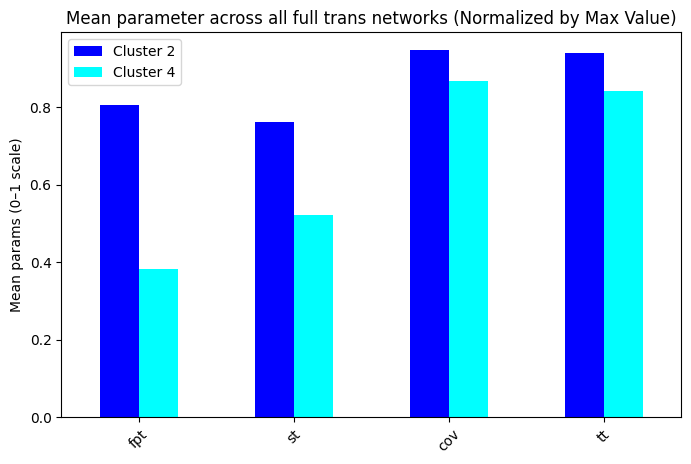

In [ ]:
import matplotlib.pyplot as plt

all_df = [df_c2, df_c4]
colors = ['blue', 'cyan']
labels = ['Cluster 2', 'Cluster 4']

# Collect means for each cluster
means_list = []
for df in all_df:
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()
    means_list.append(df_norm.mean())

# Combine into one DataFrame for plotting
means_df = pd.DataFrame(means_list, index=labels).T

# Plot grouped bar chart
means_df.plot(kind='bar', figsize=(8,5), color=colors)

plt.title("Mean parameter across all full trans networks (Normalized by Max Value)")
plt.ylabel("Mean params (0–1 scale)")
plt.xticks(rotation=45)
# plt.legend(title="Clusters")
plt.show()


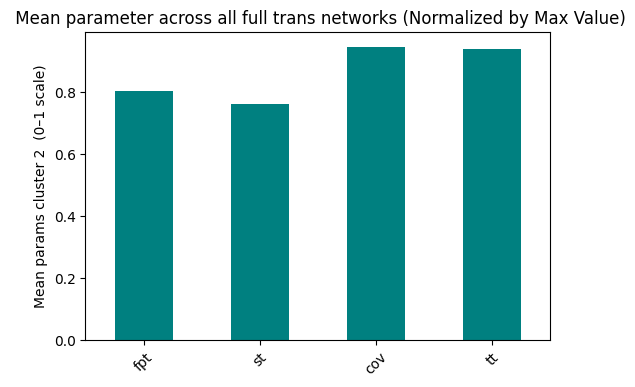

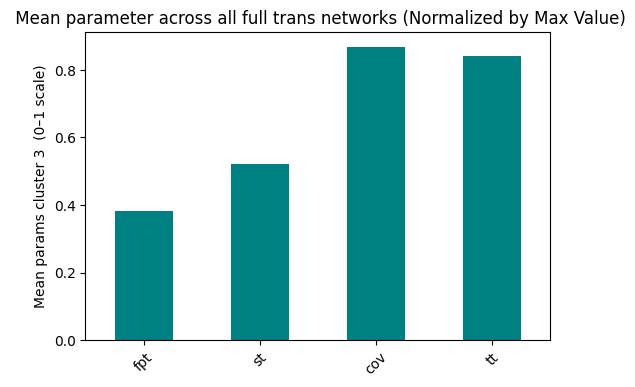

In [ ]:
all_df = [df_c2,df_c4]
for n,df in enumerate(all_df):
    # Drop cluster column if you don't want it included
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

    # Compute mean of normalized columns
    means = df_norm.mean()

    # Plot bar chart
    plt.figure(figsize=(6,4))
    means.plot(kind='bar', color='teal')

    plt.title(" Mean parameter across all full trans networks (Normalized by Max Value)")
    plt.ylabel(f"Mean params cluster {n+2}  (0–1 scale)")
    plt.xticks(rotation=45)
    plt.show()



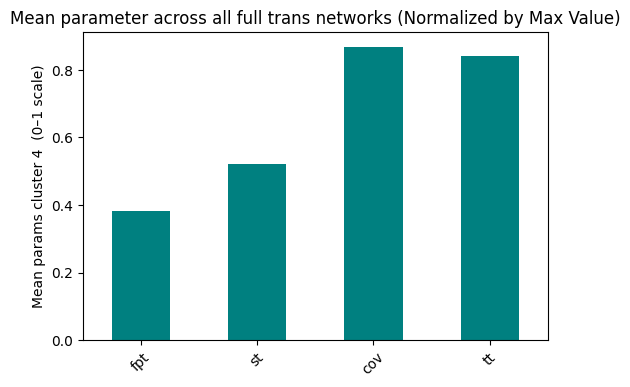

In [ ]:
df=df_c4.copy()
# Drop cluster column if you don't want it included
df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

# Compute mean of normalized columns
means = df_norm.mean()

# Plot bar chart
plt.figure(figsize=(6,4))
means.plot(kind='bar', color='teal')

plt.title("Mean parameter across all full trans networks (Normalized by Max Value)")
plt.ylabel("Mean params cluster 4  (0–1 scale)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_c0 = pd.DataFrame()
df_c1 = pd.DataFrame()
df_c2 = pd.DataFrame()
df_c3= pd.DataFrame()
df_c4 = pd.DataFrame()

# first doing for full transition files
for f in file_part:
    with open(f, "rb") as part:
        pkl = pickle.load(part)
    # compute clusterwise median params
    l = compute_clu_params(pkl)
    # store them separately in cluster
    df = pd.DataFrame(l)
    df_l = df.sort_values(by="cluster")

    clus0 = df_l.iloc[0].to_frame().T
    df_c0= pd.concat([df_c0,clus0],ignore_index=True)

    clus1 = df_l.iloc[1].to_frame().T
    df_c1 = pd.concat([df_c1,clus1],ignore_index=True)

    clus2 = df_l.iloc[2].to_frame().T
    df_c2 = pd.concat([df_c2,clus2],ignore_index=True)

    clus3 = df_l.iloc[3].to_frame().T
    df_c3 = pd.concat([df_c3,clus3],ignore_index=True)

    clus4 = df_l.iloc[4].to_frame().T
    df_c4 = pd.concat([df_c4,clus4],ignore_index=True)


In [ ]:
df_c0

,cluster,fpt,st,cov,tt
0,0.0,410.0,75.0,0.139014,48.55
1,0.0,562.5,80.0,0.143703,49.35
2,0.0,415.0,85.0,0.133485,50.65
3,0.0,430.0,75.0,0.142664,49.40
4,0.0,300.0,80.0,0.143324,50.55
5,0.0,485.0,77.5,0.137608,51.35
6,0.0,307.5,87.5,0.128970,52.70
7,0.0,270.0,80.0,0.133412,49.50
8,0.0,425.0,85.0,0.138557,53.20
9,0.0,380.0,85.0,0.135239,49.65


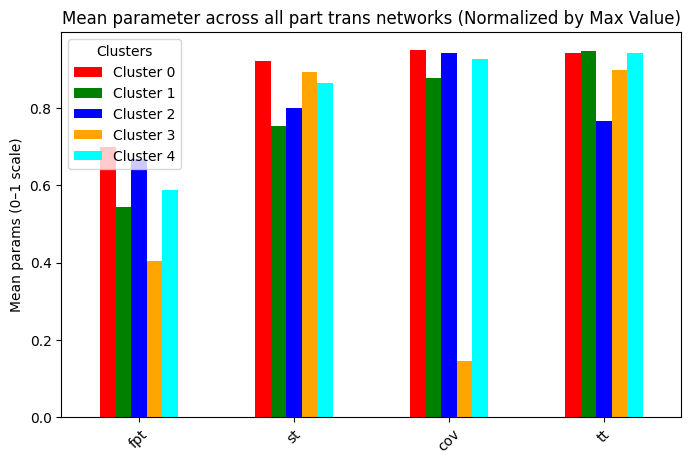

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}
all_df = [df_c0, df_c1, df_c2, df_c3, df_c4]

# Collect means for each cluster
means_list = []
labels = []
for n, df in enumerate(all_df):
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()
    means_list.append(df_norm.mean())
    labels.append(f"Cluster {n}")

# Combine into one DataFrame
means_df = pd.DataFrame(means_list, index=labels).T

# Plot grouped bar chart with custom colors
cluster_colors = [colors[i] for i in range(len(all_df))]
means_df.plot(kind='bar', figsize=(8,5), color=cluster_colors)

plt.title("Mean parameter across all part trans networks (Normalized by Max Value)")
plt.ylabel("Mean params (0–1 scale)")
plt.xticks(rotation=45)
plt.legend(title="Clusters")
plt.show()


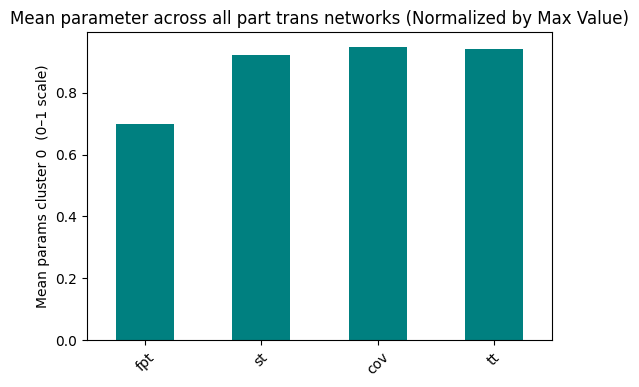

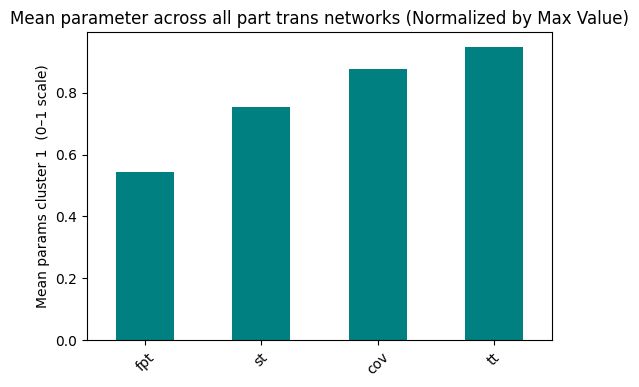

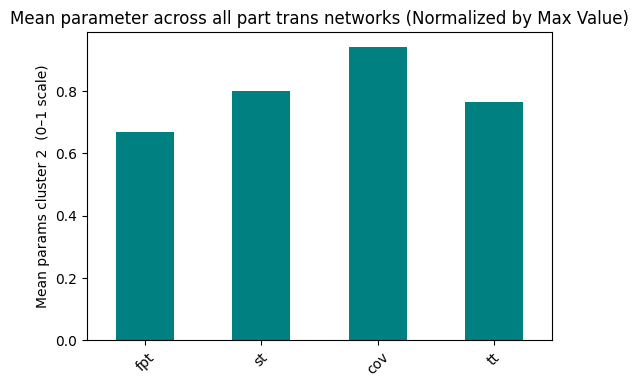

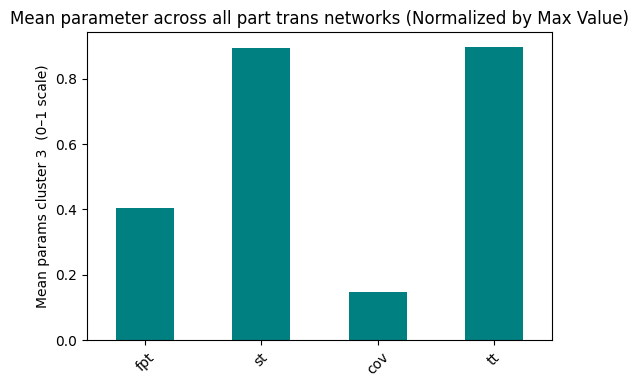

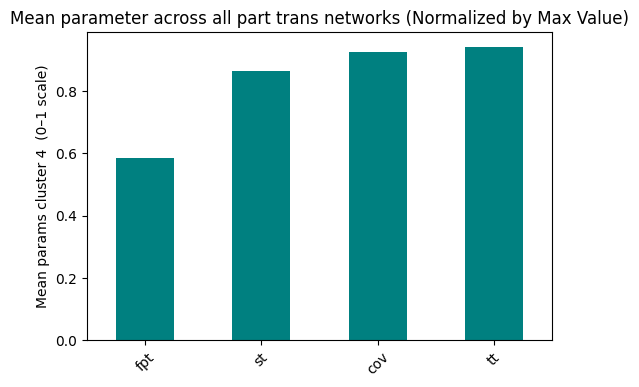

In [ ]:
all_df = [df_c0,df_c1,df_c2,df_c3,df_c4]
# Plot bar chart
plt.figure(figsize=(6,4))
for n,df in enumerate(all_df):
# Drop cluster column if you don't want it included
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

    # Compute mean of normalized columns
    means = df_norm.mean()

    
    means.plot(kind='bar', color='teal')

    plt.title("Mean parameter across all part trans networks (Normalized by Max Value)")
    plt.ylabel(f"Mean params cluster {n}  (0–1 scale)")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
df=df_c0.copy()
# Drop cluster column if you don't want it included
df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

# Compute mean of normalized columns
means = df_norm.mean()

# Plot bar chart
plt.figure(figsize=(6,4))
means.plot(kind='bar', color='teal')

plt.title("Mean parameter across all part trans networks (Normalized by Max Value)")
plt.ylabel("Mean params cluster 0  (0–1 scale)")
plt.xticks(rotation=45)
plt.show()